In [1]:
# Imports
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import random, copy, warnings, os, json

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             precision_score, recall_score, f1_score, accuracy_score)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold

from torch_geometric.data import HeteroData
from torch_geometric.nn import (GATv2Conv, GCNConv, Linear, HGTConv,
                                 RGCNConv, HypergraphConv, ChebConv)

from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer
from sdv.sampling import Condition
from imblearn.over_sampling import SMOTENC, RandomOverSampler
from torch.optim.lr_scheduler import CosineAnnealingLR
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")


def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    # Required for deterministic CUBLAS (scatter_add_, etc.) on CUDA
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    # Force all PyTorch ops to use deterministic algorithms.
    # scatter_add_ (used in GNN message passing) is non-deterministic by default.
    try:
        torch.use_deterministic_algorithms(True)
    except AttributeError:
        pass  # PyTorch < 1.8

set_seed(42)

N_TRIALS   = 30
N_FOLDS    = 5
MAX_EPOCHS = 200
PATIENCE   = 20


/home/nafim/anaconda3/envs/glioma/lib/python3.11/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: Could not load this library: /home/nafim/anaconda3/envs/glioma/lib/python3.11/site-packages/libpyg.so
  import torch_geometric.typing
/home/nafim/anaconda3/envs/glioma/lib/python3.11/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /home/nafim/anaconda3/envs/glioma/lib/python3.11/site-packages/torch_scatter/_version_cuda.so
  import torch_geometric.typing
/home/nafim/anaconda3/envs/glioma/lib/python3.11/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not load this library: /home/nafim/anaconda3/envs/glioma/lib/python3.11/site-packages/torch_cluster/_version_cuda.so
  import torch_geomet

Using device: cuda
GPU: NVIDIA GeForce RTX 3050


In [2]:
# 2. Load Data
# ============================================================================
tcga_df = pd.read_csv('../../dataset/TCGA_InfoWithGrade.csv')
cgga_df = pd.read_csv('../../dataset/weseq_processed_with_id_and_race_V2.csv')

if 'CGGA_ID' in cgga_df.columns:
    cgga_df = cgga_df.drop(columns='CGGA_ID')

tcga_before = len(tcga_df)
cgga_before = len(cgga_df)
tcga_df = tcga_df[tcga_df['Age_at_diagnosis'] >= 18].reset_index(drop=True)
cgga_df = cgga_df[cgga_df['Age_at_diagnosis'] >= 18].reset_index(drop=True)
print(f'TCGA: removed {tcga_before - len(tcga_df)} rows with Age < 18 '
      f'({tcga_before} → {len(tcga_df)})')
print(f'CGGA: removed {cgga_before - len(cgga_df)} rows with Age < 18 '
      f'({cgga_before} → {len(cgga_df)})')

categorical_columns = ['Grade', 'Gender', 'Race']
gene_columns = ['IDH1','TP53','ATRX','PTEN','EGFR','CIC','MUC16','PIK3CA',
                'NF1','PIK3R1','FUBP1','RB1','NOTCH1','BCOR','CSMD3',
                'SMARCA4','GRIN2A','IDH2','FAT4','PDGFRA']
NUM_GENES = len(gene_columns)

print("TCGA:", tcga_df.shape, "  Grade dist:", dict(tcga_df['Grade'].value_counts()))
print("CGGA:", cgga_df.shape, "  Grade dist:", dict(cgga_df['Grade'].value_counts()))


TCGA: removed 2 rows with Age < 18 (839 → 837)
CGGA: removed 2 rows with Age < 18 (286 → 284)
TCGA: (837, 24)   Grade dist: {0: np.int64(485), 1: np.int64(352)}
CGGA: (284, 24)   Grade dist: {0: np.int64(182), 1: np.int64(102)}


In [3]:
# 3. Splits + Global Scaler (FIX: prevents data leakage)
# ============================================================================
train_val_df, test_df = train_test_split(
    tcga_df, test_size=0.2, stratify=tcga_df['Grade'], random_state=42)

train_df, val_df = train_test_split(
    train_val_df, test_size=0.2, stratify=train_val_df['Grade'], random_state=42)

print(f"Train(HPO)={len(train_df)}  Val(HPO)={len(val_df)}  "
      f"TrainVal(CV)={len(train_val_df)}  Test={len(test_df)}")
print("Train Grade dist:", dict(train_df['Grade'].value_counts()))
print("Test  Grade dist:", dict(test_df['Grade'].value_counts()))

# FIX: Fit scaler ONCE on training data. Reuse for val/test/CGGA.
GLOBAL_SCALER = StandardScaler()
GLOBAL_SCALER.fit(train_val_df[['Age_at_diagnosis']].values.astype(float))
print(f"Global scaler fit on train_val (n={len(train_val_df)}): "
      f"mean={GLOBAL_SCALER.mean_[0]:.2f}, std={GLOBAL_SCALER.scale_[0]:.2f}")

Train(HPO)=535  Val(HPO)=134  TrainVal(CV)=669  Test=168
Train Grade dist: {0: np.int64(310), 1: np.int64(225)}
Test  Grade dist: {0: np.int64(97), 1: np.int64(71)}
Global scaler fit on train_val (n=669): mean=51.40, std=15.39


SCALE-FREE VERIFICATION — BA Graph Layers

───────────────────────────────────────────────────────
  Patient-Patient (seq BA)
───────────────────────────────────────────────────────
  gamma=OLS: 2.493  R2_PL=0.9588  R2_exp=0.8360  KS_p=0.9971

───────────────────────────────────────────────────────
  Gene-Gene (seq BA)
───────────────────────────────────────────────────────
  gamma=Hill: 1.973  R2_PL=0.8195  R2_exp=0.6652  KS_p=1.0000

  PP edges (undirected): 1335
  GG edges (undirected): 37
  GP edges:              1533


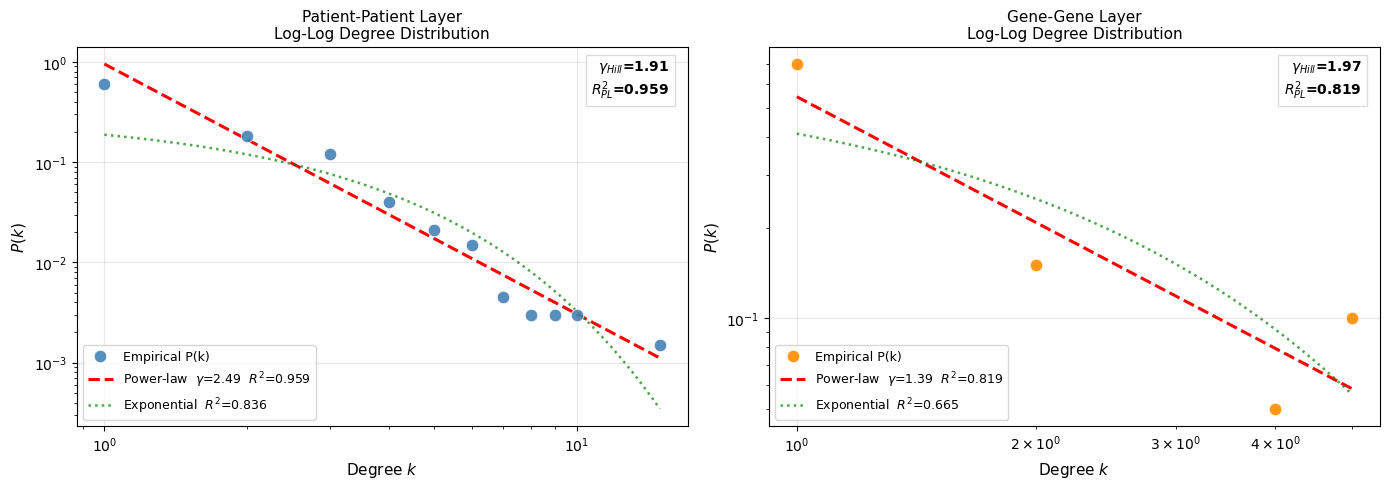

Saved: scalefree_degree_dist.png


In [4]:
# 4. Graph Construction — Bipartite + Dual Scale-Free Layers
# ============================================================================
def to_dev(graph):
    return graph.to(device)


def construct_scalefree_bipartite_heterograph(df, ba_m=2, seed=42, scaler=None):
    """
    Full dual scale-free heterograph with 4 edge types.

    Parameters
    ----------
    scaler : StandardScaler or None
        If provided, uses pre-fit scaler (prevents data leakage for eval sets).
        If None, fits a new scaler on df (used for CV fold training splits).
    """
    rng     = np.random.default_rng(seed)
    mut_mat = df[gene_columns].values.astype(int)
    n_p     = len(df)

    graph = HeteroData()

    # ── Patient feature encoding ──────────────────────────────────────────
    if scaler is None:
        scaler = StandardScaler()
        scaler.fit(df[['Age_at_diagnosis']].values.astype(float))
    age_norm = scaler.transform(df[['Age_at_diagnosis']].values.astype(float))
    gender   = df[['Gender']].values.astype(float)
    race_ohe = np.zeros((len(df), 4), dtype=float)
    for i, rv in enumerate(df['Race'].values.astype(int)):
        if 0 <= rv < 4:
            race_ohe[i, rv] = 1.0
    pat_feats = np.hstack([gender, race_ohe, age_norm])
    graph["Patient"].x = torch.tensor(pat_feats, dtype=torch.float)
    graph["Patient"].y = torch.tensor(df["Grade"].values, dtype=torch.long)
    graph["Gene"].x    = torch.eye(NUM_GENES, dtype=torch.float)

    # ── Bipartite edges ──────────────────────────────────────────────────
    src_genes, dst_pats = [], []
    for p_idx, row in enumerate(mut_mat):
        for g_idx in np.where(row == 1)[0]:
            src_genes.append(g_idx); dst_pats.append(p_idx)

    graph[("Gene",   "mutates",   "Patient")].edge_index = torch.tensor([src_genes, dst_pats ], dtype=torch.long)
    graph[("Patient","mutated_by","Gene"   )].edge_index = torch.tensor([dst_pats,  src_genes], dtype=torch.long)

    # ── Patient-Patient: Sequential Barabasi-Albert ──────────────────────
    seed_deg = np.zeros(n_p, dtype=float)
    for g in range(NUM_GENES):
        carriers = np.where(mut_mat[:, g] == 1)[0]
        for i in range(len(carriers)):
            for j in range(i+1, min(i+50, len(carriers))):
                a, b = int(carriers[i]), int(carriers[j])
                seed_deg[a] += 1; seed_deg[b] += 1
    seed_deg = np.maximum(seed_deg, 1.0)

    order   = np.argsort(-seed_deg)
    degree  = np.zeros(n_p, dtype=float)
    pp_edge_set = set()

    for i in range(ba_m + 1):
        for j in range(i + 1, ba_m + 1):
            a, b = int(order[i]), int(order[j])
            pp_edge_set.add((min(a,b), max(a,b)))
            degree[a] += 1; degree[b] += 1

    for step in range(ba_m + 1, n_p):
        new_node = int(order[step])
        existing = order[:step]
        ed       = degree[existing] + seed_deg[existing]
        probs    = ed / ed.sum()
        for t in rng.choice(existing, size=min(ba_m, len(existing)),
                             replace=False, p=probs):
            a, b = min(new_node, int(t)), max(new_node, int(t))
            pp_edge_set.add((a, b))
            degree[new_node] += 1; degree[int(t)] += 1

    if pp_edge_set:
        pp_s, pp_d = zip(*pp_edge_set)
        graph[("Patient","cooccurs","Patient")].edge_index = torch.tensor(
            [list(pp_s)+list(pp_d), list(pp_d)+list(pp_s)], dtype=torch.long)
    else:
        graph[("Patient","cooccurs","Patient")].edge_index = torch.zeros(2, 0, dtype=torch.long)

    # ── Gene-Gene: Sequential BA seeded by mutation frequency ────────────
    ba_m_gene = 2
    gene_mut_freq = np.maximum(mut_mat.sum(axis=0).astype(float), 1.0)
    freq_order    = np.argsort(-gene_mut_freq)
    gg_degree     = np.zeros(NUM_GENES, dtype=float)
    gg_edge_set   = set()

    for i in range(ba_m_gene + 1):
        for j in range(i + 1, ba_m_gene + 1):
            a, b = int(freq_order[i]), int(freq_order[j])
            gg_edge_set.add((min(a, b), max(a, b)))
            gg_degree[a] += 1; gg_degree[b] += 1

    for step in range(ba_m_gene + 1, NUM_GENES):
        new_gene = int(freq_order[step])
        existing = freq_order[:step]
        ed       = gg_degree[existing] + gene_mut_freq[existing]
        probs    = ed / ed.sum()
        for t in rng.choice(existing, size=min(ba_m_gene, len(existing)),
                             replace=False, p=probs):
            a, b = min(new_gene, int(t)), max(new_gene, int(t))
            gg_edge_set.add((a, b))
            gg_degree[new_gene] += 1; gg_degree[int(t)] += 1

    if gg_edge_set:
        gg_s, gg_d = zip(*gg_edge_set)
        graph[("Gene","coexists","Gene")].edge_index = torch.tensor(
            [list(gg_s)+list(gg_d), list(gg_d)+list(gg_s)], dtype=torch.long)
    else:
        graph[("Gene","coexists","Gene")].edge_index = torch.zeros(2, 0, dtype=torch.long)

    return graph


# ── Scale-Free Verification ─────────────────────────────────────────────────
def _hill_mle(degrees, k_min=None):
    d = degrees[degrees > 0].astype(float)
    if k_min is None: k_min = d.min()
    tail = d[d >= k_min]
    if len(tail) < 2: return 0.0
    return 1.0 + len(tail) / np.sum(np.log(tail / (k_min - 0.5)))


def fit_powerlaw(degrees, label="Degrees"):
    n_nodes = len(degrees)
    k_vals, counts = np.unique(degrees[degrees > 0], return_counts=True)
    pmf   = counts / len(degrees[degrees > 0])
    log_k = np.log(k_vals.astype(float))
    log_p = np.log(pmf + 1e-12)

    sl_pl,  ic_pl,  r_pl,  *_ = stats.linregress(log_k, log_p)
    sl_exp, ic_exp, r_exp, *_ = stats.linregress(k_vals.astype(float), log_p)
    gamma_ols = -sl_pl
    r2_pl     = r_pl  ** 2
    r2_exp    = r_exp ** 2
    gamma_hill = _hill_mle(degrees)

    fitted_pl = np.exp(ic_pl) * (k_vals.astype(float) ** sl_pl)
    fitted_pl = fitted_pl / (fitted_pl.sum() + 1e-12)
    _, ks_p   = stats.ks_2samp(pmf, fitted_pl)

    small_n = n_nodes < 50
    gamma_report = gamma_hill if small_n else gamma_ols

    print(f"\n{'─'*55}\n  {label}\n{'─'*55}")
    print(f"  gamma={'Hill' if small_n else 'OLS'}: {gamma_report:.3f}  "
          f"R2_PL={r2_pl:.4f}  R2_exp={r2_exp:.4f}  KS_p={ks_p:.4f}")

    return gamma_report, r2_pl, r2_exp, ks_p


print("=" * 65)
print("SCALE-FREE VERIFICATION — BA Graph Layers")
print("=" * 65)

_sf_g  = construct_scalefree_bipartite_heterograph(train_val_df, ba_m=2, scaler=GLOBAL_SCALER)
_pp_ei = _sf_g[("Patient","cooccurs","Patient")].edge_index.cpu()
_gg_ei = _sf_g[("Gene","coexists","Gene")].edge_index.cpu()
_pp_d  = np.bincount(_pp_ei[0].numpy(), minlength=_sf_g["Patient"].x.shape[0]) // 2
_gg_d  = np.bincount(_gg_ei[0].numpy(), minlength=NUM_GENES) // 2

fit_powerlaw(_pp_d, "Patient-Patient (seq BA)")
fit_powerlaw(_gg_d, "Gene-Gene (seq BA)")

print(f"\n  PP edges (undirected): {_pp_ei.shape[1]//2}")
print(f"  GG edges (undirected): {_gg_ei.shape[1]//2}")
print(f"  GP edges:              {_sf_g[('Gene','mutates','Patient')].edge_index.shape[1]}")

# ── Plot degree distributions (paper figures) ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, d, label, color in [
    (axes[0], _pp_d, "Patient-Patient", "steelblue"),
    (axes[1], _gg_d, "Gene-Gene", "darkorange"),
]:
    k, c = np.unique(d[d > 0], return_counts=True)
    pmf  = c / c.sum()
    ax.loglog(k, pmf, "o", color=color, ms=9, alpha=0.90,
               markeredgecolor="white", markeredgewidth=0.6, zorder=4, label="Empirical P(k)")
    log_k = np.log(k.astype(float))
    log_p = np.log(pmf + 1e-12)
    sl_pl, ic_pl, r_pl, *_ = stats.linregress(log_k, log_p)
    sl_ex, ic_ex, r_ex, *_ = stats.linregress(k.astype(float), log_p)
    k_sm = np.linspace(k.min(), k.max(), 100)
    ax.loglog(k_sm, np.exp(ic_pl + sl_pl * np.log(k_sm)), "r--", lw=2.2,
               label=f"Power-law  $\\gamma$={-sl_pl:.2f}  $R^2$={r_pl**2:.3f}")
    ax.loglog(k_sm, np.exp(ic_ex + sl_ex * k_sm), "g:", lw=1.8,
               label=f"Exponential  $R^2$={r_ex**2:.3f}", alpha=0.7)
    ax.set_xlabel("Degree $k$", fontsize=11)
    ax.set_ylabel("$P(k)$", fontsize=11)
    ax.set_title(f"{label} Layer\nLog-Log Degree Distribution", fontsize=11)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    gamma_h = _hill_mle(d)
    ax.text(0.97, 0.97, f"$\\gamma_{{Hill}}$={gamma_h:.2f}\n$R^2_{{PL}}$={r_pl**2:.3f}",
             transform=ax.transAxes, fontsize=10, fontweight="bold",
             va="top", ha="right",
             bbox=dict(fc="white", alpha=0.8, ec="lightgray"))
plt.tight_layout()
plt.savefig("scalefree_degree_dist.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: scalefree_degree_dist.png")

In [5]:
# 5. Build Shared Evaluation Graphs (using GLOBAL_SCALER)
# ============================================================================
val_graph  = to_dev(construct_scalefree_bipartite_heterograph(val_df,  scaler=GLOBAL_SCALER))
test_graph = to_dev(construct_scalefree_bipartite_heterograph(test_df, scaler=GLOBAL_SCALER))
cgga_graph = to_dev(construct_scalefree_bipartite_heterograph(cgga_df, scaler=GLOBAL_SCALER))

print("Val  graph:", val_graph['Patient'].x.shape[0], "patients")
print("Test graph:", test_graph['Patient'].x.shape[0], "patients")
print("CGGA graph:", cgga_graph['Patient'].x.shape[0], "patients")

Val  graph: 134 patients
Test graph: 168 patients
CGGA graph: 284 patients


In [6]:
# 6. Model Definitions (7 architectures)
# ============================================================================

# ── 1. HeteroGATv2 ──────────────────────────────────────────────────────────
class HeteroGATv2(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin     = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.clin_skip = Linear(-1, hidden_dim)
        self.gg_conv = GCNConv(hidden_dim, hidden_dim)
        self.g2p = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.p2g = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.p_skip = Linear(hidden_dim, hidden_dim); self.g_skip = Linear(hidden_dim, hidden_dim)
        self.pp_conv = GCNConv(hidden_dim, hidden_dim)
        self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        ei    = graph.edge_index_dict
        x_pat = graph['Patient'].x
        h_clin = F.relu(self.clin_skip(x_pat))
        hp = F.relu(self.p_lin(x_pat))
        hg = F.relu(self.g_lin(graph['Gene'].x))
        gg_ei = graph[('Gene','coexists','Gene')].edge_index.to(hg.device)
        if gg_ei.shape[1] > 0:
            hg = hg + F.relu(self.gg_conv(hg, gg_ei))
        hp = self.p_skip(hp) + self.g2p((hg, hp), ei[('Gene','mutates','Patient')])
        hg = self.g_skip(hg) + self.p2g((hp, hg), ei[('Patient','mutated_by','Gene')])
        pp_ei = graph[('Patient','cooccurs','Patient')].edge_index.to(hp.device)
        hp = hp + self.pp_conv(hp, pp_ei)
        hp = F.dropout(F.leaky_relu(hp, 0.2), self.dr, training=self.training) + h_clin
        return self.clf(hp)

    def _get_enriched_gene_emb(self, graph):
        hg    = F.relu(self.g_lin(graph['Gene'].x))
        gg_ei = graph[('Gene','coexists','Gene')].edge_index.to(hg.device)
        if gg_ei.shape[1] > 0:
            hg = hg + F.relu(self.gg_conv(hg, gg_ei))
        return hg

    def get_attn_weights(self, graph):
        ei = graph.edge_index_dict
        hp = F.relu(self.p_lin(graph['Patient'].x))
        hg = self._get_enriched_gene_emb(graph)
        _, (eidx, alpha) = self.g2p((hg, hp), ei[('Gene','mutates','Patient')],
                                     return_attention_weights=True)
        return eidx, alpha.detach().mean(dim=-1)

    def get_all_heads_attn(self, graph):
        ei = graph.edge_index_dict
        hp = F.relu(self.p_lin(graph['Patient'].x))
        hg = self._get_enriched_gene_emb(graph)
        _, (eidx, alpha) = self.g2p((hg, hp), ei[('Gene','mutates','Patient')],
                                     return_attention_weights=True)
        return eidx, alpha.detach()

    def get_p2g_attn_weights(self, graph):
        ei    = graph.edge_index_dict
        hp    = F.relu(self.p_lin(graph['Patient'].x))
        hg    = self._get_enriched_gene_emb(graph)
        hp_upd = self.p_skip(hp) + self.g2p((hg, hp), ei[('Gene','mutates','Patient')])
        _, (eidx_r, alpha_r) = self.p2g((hp_upd, hg), ei[('Patient','mutated_by','Gene')],
                                         return_attention_weights=True)
        return eidx_r, alpha_r.detach().mean(dim=-1)


# ── 2. MOGAT ─────────────────────────────────────────────────────────────────
class MOGAT(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.pg = Linear(-1, hidden_dim); self.gg = Linear(-1, hidden_dim)
        self.gg_conv = GCNConv(hidden_dim, hidden_dim)
        self.gat = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.pc = Linear(-1, hidden_dim)
        self.mlp = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim))
        self.gate = nn.Linear(hidden_dim * 2, 2)
        self.pp_conv = GCNConv(hidden_dim, hidden_dim)
        self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        e   = graph[('Gene','mutates','Patient')].edge_index
        hpg = F.relu(self.pg(graph['Patient'].x))
        hgg = F.relu(self.gg(graph['Gene'].x))
        gg_ei = graph[('Gene','coexists','Gene')].edge_index.to(hgg.device)
        if gg_ei.shape[1] > 0:
            hgg = hgg + F.relu(self.gg_conv(hgg, gg_ei))
        hpg = F.dropout(F.leaky_relu(self.gat((hgg, hpg), e), 0.2), self.dr, training=self.training)
        hpc = self.mlp(F.relu(self.pc(graph['Patient'].x)))
        g   = torch.softmax(self.gate(torch.cat([hpg, hpc], -1)), dim=-1)
        hp  = g[:, :1] * hpg + g[:, 1:] * hpc
        pp_ei = graph[('Patient','cooccurs','Patient')].edge_index.to(hp.device)
        hp = hp + self.pp_conv(hp, pp_ei)
        return self.clf(hp)

    def _get_enriched_gene_emb(self, graph):
        hgg   = F.relu(self.gg(graph['Gene'].x))
        gg_ei = graph[('Gene','coexists','Gene')].edge_index.to(hgg.device)
        if gg_ei.shape[1] > 0:
            hgg = hgg + F.relu(self.gg_conv(hgg, gg_ei))
        return hgg

    def get_attn_weights(self, graph):
        e   = graph[('Gene','mutates','Patient')].edge_index
        hpg = F.relu(self.pg(graph['Patient'].x))
        hgg = self._get_enriched_gene_emb(graph)
        _, (eidx, alpha) = self.gat((hgg, hpg), e, return_attention_weights=True)
        return eidx, alpha.detach().mean(dim=-1)

    def get_all_heads_attn(self, graph):
        e   = graph[('Gene','mutates','Patient')].edge_index
        hpg = F.relu(self.pg(graph['Patient'].x))
        hgg = self._get_enriched_gene_emb(graph)
        _, (eidx, alpha) = self.gat((hgg, hpg), e, return_attention_weights=True)
        return eidx, alpha.detach()

    def get_fusion_gate(self, graph):
        e   = graph[('Gene','mutates','Patient')].edge_index
        hpg = F.relu(self.pg(graph['Patient'].x))
        hgg = self._get_enriched_gene_emb(graph)
        hpg_out = F.leaky_relu(self.gat((hgg, hpg), e), 0.2)
        hpc     = self.mlp(F.relu(self.pc(graph['Patient'].x)))
        gate_w  = torch.softmax(self.gate(torch.cat([hpg_out, hpc], -1)), dim=-1)
        return gate_w.detach()


# ── 3. HyperTMO ─────────────────────────────────────────────────────────────
class HyperTMO(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, in_channels=6, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin     = nn.Linear(in_channels, hidden_dim)
        self.clin_skip = nn.Linear(in_channels, hidden_dim)
        self.g_lin     = nn.Linear(NUM_GENES, hidden_dim)
        self.hc1 = HypergraphConv(hidden_dim, hidden_dim, use_attention=True,
                                   heads=num_heads, dropout=dropout, concat=False)
        self.hc2 = HypergraphConv(hidden_dim, hidden_dim)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim)
        self.pp_conv = GCNConv(hidden_dim, hidden_dim)
        self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x; xg = graph['Gene'].x
        h_clin = F.relu(self.clin_skip(xp))
        ei  = graph[('Gene','mutates','Patient')].edge_index
        hei = torch.stack([ei[1], ei[0]], dim=0)
        hp = F.relu(self.p_lin(xp)); hg = F.relu(self.g_lin(xg)); s = self.skip(hp)
        hp = F.relu(self.hc1(hp, hei, hyperedge_attr=hg))
        hp = F.dropout(hp, self.dr, training=self.training)
        hp = self.bn(F.relu(self.hc2(hp, hei) + s))
        pp_ei = graph[('Patient','cooccurs','Patient')].edge_index.to(hp.device)
        hp = hp + self.pp_conv(hp, pp_ei)
        return self.clf(F.dropout(hp, self.dr, training=self.training))


# ── 4. RGCN (FIX: aggregate gene info before homogeneous conv) ───────────────
class RGCNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 in_channels=6, num_relations=20, **_):
        super().__init__()
        self.dr = dropout
        self.lin = nn.Linear(in_channels, hidden_dim)
        self.g_lin = nn.Linear(NUM_GENES, hidden_dim)
        self.gene_agg = nn.Linear(hidden_dim, hidden_dim)
        self.rc1 = RGCNConv(hidden_dim, hidden_dim, num_relations=num_relations)
        self.rc2 = RGCNConv(hidden_dim, hidden_dim, num_relations=num_relations)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x
        hp = F.relu(self.lin(xp))
        hg = F.relu(self.g_lin(graph['Gene'].x))
        g2p_ei = graph[('Gene','mutates','Patient')].edge_index
        if g2p_ei.shape[1] > 0:
            gene_msg = hg[g2p_ei[0]]
            gene_agg = torch.zeros_like(hp)
            gene_agg.scatter_add_(0, g2p_ei[1].unsqueeze(-1).expand_as(gene_msg), gene_msg)
            deg = torch.zeros(hp.shape[0], device=hp.device)
            deg.scatter_add_(0, g2p_ei[1], torch.ones(g2p_ei.shape[1], device=hp.device))
            deg = deg.clamp(min=1).unsqueeze(-1)
            hp = hp + F.relu(self.gene_agg(gene_agg / deg))
        pp_ei = graph[('Patient','cooccurs','Patient')].edge_index.to(xp.device)
        pp_et = torch.zeros(pp_ei.shape[1], dtype=torch.long, device=xp.device)
        s = self.skip(hp)
        h = F.relu(self.rc1(hp, pp_ei, pp_et))
        h = F.dropout(h, self.dr, training=self.training)
        h = self.bn(F.relu(self.rc2(h, pp_ei, pp_et) + s))
        return self.clf(F.dropout(h, self.dr, training=self.training))


# ── 5. VEGN (FIX: was discarding gene-patient aggregation) ──────────────────
class VEGNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2, **_):
        super().__init__()
        self.dr = dropout
        self.p_lin     = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.clin_skip = Linear(-1, hidden_dim)
        self.ve = nn.Sequential(nn.Linear(hidden_dim*2, hidden_dim), nn.ReLU(),
                                 nn.Linear(hidden_dim, 1), nn.Sigmoid())
        self.p2g = GATv2Conv(hidden_dim, hidden_dim, heads=num_heads, concat=False, add_self_loops=False)
        self.skip = Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim)
        self.pp_conv = GCNConv(hidden_dim, hidden_dim)
        self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x; xg = graph['Gene'].x
        h_clin = F.relu(self.clin_skip(xp))
        e_g2p = graph[('Gene','mutates','Patient')].edge_index
        e_p2g = graph[('Patient','mutated_by','Gene')].edge_index
        hp = F.relu(self.p_lin(xp)); hg = F.relu(self.g_lin(xg))
        sg, dp = e_g2p[0], e_g2p[1]
        wt = self.ve(torch.cat([hg[sg], hp[dp]], -1)).squeeze(-1)
        msg = hg[sg] * wt.unsqueeze(-1)
        agg = torch.zeros_like(hp); agg.scatter_add_(0, dp.unsqueeze(-1).expand_as(msg), msg)
        deg = torch.zeros(hp.shape[0], device=hp.device)
        deg.scatter_add_(0, dp, wt); deg = deg.clamp(min=1)
        agg = agg / deg.unsqueeze(-1)
        _ = self.p2g((hp, hg), e_p2g)
        # FIX: use aggregated features (was returning stale hp, ignoring agg + pp_conv)
        hp = self.bn(F.leaky_relu(self.skip(hp) + agg, 0.2))
        pp_ei = graph[('Patient','cooccurs','Patient')].edge_index.to(hp.device)
        hp = hp + self.pp_conv(hp, pp_ei)
        hp = F.dropout(hp, self.dr, training=self.training) + h_clin
        return self.clf(hp)


# ── 6. FastHGTConv ───────────────────────────────────────────────────────────
_HGT_META_SF = (['Patient','Gene'],
                [('Gene','mutates','Patient'),('Patient','mutated_by','Gene'),
                 ('Patient','cooccurs','Patient'),('Gene','coexists','Gene')])

class FastHGTModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 hgt_meta=None, **_):
        super().__init__()
        self.dr = dropout
        meta = hgt_meta if hgt_meta is not None else _HGT_META_SF
        self.p_lin     = Linear(-1, hidden_dim); self.g_lin = Linear(-1, hidden_dim)
        self.clin_skip = Linear(-1, hidden_dim)
        self.hgt1 = HGTConv(hidden_dim, hidden_dim, metadata=meta, heads=num_heads)
        self.hgt2 = HGTConv(hidden_dim, hidden_dim, metadata=meta, heads=num_heads)
        self.skip = Linear(hidden_dim, hidden_dim)
        self.bn = nn.BatchNorm1d(hidden_dim); self.clf = Linear(hidden_dim, out_dim)

    def forward(self, graph):
        h_clin = F.relu(self.clin_skip(graph['Patient'].x))
        xd = {'Patient': F.relu(self.p_lin(graph['Patient'].x)),
              'Gene':    F.relu(self.g_lin(graph['Gene'].x))}
        sp = self.skip(xd['Patient']); ei = graph.edge_index_dict
        xd = {k: F.dropout(F.relu(v), self.dr, training=self.training)
              for k, v in self.hgt1(xd, ei).items()}
        xd = self.hgt2(xd, ei)
        hp = self.bn(F.relu(xd['Patient'] + sp))
        return self.clf(F.dropout(hp, self.dr, training=self.training) + h_clin)


# ── 7. SGNN (FIX: aggregate gene info before spectral conv) ──────────────────
class SGNNModel(nn.Module):
    def __init__(self, hidden_dim=32, out_dim=2, num_heads=4, dropout=0.2,
                 in_channels=6, K=3, **_):
        super().__init__()
        self.dr = dropout
        self.lin = nn.Linear(in_channels, hidden_dim)
        self.g_lin = nn.Linear(NUM_GENES, hidden_dim)
        self.gene_agg = nn.Linear(hidden_dim, hidden_dim)
        self.c1 = ChebConv(hidden_dim, hidden_dim, K=K)
        self.c2 = ChebConv(hidden_dim, hidden_dim, K=K)
        self.skip = nn.Linear(hidden_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim); self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.clf = nn.Linear(hidden_dim, out_dim)

    def forward(self, graph):
        xp = graph['Patient'].x
        hp = F.relu(self.lin(xp))
        hg = F.relu(self.g_lin(graph['Gene'].x))
        g2p_ei = graph[('Gene','mutates','Patient')].edge_index
        if g2p_ei.shape[1] > 0:
            gene_msg = hg[g2p_ei[0]]
            gene_agg = torch.zeros_like(hp)
            gene_agg.scatter_add_(0, g2p_ei[1].unsqueeze(-1).expand_as(gene_msg), gene_msg)
            deg = torch.zeros(hp.shape[0], device=hp.device)
            deg.scatter_add_(0, g2p_ei[1], torch.ones(g2p_ei.shape[1], device=hp.device))
            deg = deg.clamp(min=1).unsqueeze(-1)
            hp = hp + F.relu(self.gene_agg(gene_agg / deg))
        pp_ei = graph[('Patient','cooccurs','Patient')].edge_index.to(xp.device)
        s = self.skip(hp)
        h = self.bn1(F.relu(self.c1(hp, pp_ei)))
        h = F.dropout(h, self.dr, training=self.training)
        h = self.bn2(F.relu(self.c2(h, pp_ei) + s))
        return self.clf(F.dropout(h, self.dr, training=self.training))


MODEL_REGISTRY = [
    ('HeteroGATv2', HeteroGATv2,  {}),
    ('MOGAT',       MOGAT,        {}),
    ('HyperTMO',    HyperTMO,     {'in_channels': 6}),
    ('RGCN',        RGCNModel,    {'in_channels': 6, 'num_relations': NUM_GENES}),
    ('VEGN',        VEGNModel,    {}),
    ('FastHGTConv', FastHGTModel, {'hgt_meta': _HGT_META_SF}),
    ('SGNN',        SGNNModel,    {'in_channels': 6}),
]
print(f"Registered {len(MODEL_REGISTRY)} models:", [n for n,_,_ in MODEL_REGISTRY])

Registered 7 models: ['HeteroGATv2', 'MOGAT', 'HyperTMO', 'RGCN', 'VEGN', 'FastHGTConv', 'SGNN']


In [7]:
# 7. Focal Loss + Class Weights
# ============================================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, weight=None):
        super().__init__()
        self.a, self.g, self.w = alpha, gamma, weight
    def forward(self, inp, tgt):
        ce = F.cross_entropy(inp, tgt, weight=self.w, reduction='none')
        return (self.a * (1 - torch.exp(-ce)) ** self.g * ce).mean()


def make_criterion(train_graph, verbose=False):
    """Compute focal loss with inverse-frequency weights from the ACTUAL training distribution.
    After augmentation (SMOTE/CTGAN/ROS) the classes are balanced, so weights ≈ 1.0/1.0.
    Without augmentation the minority class gets upweighted as intended."""
    labels = train_graph['Patient'].y.cpu().numpy()
    n0 = float((labels == 0).sum())
    n1 = float((labels == 1).sum())
    total = n0 + n1
    w0 = total / (2.0 * n0)
    w1 = total / (2.0 * n1)
    cw = torch.tensor([w0, w1], dtype=torch.float).to(device)
    if verbose:
        print(f"    Class weights: Grade-0={w0:.4f}  Grade-1={w1:.4f}  (n0={int(n0)}, n1={int(n1)})")
    return FocalLoss(alpha=1, gamma=2, weight=cw)

In [8]:
# 8. Threshold Optimisation + Evaluation Helpers
# ============================================================================
def find_optimal_threshold(probs, labels, low=0.20, high=0.80, step=0.005):
    best_th, best_gm, best_imb = 0.5, -1.0, 1.0
    for th in np.arange(low, high + step * 0.5, step):
        preds = (probs >= th).astype(int)
        r1  = recall_score(labels, preds, pos_label=1, zero_division=0)
        r0  = recall_score(labels, preds, pos_label=0, zero_division=0)
        gm  = np.sqrt(r0 * r1)
        imb = abs(r1 - r0)
        if gm > best_gm + 0.005:
            best_gm = gm; best_th = float(th); best_imb = imb
        elif gm >= best_gm - 0.005 and imb < best_imb:
            best_th = float(th); best_imb = imb
    return best_th


def evaluate_model(model, graph, threshold=0.5):
    model.eval()
    with torch.no_grad():
        logits = model(graph)
        probs  = F.softmax(logits, 1)[:, 1].cpu().numpy()
        labels = graph['Patient'].y.cpu().numpy()
    preds = (probs >= threshold).astype(int)
    return preds, probs, labels


def compute_metrics(preds, probs, labels):
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        auc = float('nan')
    return {
        'auc':       auc,
        'accuracy':  accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall':    recall_score(labels, preds, zero_division=0),
        'recall_0':  recall_score(labels, preds, pos_label=0, zero_division=0),
        'f1':        f1_score(labels, preds, zero_division=0),
    }

all_results    = []
cv_results     = []
all_models     = {}
all_studies    = {}
all_params     = {}
all_thresholds = {}
PIPELINES      = ['No Balancing', 'SMOTE', 'CTGAN', 'ROS']

In [9]:
# 9. Training Function
# ============================================================================
def train_and_evaluate(train_graph, val_graph, params, ModelClass,
                        fixed_kw=None, max_epochs=MAX_EPOCHS, patience=PATIENCE,
                        seed=42, loss_fn=None):
    set_seed(seed)
    if loss_fn is None:
        loss_fn = make_criterion(train_graph)
    kw = {'hidden_dim': params['hidden_dim'], 'out_dim': 2,
          'num_heads':  params['num_heads'],  'dropout': params['dropout']}
    if fixed_kw: kw.update(fixed_kw)

    model = ModelClass(**kw).to(device)
    try:
        with torch.no_grad(): _ = model(train_graph)
    except Exception: pass

    opt = torch.optim.AdamW(model.parameters(),
                              lr=params['lr'], weight_decay=params['weight_decay'])
    sch = CosineAnnealingLR(opt, T_max=max_epochs, eta_min=params['lr'] * 0.05)

    best_auc, ctr, best_state, history = 0.0, 0, None, []
    for _ in range(max_epochs):
        model.train(); opt.zero_grad()
        loss = loss_fn(model(train_graph), train_graph['Patient'].y)
        loss.backward(); opt.step(); sch.step()

        model.eval()
        with torch.no_grad():
            vp  = F.softmax(model(val_graph), 1)[:, 1].cpu().numpy()
            vl  = val_graph['Patient'].y.cpu().numpy()
        try:    auc = roc_auc_score(vl, vp)
        except: auc = 0.0
        history.append(auc)

        if auc > best_auc:
            best_auc, ctr = auc, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            ctr += 1
            if ctr >= patience: break

    return best_auc, best_state, history

In [10]:
# 10. Optuna HPO
# ============================================================================
def run_optuna(train_graph, val_graph, ModelClass, fixed_kw=None,
               n_trials=N_TRIALS, label=''):
    hpo_criterion = make_criterion(train_graph, verbose=True)

    def objective(trial):
        set_seed(42)
        params = {
            'hidden_dim':   trial.suggest_categorical('hidden_dim', [16, 32, 64, 128]),
            'num_heads':    trial.suggest_categorical('num_heads',  [2, 4, 8]),
            'dropout':      trial.suggest_float('dropout', 0.05, 0.30, step=0.05),
            'lr':           trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True),
        }
        auc, _, _ = train_and_evaluate(train_graph, val_graph, params, ModelClass,
                                        fixed_kw, loss_fn=hpo_criterion)
        return auc

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    bp = study.best_params
    print(f"  [{label}] Best AUC={study.best_value:.4f}  params={bp}")
    _, best_state, _ = train_and_evaluate(train_graph, val_graph, bp, ModelClass,
                                           fixed_kw, loss_fn=hpo_criterion)
    return bp, best_state, study

In [11]:
# 11. 5-Fold CV (FIX: scaler fit on fold training data before augmentation)
# ============================================================================
def apply_smote(fold_train_df):
    feat_cols = gene_columns + ['Gender','Race','Age_at_diagnosis']
    cat_idx   = [i for i,c in enumerate(feat_cols)
                  if c in gene_columns or c in ['Gender','Race']]
    sm = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=3)
    Xr, yr = sm.fit_resample(fold_train_df[feat_cols], fold_train_df['Grade'])
    df2 = pd.DataFrame(Xr, columns=feat_cols); df2['Grade'] = yr
    for c in gene_columns: df2[c] = df2[c].round().astype(int)
    df2['Race']   = df2['Race'].round().astype(int).clip(0, 3)
    df2['Gender'] = df2['Gender'].round().astype(int).clip(0, 1)
    return df2


def apply_ctgan(fold_train_df):
    meta = SingleTableMetadata()
    meta.detect_from_dataframe(fold_train_df)
    for col in categorical_columns + gene_columns:
        meta.update_column(column_name=col, sdtype='categorical')
    vc    = fold_train_df['Grade'].value_counts()
    n_gen = int(vc.max() - vc.min())
    if n_gen <= 0:
        return fold_train_df
    # CTGAN uses CUDA ops that may lack deterministic implementations,
    # so temporarily relax the constraint during GAN training.
    set_seed(42)
    try:
        torch.use_deterministic_algorithms(False)
    except AttributeError:
        pass
    syn = CTGANSynthesizer(meta, epochs=100, batch_size=50, verbose=False, cuda=True, pac=10)
    syn.fit(fold_train_df)
    cond  = Condition(num_rows=n_gen, column_values={'Grade': int(vc.idxmin())})
    extra = syn.sample_from_conditions(conditions=[cond])
    # Re-enable deterministic mode for model training
    try:
        torch.use_deterministic_algorithms(True)
    except AttributeError:
        pass
    return pd.concat([fold_train_df, extra], ignore_index=True)


def apply_ros(fold_train_df, seed=42):
    feat_cols = gene_columns + ["Gender", "Race", "Age_at_diagnosis"]
    ros = RandomOverSampler(sampling_strategy="auto", random_state=seed)
    Xr, yr = ros.fit_resample(fold_train_df[feat_cols], fold_train_df["Grade"])
    df2 = pd.DataFrame(Xr, columns=feat_cols)
    df2["Grade"] = yr
    for c in gene_columns: df2[c] = df2[c].astype(int)
    df2['Race']   = df2['Race'].astype(int).clip(0, 3)
    df2["Gender"] = df2["Gender"].astype(int).clip(0, 1)
    return df2


def run_5fold_cv(train_val_df, best_params, ModelClass, fixed_kw,
                  pipeline_name, model_name,
                  augment_fn=None, graph_fn=None):
    if graph_fn is None:
        graph_fn = construct_scalefree_bipartite_heterograph

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_records = []

    for fold, (tr_idx, vl_idx) in enumerate(
            skf.split(train_val_df, train_val_df['Grade']), start=1):
        fold_tr = train_val_df.iloc[tr_idx].copy().reset_index(drop=True)
        fold_vl = train_val_df.iloc[vl_idx].copy().reset_index(drop=True)

        # Seed for augmentation phase (CTGAN/SMOTE)
        set_seed(42 + fold)

        # FIX: fit scaler on ORIGINAL fold training data BEFORE augmentation
        fold_scaler = StandardScaler()
        fold_scaler.fit(fold_tr[['Age_at_diagnosis']].values.astype(float))

        if augment_fn is not None:
            fold_tr = augment_fn(fold_tr)

        # FIX: reseed AFTER augmentation so model training is deterministic
        # regardless of how many RNG calls CTGAN/SMOTE consumed above.
        # Uses fold-specific seed so each fold is independent but reproducible.
        set_seed(42 + fold * 1000)

        # FIX: pass fold_scaler so val uses training-fit normalisation
        tr_g = to_dev(graph_fn(fold_tr, scaler=fold_scaler))
        vl_g = to_dev(graph_fn(fold_vl, scaler=fold_scaler))

        # FIX: class weights from actual fold training distribution (post-augmentation)
        fold_criterion = make_criterion(tr_g)
        _, state, _ = train_and_evaluate(tr_g, vl_g, best_params, ModelClass, fixed_kw,
                                          loss_fn=fold_criterion)

        kw = {'hidden_dim': best_params['hidden_dim'], 'out_dim': 2,
              'num_heads':  best_params['num_heads'],  'dropout': best_params['dropout']}
        kw.update(fixed_kw)
        fold_model = ModelClass(**kw).to(device)
        try:
            with torch.no_grad(): _ = fold_model(tr_g)
        except: pass
        fold_model.load_state_dict(state)

        _, probs_v, labels_v = evaluate_model(fold_model, vl_g, threshold=0.5)
        th = find_optimal_threshold(probs_v, labels_v)
        preds_v = (probs_v >= th).astype(int)

        m = compute_metrics(preds_v, probs_v, labels_v)
        m.update({'fold': fold, 'threshold': th,
                  'Model': model_name, 'Pipeline': pipeline_name})
        fold_records.append(m)
        print(f"    Fold {fold}/5 | AUC={m['auc']:.4f} "
              f"R1={m['recall']:.3f} R0={m['recall_0']:.3f} "
              f"F1={m['f1']:.4f} th={th:.2f}")

    return pd.DataFrame(fold_records)

In [12]:
# 12. Pipeline Runner (FIX: scaler fit before augmentation)
# ============================================================================
def run_pipeline(pipeline_name, train_graph_hpo,
                  augment_fn=None, graph_fn=None):
    if graph_fn is None:
        graph_fn = construct_scalefree_bipartite_heterograph

    print(f"\n{'='*65}")
    print(f"PIPELINE: {pipeline_name}")
    print(f"{'='*65}")

    for mname, MCls, fkw in MODEL_REGISTRY:
        print(f"\n  -- {mname} --")

        bp, hpo_state, study = run_optuna(
            train_graph_hpo, val_graph, MCls, fkw,
            label=f"{mname}/{pipeline_name}")
        all_studies[(mname, pipeline_name)] = study
        all_params[(mname, pipeline_name)]  = bp

        print(f"  5-Fold CV with best params:")
        cv_df = run_5fold_cv(train_val_df, bp, MCls, fkw,
                              pipeline_name, mname,
                              augment_fn=augment_fn,
                              graph_fn=graph_fn)
        cv_results.append(cv_df)
        for col in ['auc','accuracy','precision','recall','recall_0','f1','threshold']:
            if col in cv_df.columns:
                print(f"    {col:12s}: {cv_df[col].mean():.4f} +/- {cv_df[col].std():.4f}")

        # FIX: scaler fit on ORIGINAL train_val BEFORE augmentation
        final_scaler = StandardScaler()
        final_scaler.fit(train_val_df[['Age_at_diagnosis']].values.astype(float))

        if augment_fn is not None:
            aug_df = augment_fn(train_val_df.copy())
        else:
            aug_df = train_val_df

        full_tr_graph = to_dev(graph_fn(aug_df, scaler=final_scaler))

        # FIX: class weights from actual (post-augmentation) training distribution
        final_criterion = make_criterion(full_tr_graph, verbose=True)
        _, final_state, _ = train_and_evaluate(full_tr_graph, val_graph, bp, MCls, fkw,
                                                loss_fn=final_criterion)

        kw = {'hidden_dim': bp['hidden_dim'], 'out_dim': 2,
              'num_heads':  bp['num_heads'],  'dropout': bp['dropout']}
        kw.update(fkw)
        final_model = MCls(**kw).to(device)
        try:
            with torch.no_grad(): _ = final_model(full_tr_graph)
        except: pass
        final_model.load_state_dict(final_state)

        th = float(cv_df['threshold'].mean())
        all_thresholds[(mname, pipeline_name)] = th
        print(f"  Final threshold (mean of CV folds) = {th:.3f}")

        pdt, pbt, lbt = evaluate_model(final_model, test_graph,  threshold=th)
        pdc, pbc, lbc = evaluate_model(final_model, cgga_graph,  threshold=th)
        mt  = compute_metrics(pdt, pbt, lbt)
        mc_ = compute_metrics(pdc, pbc, lbc)
        print(f"  TCGA-Test  AUC={mt['auc']:.4f} R1={mt['recall']:.3f} R0={mt['recall_0']:.3f} F1={mt['f1']:.4f}")
        print(f"  CGGA       AUC={mc_['auc']:.4f} R1={mc_['recall']:.3f} R0={mc_['recall_0']:.3f} F1={mc_['f1']:.4f}")

        for ds, m, p, l in [('TCGA Test', mt, pbt, lbt), ('CGGA', mc_, pbc, lbc)]:
            rec = {'Model': mname, 'Pipeline': pipeline_name, 'Dataset': ds,
                   'threshold': th, 'probs': p, 'labels': l}
            rec.update(m)
            all_results.append(rec)
        all_models[(mname, pipeline_name)] = final_model

    print(f"\n[{pipeline_name}] Done.")

In [13]:
# 13. Pipeline A — No Balancing
# ============================================================================
hpo_scaler_nb = StandardScaler()
hpo_scaler_nb.fit(train_df[['Age_at_diagnosis']].values.astype(float))
train_nb_graph = to_dev(construct_scalefree_bipartite_heterograph(train_df, scaler=hpo_scaler_nb))
run_pipeline('No Balancing', train_graph_hpo=train_nb_graph, augment_fn=None,
             graph_fn=construct_scalefree_bipartite_heterograph)


PIPELINE: No Balancing

  -- HeteroGATv2 --
    Class weights: Grade-0=0.8629  Grade-1=1.1889  (n0=310, n1=225)


  0%|          | 0/30 [00:00<?, ?it/s]

  [HeteroGATv2/No Balancing] Best AUC=0.9428  params={'hidden_dim': 64, 'num_heads': 2, 'dropout': 0.1, 'lr': 0.001956664062825251, 'weight_decay': 0.00031623136832926394}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9369 R1=0.860 R0=0.883 F1=0.8522 th=0.50
    Fold 2/5 | AUC=0.9123 R1=0.857 R0=0.821 F1=0.8136 th=0.57
    Fold 3/5 | AUC=0.9144 R1=0.893 R0=0.872 F1=0.8621 th=0.48
    Fold 4/5 | AUC=0.9034 R1=0.946 R0=0.808 F1=0.8548 th=0.55
    Fold 5/5 | AUC=0.9207 R1=0.857 R0=0.870 F1=0.8421 th=0.51
    auc         : 0.9175 +/- 0.0125
    accuracy    : 0.8640 +/- 0.0170
    precision   : 0.8119 +/- 0.0327
    recall      : 0.8826 +/- 0.0387
    recall_0    : 0.8506 +/- 0.0340
    f1          : 0.8449 +/- 0.0190
    threshold   : 0.5200 +/- 0.0345
    Class weights: Grade-0=0.8621  Grade-1=1.1904  (n0=388, n1=281)
  Final threshold (mean of CV folds) = 0.520
  TCGA-Test  AUC=0.8613 R1=0.690 R0=0.845 F1=0.7259
  CGGA       AUC=0.5852 R1=0.804 R0=0.385 F1=0.5541

  -- MOGAT --
    

  0%|          | 0/30 [00:00<?, ?it/s]

  [MOGAT/No Balancing] Best AUC=0.9423  params={'hidden_dim': 128, 'num_heads': 4, 'dropout': 0.2, 'lr': 0.0012399967836846098, 'weight_decay': 2.3426581058204037e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9419 R1=0.895 R0=0.857 F1=0.8571 th=0.50
    Fold 2/5 | AUC=0.9125 R1=0.893 R0=0.795 F1=0.8197 th=0.48
    Fold 3/5 | AUC=0.9219 R1=0.875 R0=0.872 F1=0.8522 th=0.49
    Fold 4/5 | AUC=0.9176 R1=0.964 R0=0.808 F1=0.8640 th=0.56
    Fold 5/5 | AUC=0.9170 R1=0.857 R0=0.870 F1=0.8421 th=0.59
    auc         : 0.9222 +/- 0.0115
    accuracy    : 0.8640 +/- 0.0162
    precision   : 0.8042 +/- 0.0325
    recall      : 0.8968 +/- 0.0407
    recall_0    : 0.8403 +/- 0.0364
    f1          : 0.8470 +/- 0.0172
    threshold   : 0.5220 +/- 0.0456
    Class weights: Grade-0=0.8621  Grade-1=1.1904  (n0=388, n1=281)
  Final threshold (mean of CV folds) = 0.522
  TCGA-Test  AUC=0.8994 R1=0.845 R0=0.845 F1=0.8219
  CGGA       AUC=0.7052 R1=0.784 R0=0.516 F1=0.5926

  -- HyperTMO --
    C

...

  [VEGN/No Balancing] Best AUC=0.9480  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.1, 'lr': 0.006174340537393994, 'weight_decay': 0.0005794759003802647}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9239 R1=0.947 R0=0.805 F1=0.8571 th=0.42
    Fold 2/5 | AUC=0.9219 R1=0.893 R0=0.833 F1=0.8403 th=0.50
    Fold 3/5 | AUC=0.9302 R1=0.893 R0=0.885 F1=0.8696 th=0.50
    Fold 4/5 | AUC=0.9144 R1=0.911 R0=0.808 F1=0.8361 th=0.58
    Fold 5/5 | AUC=0.9309 R1=0.911 R0=0.857 F1=0.8644 th=0.44
    auc         : 0.9243 +/- 0.0067
    accuracy    : 0.8685 +/- 0.0153
    precision   : 0.8038 +/- 0.0307
    recall      : 0.9109 +/- 0.0223
    recall_0    : 0.8376 +/- 0.0337
    f1          : 0.8535 +/- 0.0147
    threshold   : 0.4860 +/- 0.0638
    Class weights: Grade-0=0.8621  Grade-1=1.1904  (n0=388, n1=281)
  Final threshold (mean of CV folds) = 0.486
  TCGA-Test  AUC=0.9127 R1=0.901 R0=0.825 F1=0.8421
  CGGA       AUC=0.5868 R1=0.735 R0=0.451 F1=0.5415

  -- FastHGTConv --
    Cl

  0%|          | 0/30 [00:00<?, ?it/s]

  [FastHGTConv/No Balancing] Best AUC=0.9437  params={'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.25, 'lr': 0.0029435348486161173, 'weight_decay': 0.0005757788845058073}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9357 R1=0.895 R0=0.857 F1=0.8571 th=0.48
    Fold 2/5 | AUC=0.9112 R1=0.929 R0=0.808 F1=0.8455 th=0.49
    Fold 3/5 | AUC=0.9320 R1=0.875 R0=0.885 F1=0.8596 th=0.55
    Fold 4/5 | AUC=0.9270 R1=0.964 R0=0.808 F1=0.8640 th=0.58
    Fold 5/5 | AUC=0.9321 R1=0.911 R0=0.844 F1=0.8571 th=0.44
    auc         : 0.9276 +/- 0.0097
    accuracy    : 0.8715 +/- 0.0081
    precision   : 0.8071 +/- 0.0284
    recall      : 0.9147 +/- 0.0341
    recall_0    : 0.8403 +/- 0.0331
    f1          : 0.8567 +/- 0.0068
    threshold   : 0.5060 +/- 0.0569
    Class weights: Grade-0=0.8621  Grade-1=1.1904  (n0=388, n1=281)
  Final threshold (mean of CV folds) = 0.506
  TCGA-Test  AUC=0.9120 R1=0.901 R0=0.845 F1=0.8533
  CGGA       AUC=0.4920 R1=0.804 R0=0.319 F1=0.5325

  -- SGNN --
    

  0%|          | 0/30 [00:00<?, ?it/s]

  [SGNN/No Balancing] Best AUC=0.9448  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.1, 'lr': 0.0037927492630521783, 'weight_decay': 0.00053588285377162}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9485 R1=0.912 R0=0.857 F1=0.8667 th=0.40
    Fold 2/5 | AUC=0.9020 R1=0.893 R0=0.833 F1=0.8403 th=0.39
    Fold 3/5 | AUC=0.9064 R1=0.839 R0=0.859 F1=0.8246 th=0.58
    Fold 4/5 | AUC=0.8984 R1=0.946 R0=0.782 F1=0.8413 th=0.54
    Fold 5/5 | AUC=0.9323 R1=0.875 R0=0.896 F1=0.8673 th=0.35
    auc         : 0.9175 +/- 0.0219
    accuracy    : 0.8655 +/- 0.0172
    precision   : 0.8092 +/- 0.0379
    recall      : 0.8932 +/- 0.0401
    recall_0    : 0.8455 +/- 0.0420
    f1          : 0.8480 +/- 0.0185
    threshold   : 0.4490 +/- 0.1040
    Class weights: Grade-0=0.8621  Grade-1=1.1904  (n0=388, n1=281)
  Final threshold (mean of CV folds) = 0.449
  TCGA-Test  AUC=0.8783 R1=0.845 R0=0.794 F1=0.7947
  CGGA       AUC=0.7505 R1=0.549 R0=0.780 F1=0.5657

[No Balancing] Done.


In [14]:
# 14. Pipeline B — SMOTE
# ============================================================================
feat_cols = gene_columns + ['Gender','Race','Age_at_diagnosis']
cat_idx   = [i for i,c in enumerate(feat_cols)
              if c in gene_columns or c in ['Gender','Race']]
smote   = SMOTENC(categorical_features=cat_idx, random_state=42, k_neighbors=3)
Xr, yr  = smote.fit_resample(train_df[feat_cols], train_df['Grade'])
train_smote_df = pd.DataFrame(Xr, columns=feat_cols); train_smote_df['Grade'] = yr
for c in gene_columns: train_smote_df[c] = train_smote_df[c].round().astype(int)
print("SMOTE HPO graph class dist:\n", train_smote_df['Grade'].value_counts())

hpo_scaler_sm = StandardScaler()
hpo_scaler_sm.fit(train_df[['Age_at_diagnosis']].values.astype(float))
train_sm_graph = to_dev(construct_scalefree_bipartite_heterograph(train_smote_df, scaler=hpo_scaler_sm))
run_pipeline('SMOTE', train_graph_hpo=train_sm_graph, augment_fn=apply_smote,
             graph_fn=construct_scalefree_bipartite_heterograph)

SMOTE HPO graph class dist:
 Grade
0    310
1    310
Name: count, dtype: int64

PIPELINE: SMOTE

  -- HeteroGATv2 --
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=310, n1=310)


  0%|          | 0/30 [00:00<?, ?it/s]

  [HeteroGATv2/SMOTE] Best AUC=0.9377  params={'hidden_dim': 128, 'num_heads': 4, 'dropout': 0.3, 'lr': 0.004929539855204733, 'weight_decay': 0.00017982068728458956}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9392 R1=0.912 R0=0.909 F1=0.8966 th=0.45
    Fold 2/5 | AUC=0.9139 R1=0.929 R0=0.846 F1=0.8667 th=0.50
    Fold 3/5 | AUC=0.9036 R1=0.893 R0=0.872 F1=0.8621 th=0.41
    Fold 4/5 | AUC=0.9158 R1=0.911 R0=0.821 F1=0.8430 th=0.58
    Fold 5/5 | AUC=0.9151 R1=0.911 R0=0.883 F1=0.8793 th=0.53
    auc         : 0.9175 +/- 0.0131
    accuracy    : 0.8849 +/- 0.0194
    precision   : 0.8324 +/- 0.0367
    recall      : 0.9110 +/- 0.0126
    recall_0    : 0.8661 +/- 0.0341
    f1          : 0.8695 +/- 0.0200
    threshold   : 0.4910 +/- 0.0667
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=388, n1=388)
  Final threshold (mean of CV folds) = 0.491
  TCGA-Test  AUC=0.8891 R1=0.901 R0=0.784 F1=0.8205
  CGGA       AUC=0.6324 R1=0.843 R0=0.385 F1=0.5733

  -- MOGAT --
    Class 

  0%|          | 0/30 [00:00<?, ?it/s]

  [MOGAT/SMOTE] Best AUC=0.9361  params={'hidden_dim': 32, 'num_heads': 8, 'dropout': 0.05, 'lr': 0.00729206906508065, 'weight_decay': 5.360985753397213e-05}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9446 R1=0.947 R0=0.883 F1=0.9000 th=0.46
    Fold 2/5 | AUC=0.9041 R1=0.911 R0=0.821 F1=0.8430 th=0.46
    Fold 3/5 | AUC=0.9059 R1=0.857 R0=0.897 F1=0.8571 th=0.54
    Fold 4/5 | AUC=0.9054 R1=0.982 R0=0.769 F1=0.8527 th=0.38
    Fold 5/5 | AUC=0.9218 R1=0.857 R0=0.896 F1=0.8571 th=0.50
    auc         : 0.9164 +/- 0.0174
    accuracy    : 0.8774 +/- 0.0215
    precision   : 0.8219 +/- 0.0495
    recall      : 0.9109 +/- 0.0552
    recall_0    : 0.8533 +/- 0.0566
    f1          : 0.8620 +/- 0.0220
    threshold   : 0.4660 +/- 0.0597
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=388, n1=388)
  Final threshold (mean of CV folds) = 0.466
  TCGA-Test  AUC=0.8988 R1=0.845 R0=0.845 F1=0.8219
  CGGA       AUC=0.5699 R1=0.863 R0=0.352 F1=0.5714

  -- HyperTMO --
    Class weigh

...

  [VEGN/SMOTE] Best AUC=0.9462  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.15000000000000002, 'lr': 0.0033327394577382665, 'weight_decay': 0.00040386794534179044}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9266 R1=0.912 R0=0.844 F1=0.8595 th=0.46
    Fold 2/5 | AUC=0.9171 R1=0.893 R0=0.859 F1=0.8547 th=0.52
    Fold 3/5 | AUC=0.9043 R1=0.875 R0=0.885 F1=0.8596 th=0.50
    Fold 4/5 | AUC=0.9228 R1=0.893 R0=0.846 F1=0.8475 th=0.59
    Fold 5/5 | AUC=0.9246 R1=0.893 R0=0.883 F1=0.8696 th=0.46
    auc         : 0.9191 +/- 0.0090
    accuracy    : 0.8760 +/- 0.0082
    precision   : 0.8262 +/- 0.0188
    recall      : 0.8932 +/- 0.0132
    recall_0    : 0.8634 +/- 0.0195
    f1          : 0.8582 +/- 0.0081
    threshold   : 0.5030 +/- 0.0530
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=388, n1=388)
  Final threshold (mean of CV folds) = 0.503
  TCGA-Test  AUC=0.9108 R1=0.859 R0=0.845 F1=0.8299
  CGGA       AUC=0.5321 R1=0.775 R0=0.324 F1=0.5197

  -- FastHGTCon

  0%|          | 0/30 [00:00<?, ?it/s]

  [FastHGTConv/SMOTE] Best AUC=0.9421  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.05, 'lr': 0.004798156216545938, 'weight_decay': 0.0003176833633643919}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9455 R1=0.912 R0=0.896 F1=0.8889 th=0.43
    Fold 2/5 | AUC=0.9178 R1=0.911 R0=0.846 F1=0.8571 th=0.58
    Fold 3/5 | AUC=0.9006 R1=0.893 R0=0.885 F1=0.8696 th=0.39
    Fold 4/5 | AUC=0.9332 R1=0.982 R0=0.782 F1=0.8594 th=0.48
    Fold 5/5 | AUC=0.9302 R1=0.875 R0=0.922 F1=0.8829 th=0.48
    auc         : 0.9255 +/- 0.0170
    accuracy    : 0.8864 +/- 0.0168
    precision   : 0.8357 +/- 0.0500
    recall      : 0.9146 +/- 0.0407
    recall_0    : 0.8662 +/- 0.0544
    f1          : 0.8716 +/- 0.0140
    threshold   : 0.4680 +/- 0.0714
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=388, n1=388)
  Final threshold (mean of CV folds) = 0.468
  TCGA-Test  AUC=0.8936 R1=0.817 R0=0.845 F1=0.8056
  CGGA       AUC=0.6516 R1=0.784 R0=0.495 F1=0.5839

  -- SGNN --
    Class w

  0%|          | 0/30 [00:00<?, ?it/s]

  [SGNN/SMOTE] Best AUC=0.9423  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.2, 'lr': 0.006809937631826966, 'weight_decay': 0.0003854781061582999}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9401 R1=0.860 R0=0.909 F1=0.8673 th=0.33
    Fold 2/5 | AUC=0.9148 R1=0.875 R0=0.885 F1=0.8596 th=0.65
    Fold 3/5 | AUC=0.9141 R1=0.893 R0=0.872 F1=0.8621 th=0.35
    Fold 4/5 | AUC=0.9231 R1=0.893 R0=0.846 F1=0.8475 th=0.39
    Fold 5/5 | AUC=0.9272 R1=0.893 R0=0.896 F1=0.8772 th=0.39
    auc         : 0.9239 +/- 0.0106
    accuracy    : 0.8819 +/- 0.0108
    precision   : 0.8443 +/- 0.0265
    recall      : 0.8826 +/- 0.0150
    recall_0    : 0.8816 +/- 0.0241
    f1          : 0.8627 +/- 0.0109
    threshold   : 0.4190 +/- 0.1285
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=388, n1=388)
  Final threshold (mean of CV folds) = 0.419
  TCGA-Test  AUC=0.9129 R1=0.915 R0=0.804 F1=0.8387
  CGGA       AUC=0.7749 R1=0.755 R0=0.681 F1=0.6498

[SMOTE] Done.


In [15]:
# 15. Pipeline C — CTGAN
# ============================================================================
meta = SingleTableMetadata()
meta.detect_from_dataframe(train_df)
for col in categorical_columns + gene_columns:
    meta.update_column(column_name=col, sdtype='categorical')

cls_c  = train_df['Grade'].value_counts()
maj_c  = cls_c.idxmax(); min_c = cls_c.idxmin()
n_need = int(cls_c[maj_c] - cls_c[min_c])
print(f"Generating {n_need} synthetic minority samples via CTGAN...")

synth = CTGANSynthesizer(meta, epochs=150, batch_size=50, verbose=False, cuda=True, pac=10)
try: torch.use_deterministic_algorithms(False)
except AttributeError: pass
synth.fit(train_df)
cond   = Condition(num_rows=n_need, column_values={'Grade': int(min_c)})
syn_s  = synth.sample_from_conditions(conditions=[cond])
try: torch.use_deterministic_algorithms(True)
except AttributeError: pass
train_ctgan_df = pd.concat([train_df, syn_s], ignore_index=True)
print("CTGAN HPO graph class dist:\n", train_ctgan_df['Grade'].value_counts())

hpo_scaler_ct = StandardScaler()
hpo_scaler_ct.fit(train_df[['Age_at_diagnosis']].values.astype(float))
train_ct_graph = to_dev(construct_scalefree_bipartite_heterograph(train_ctgan_df, scaler=hpo_scaler_ct))
run_pipeline('CTGAN', train_graph_hpo=train_ct_graph, augment_fn=apply_ctgan,
             graph_fn=construct_scalefree_bipartite_heterograph)

Generating 85 synthetic minority samples via CTGAN...


Sampling conditions: 100%|██████████| 85/85 [00:00<00:00, 505.41it/s]


CTGAN HPO graph class dist:
 Grade
0    310
1    310
Name: count, dtype: int64

PIPELINE: CTGAN

  -- HeteroGATv2 --
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=310, n1=310)


  0%|          | 0/30 [00:00<?, ?it/s]

  [HeteroGATv2/CTGAN] Best AUC=0.9382  params={'hidden_dim': 32, 'num_heads': 2, 'dropout': 0.3, 'lr': 0.007321173243252608, 'weight_decay': 0.0004163446966405668}
  5-Fold CV with best params:


...

    Fold 4/5 | AUC=0.9080 R1=0.875 R0=0.821 F1=0.8235 th=0.59


Sampling conditions: 100%|██████████| 86/86 [00:00<00:00, 622.17it/s]


    Fold 5/5 | AUC=0.9130 R1=0.857 R0=0.870 F1=0.8421 th=0.45
    auc         : 0.9077 +/- 0.0163
    accuracy    : 0.8670 +/- 0.0193
    precision   : 0.8141 +/- 0.0279
    recall      : 0.8860 +/- 0.0244
    recall_0    : 0.8532 +/- 0.0242
    f1          : 0.8483 +/- 0.0220
    threshold   : 0.4620 +/- 0.0692


Sampling conditions: 100%|██████████| 107/107 [00:00<00:00, 703.58it/s]


    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=388, n1=388)
  Final threshold (mean of CV folds) = 0.462
  TCGA-Test  AUC=0.9151 R1=0.873 R0=0.784 F1=0.8052
  CGGA       AUC=0.7526 R1=1.000 R0=0.192 F1=0.5812

[CTGAN] Done.


In [16]:
# 16. Pipeline D — ROS
# ============================================================================
_ros_hpo_df = apply_ros(train_df.copy())
hpo_scaler_ros = StandardScaler()
hpo_scaler_ros.fit(train_df[['Age_at_diagnosis']].values.astype(float))
_train_ros_graph = to_dev(construct_scalefree_bipartite_heterograph(_ros_hpo_df, scaler=hpo_scaler_ros))
run_pipeline("ROS", train_graph_hpo=_train_ros_graph, augment_fn=apply_ros,
             graph_fn=construct_scalefree_bipartite_heterograph)

print("\n✓ All 28 model × pipeline combinations complete.")


PIPELINE: ROS

  -- HeteroGATv2 --
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=310, n1=310)


  0%|          | 0/30 [00:00<?, ?it/s]

  [HeteroGATv2/ROS] Best AUC=0.9361  params={'hidden_dim': 128, 'num_heads': 2, 'dropout': 0.1, 'lr': 0.00427941002068557, 'weight_decay': 0.00010766071937007403}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.8817 R1=0.807 R0=0.844 F1=0.8000 th=0.23
    Fold 2/5 | AUC=0.9080 R1=0.911 R0=0.846 F1=0.8571 th=0.51
    Fold 3/5 | AUC=0.8970 R1=0.893 R0=0.872 F1=0.8621 th=0.46
    Fold 4/5 | AUC=0.9004 R1=0.946 R0=0.808 F1=0.8548 th=0.55
    Fold 5/5 | AUC=0.9109 R1=0.875 R0=0.883 F1=0.8596 th=0.53
    auc         : 0.8996 +/- 0.0115
    accuracy    : 0.8655 +/- 0.0216
    precision   : 0.8120 +/- 0.0272
    recall      : 0.8864 +/- 0.0516
    recall_0    : 0.8506 +/- 0.0292
    f1          : 0.8467 +/- 0.0263
    threshold   : 0.4530 +/- 0.1291
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=388, n1=388)
  Final threshold (mean of CV folds) = 0.453
  TCGA-Test  AUC=0.9017 R1=0.873 R0=0.804 F1=0.8158
  CGGA       AUC=0.5793 R1=0.549 R0=0.571 F1=0.4746

  -- MOGAT --
    Class wei

  0%|          | 0/30 [00:00<?, ?it/s]

  [MOGAT/ROS] Best AUC=0.9297  params={'hidden_dim': 32, 'num_heads': 8, 'dropout': 0.15000000000000002, 'lr': 0.003920281967762378, 'weight_decay': 0.00012555681053741998}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9462 R1=0.895 R0=0.909 F1=0.8870 th=0.50
    Fold 2/5 | AUC=0.8993 R1=0.911 R0=0.808 F1=0.8361 th=0.52
    Fold 3/5 | AUC=0.9066 R1=0.893 R0=0.859 F1=0.8547 th=0.35
    Fold 4/5 | AUC=0.8931 R1=0.964 R0=0.795 F1=0.8571 th=0.53
    Fold 5/5 | AUC=0.9221 R1=0.839 R0=0.896 F1=0.8468 th=0.53
    auc         : 0.9135 +/- 0.0213
    accuracy    : 0.8729 +/- 0.0190
    precision   : 0.8195 +/- 0.0482
    recall      : 0.9004 +/- 0.0448
    recall_0    : 0.8533 +/- 0.0512
    f1          : 0.8563 +/- 0.0190
    threshold   : 0.4840 +/- 0.0785
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=388, n1=388)
  Final threshold (mean of CV folds) = 0.484
  TCGA-Test  AUC=0.8927 R1=0.831 R0=0.814 F1=0.7973
  CGGA       AUC=0.5963 R1=0.510 R0=0.560 F1=0.4444

  -- HyperTMO --


...

  [VEGN/ROS] Best AUC=0.9437  params={'hidden_dim': 16, 'num_heads': 8, 'dropout': 0.25, 'lr': 0.0022461096901379165, 'weight_decay': 0.0005511324751284095}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9234 R1=0.860 R0=0.857 F1=0.8376 th=0.49
    Fold 2/5 | AUC=0.9171 R1=0.946 R0=0.808 F1=0.8548 th=0.49
    Fold 3/5 | AUC=0.9043 R1=0.857 R0=0.872 F1=0.8421 th=0.52
    Fold 4/5 | AUC=0.9183 R1=0.929 R0=0.795 F1=0.8387 th=0.53
    Fold 5/5 | AUC=0.9221 R1=0.875 R0=0.896 F1=0.8673 th=0.47
    auc         : 0.9170 +/- 0.0076
    accuracy    : 0.8655 +/- 0.0136
    precision   : 0.8096 +/- 0.0381
    recall      : 0.8934 +/- 0.0414
    recall_0    : 0.8455 +/- 0.0430
    f1          : 0.8481 +/- 0.0127
    threshold   : 0.4980 +/- 0.0220
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=388, n1=388)
  Final threshold (mean of CV folds) = 0.498
  TCGA-Test  AUC=0.9075 R1=0.803 R0=0.835 F1=0.7917
  CGGA       AUC=0.5606 R1=0.598 R0=0.473 F1=0.4710

  -- FastHGTConv --
    Class wei

  0%|          | 0/30 [00:00<?, ?it/s]

  [FastHGTConv/ROS] Best AUC=0.9464  params={'hidden_dim': 16, 'num_heads': 4, 'dropout': 0.25, 'lr': 0.0023220566583274068, 'weight_decay': 0.00017982068728458956}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9228 R1=0.860 R0=0.870 F1=0.8448 th=0.51
    Fold 2/5 | AUC=0.9180 R1=0.946 R0=0.821 F1=0.8618 th=0.43
    Fold 3/5 | AUC=0.9148 R1=0.875 R0=0.872 F1=0.8522 th=0.40
    Fold 4/5 | AUC=0.9251 R1=0.946 R0=0.821 F1=0.8618 th=0.58
    Fold 5/5 | AUC=0.9246 R1=0.911 R0=0.857 F1=0.8644 th=0.44
    auc         : 0.9211 +/- 0.0045
    accuracy    : 0.8730 +/- 0.0050
    precision   : 0.8131 +/- 0.0204
    recall      : 0.9076 +/- 0.0400
    recall_0    : 0.8480 +/- 0.0257
    f1          : 0.8570 +/- 0.0082
    threshold   : 0.4690 +/- 0.0727
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=388, n1=388)
  Final threshold (mean of CV folds) = 0.469
  TCGA-Test  AUC=0.9103 R1=0.901 R0=0.814 F1=0.8366
  CGGA       AUC=0.4705 R1=0.735 R0=0.313 F1=0.4967

  -- SGNN --
    Class we

  0%|          | 0/30 [00:00<?, ?it/s]

  [SGNN/ROS] Best AUC=0.9423  params={'hidden_dim': 128, 'num_heads': 8, 'dropout': 0.1, 'lr': 0.009437819563864339, 'weight_decay': 0.0001725304507340466}
  5-Fold CV with best params:
    Fold 1/5 | AUC=0.9398 R1=0.877 R0=0.909 F1=0.8772 th=0.34
    Fold 2/5 | AUC=0.9174 R1=0.875 R0=0.846 F1=0.8376 th=0.54
    Fold 3/5 | AUC=0.9084 R1=0.875 R0=0.872 F1=0.8522 th=0.55
    Fold 4/5 | AUC=0.9011 R1=0.982 R0=0.744 F1=0.8397 th=0.40
    Fold 5/5 | AUC=0.9358 R1=0.893 R0=0.896 F1=0.8772 th=0.45
    auc         : 0.9205 +/- 0.0169
    accuracy    : 0.8730 +/- 0.0228
    precision   : 0.8213 +/- 0.0569
    recall      : 0.9004 +/- 0.0463
    recall_0    : 0.8533 +/- 0.0659
    f1          : 0.8568 +/- 0.0195
    threshold   : 0.4530 +/- 0.0914
    Class weights: Grade-0=1.0000  Grade-1=1.0000  (n0=388, n1=388)
  Final threshold (mean of CV folds) = 0.453
  TCGA-Test  AUC=0.8876 R1=0.817 R0=0.804 F1=0.7838
  CGGA       AUC=0.7122 R1=0.853 R0=0.500 F1=0.6214

[ROS] Done.

✓ All 28 model × pipe

In [17]:
# 17. CV Summary + Final Results
# ============================================================================
cv_all = pd.concat(cv_results, ignore_index=True)
cv_compact = cv_all.groupby(['Model','Pipeline']).apply(
    lambda g: pd.Series({
        'AUC':       f"{g['auc'].mean():.4f} ± {g['auc'].std():.4f}",
        'Recall-1':  f"{g['recall'].mean():.4f} ± {g['recall'].std():.4f}",
        'Recall-0':  f"{g['recall_0'].mean():.4f} ± {g['recall_0'].std():.4f}",
        'F1':        f"{g['f1'].mean():.4f} ± {g['f1'].std():.4f}",
    })
).reset_index()
print("\n5-FOLD CV SUMMARY")
print("="*90)
print(cv_compact.to_string(index=False))

_raw = []
for r in all_results:
    _raw.append({
        'Model': r['Model'], 'Pipeline': r['Pipeline'], 'Dataset': r['Dataset'],
        'Threshold': round(r['threshold'], 3),
        'AUC': round(r['auc'], 4), 'Accuracy': round(r['accuracy'], 4),
        'Precision': round(r['precision'], 4),
        'Recall_1': round(r['recall'], 4), 'Recall_0': round(r['recall_0'], 4),
        'F1': round(r['f1'], 4),
    })
results_df = (pd.DataFrame(_raw)
              .drop_duplicates(subset=['Model','Pipeline','Dataset'], keep='last')
              .reset_index(drop=True))

print("\nFINAL RESULTS — 7 MODELS × 4 PIPELINES × 2 DATASETS")
print("="*115)
print(results_df.to_string(index=False))

results_df.to_csv('results_final.csv', index=False)
cv_all.to_csv('cv_folds.csv', index=False)
print("✓ Exported: results_final.csv, cv_folds.csv")


5-FOLD CV SUMMARY
      Model     Pipeline             AUC        Recall-1        Recall-0              F1
FastHGTConv        CTGAN 0.9209 ± 0.0193 0.8930 ± 0.0361 0.8763 ± 0.0281 0.8653 ± 0.0203
FastHGTConv No Balancing 0.9276 ± 0.0097 0.9147 ± 0.0341 0.8403 ± 0.0331 0.8567 ± 0.0068
FastHGTConv          ROS 0.9211 ± 0.0045 0.9076 ± 0.0400 0.8480 ± 0.0257 0.8570 ± 0.0082
FastHGTConv        SMOTE 0.9255 ± 0.0170 0.9146 ± 0.0407 0.8662 ± 0.0544 0.8716 ± 0.0140
HeteroGATv2        CTGAN 0.9091 ± 0.0197 0.8719 ± 0.0344 0.8636 ± 0.0444 0.8465 ± 0.0197
HeteroGATv2 No Balancing 0.9175 ± 0.0125 0.8826 ± 0.0387 0.8506 ± 0.0340 0.8449 ± 0.0190
HeteroGATv2          ROS 0.8996 ± 0.0115 0.8864 ± 0.0516 0.8506 ± 0.0292 0.8467 ± 0.0263
HeteroGATv2        SMOTE 0.9175 ± 0.0131 0.9110 ± 0.0126 0.8661 ± 0.0341 0.8695 ± 0.0200
   HyperTMO        CTGAN 0.8394 ± 0.0484 0.8256 ± 0.0495 0.7580 ± 0.0930 0.7661 ± 0.0558
   HyperTMO No Balancing 0.8270 ± 0.0436 0.8078 ± 0.0298 0.7501 ± 0.0426 0.7508 ± 0.0336
  

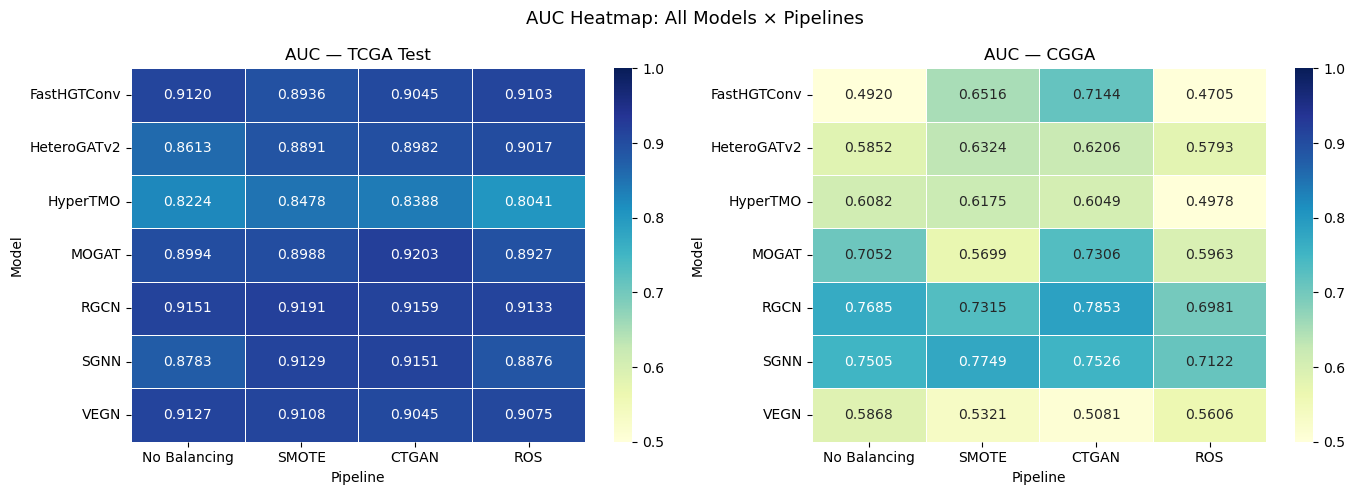

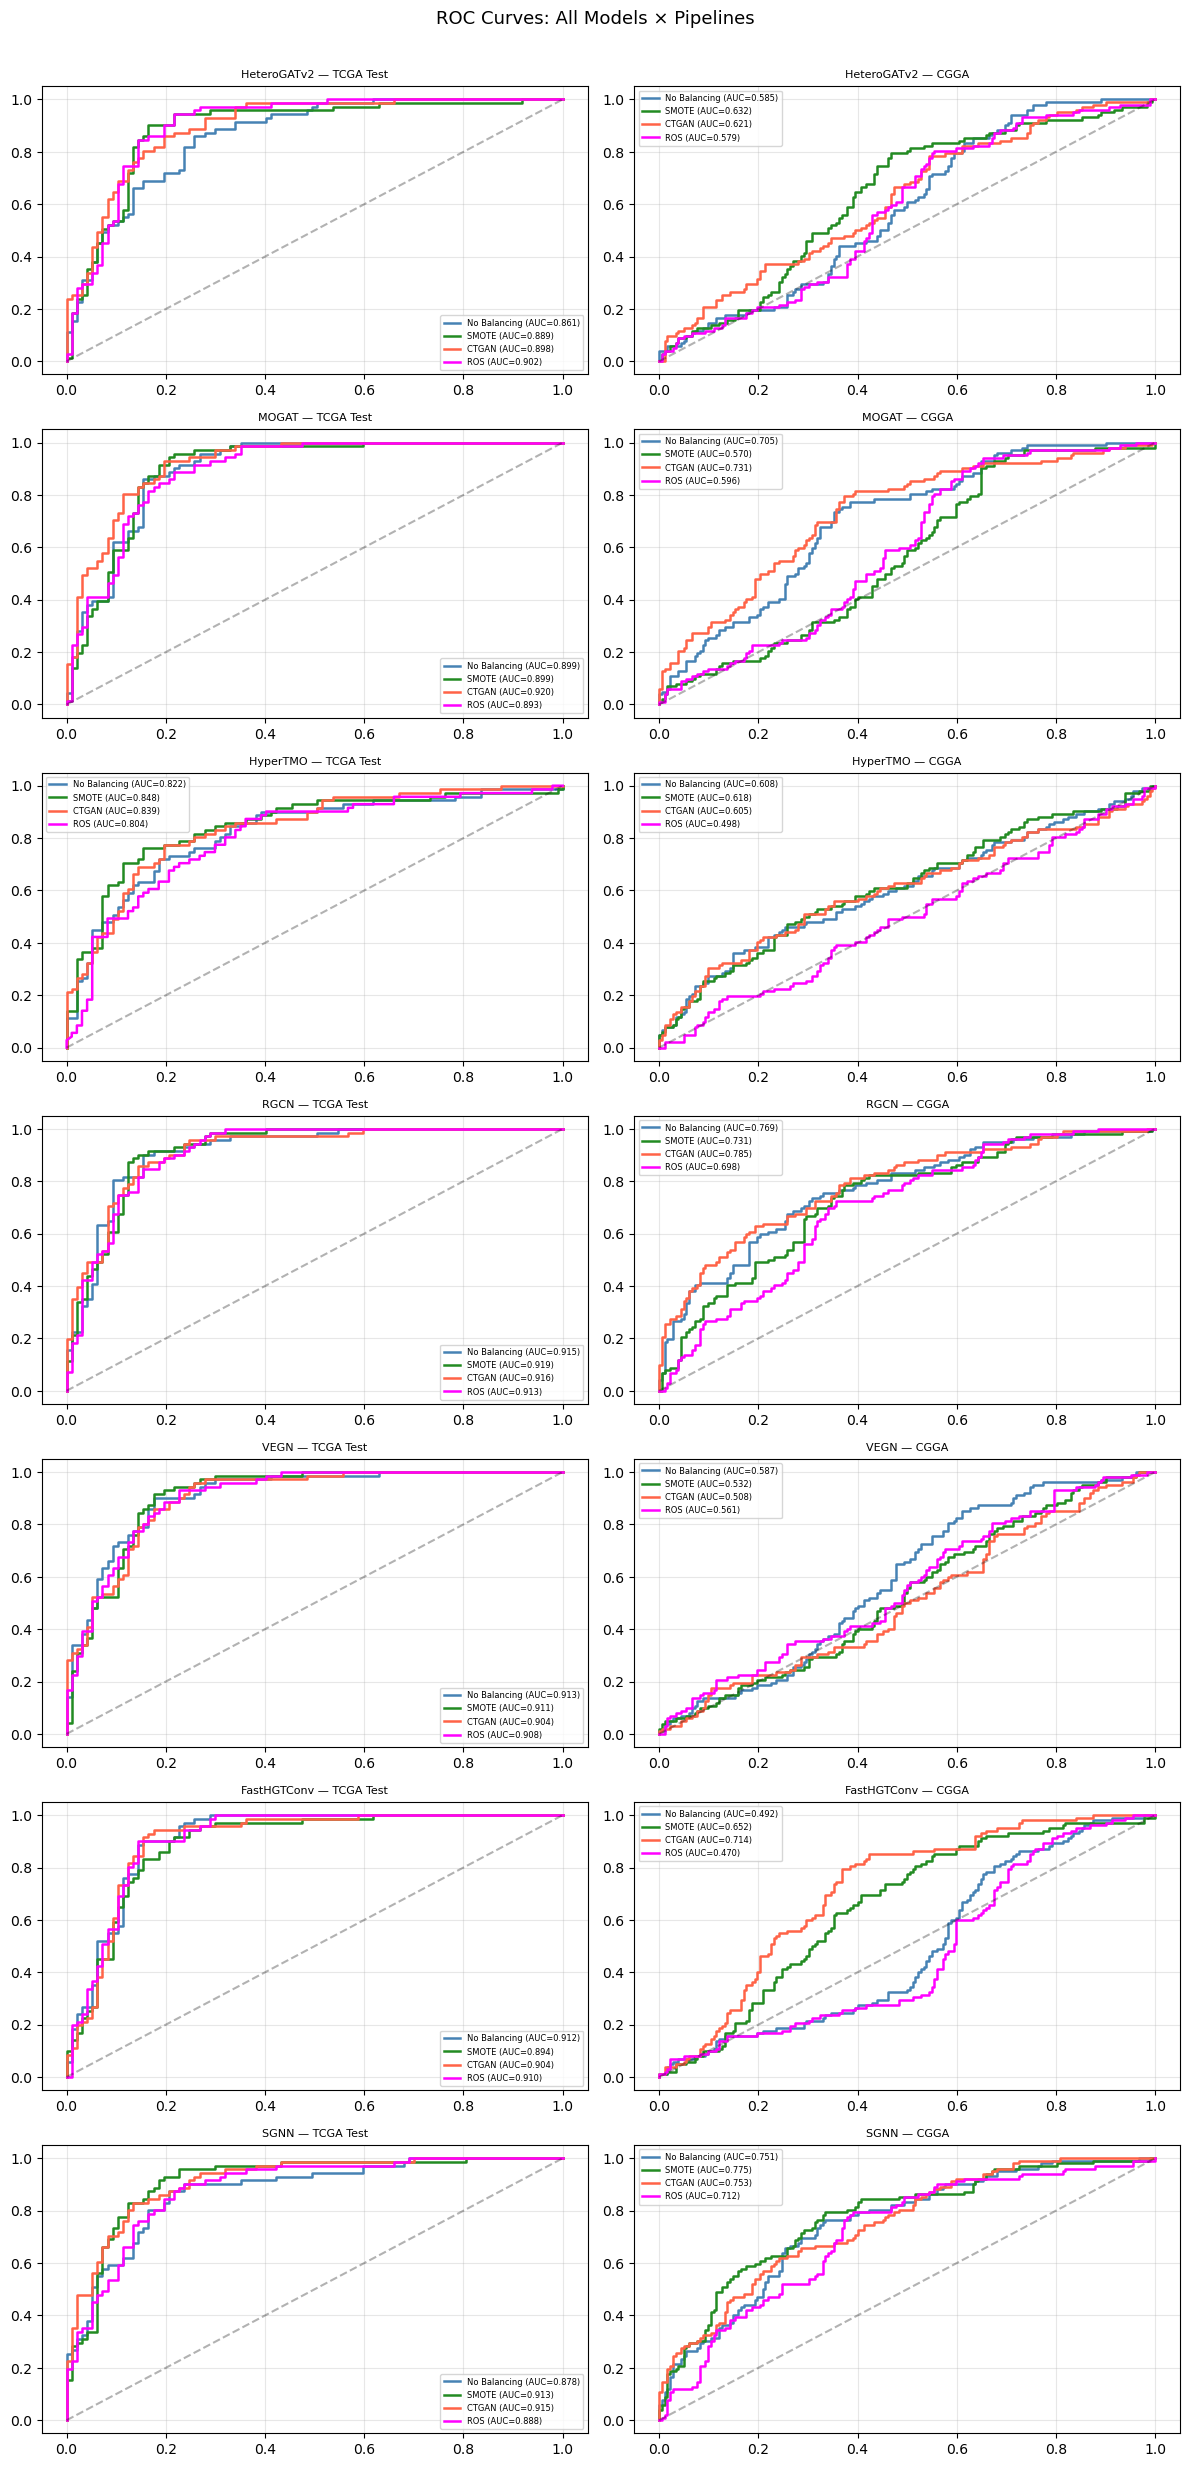

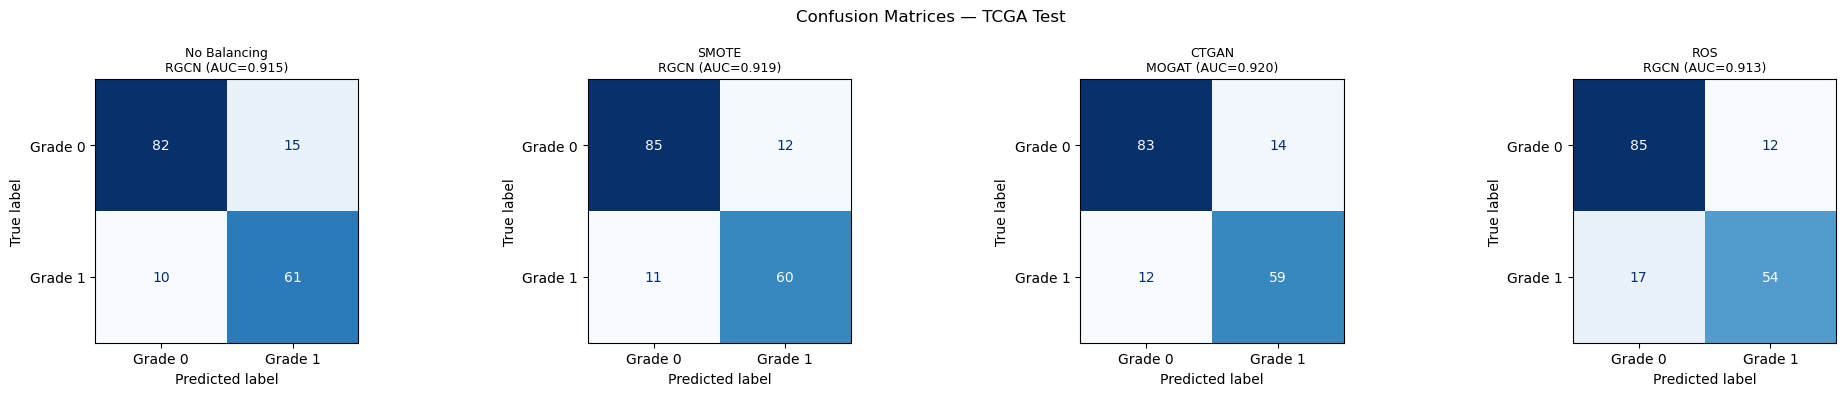

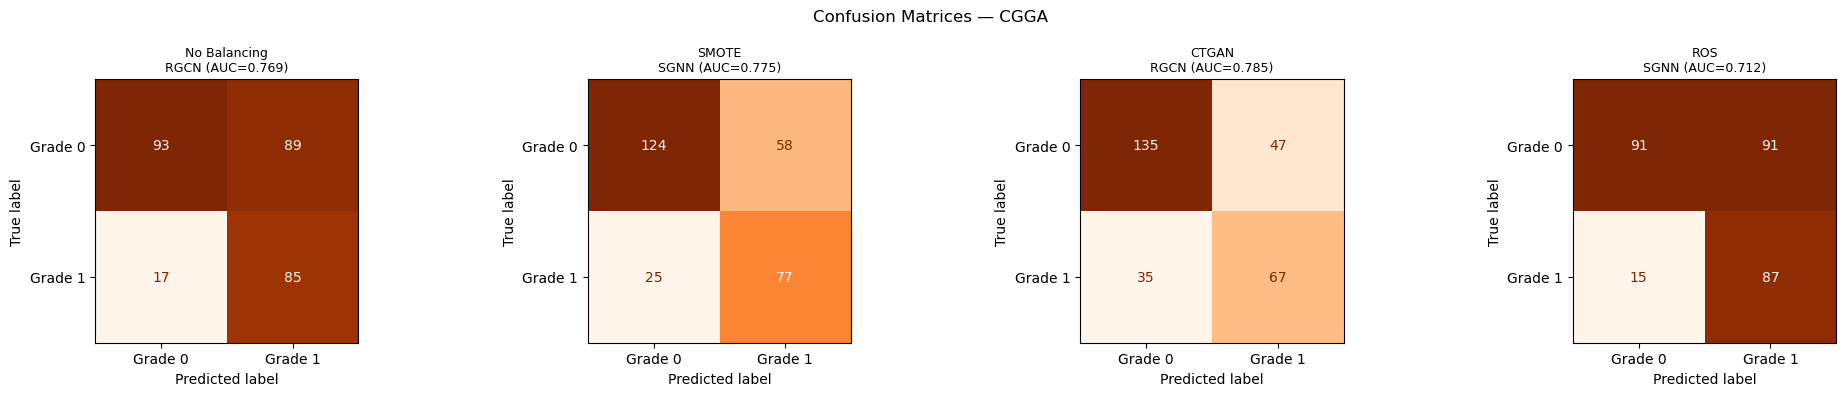

In [18]:
# 18. Heatmaps + ROC + Confusion Matrices
# ============================================================================
results_full = pd.DataFrame(all_results)

# AUC Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ds in zip(axes, ['TCGA Test', 'CGGA']):
    pivot = (results_df[results_df.Dataset == ds]
             .pivot_table(index='Model', columns='Pipeline', values='AUC', aggfunc='mean')
             .reindex(columns=PIPELINES))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu',
                linewidths=0.5, ax=ax, vmin=0.5, vmax=1.0)
    ax.set_title(f'AUC — {ds}')
plt.suptitle('AUC Heatmap: All Models × Pipelines', fontsize=13)
plt.tight_layout(); plt.savefig('auc_heatmap.png', dpi=300, bbox_inches='tight'); plt.show()

# ROC Curves
model_names = [n for n, _, _ in MODEL_REGISTRY]
pipe_colors = {'No Balancing':'steelblue','SMOTE':'forestgreen','CTGAN':'tomato','ROS':'magenta'}

fig, axes = plt.subplots(len(model_names), 2, figsize=(12, 3.5*len(model_names)))
for row, mname in enumerate(model_names):
    for col, ds in enumerate(['TCGA Test', 'CGGA']):
        ax = axes[row, col]
        for pipe in PIPELINES:
            sub = results_full[(results_full.Model==mname) &
                                (results_full.Pipeline==pipe) &
                                (results_full.Dataset==ds)]
            if sub.empty: continue
            r = sub.iloc[0]
            fpr, tpr, _ = roc_curve(r['labels'], r['probs'])
            ax.plot(fpr, tpr, color=pipe_colors[pipe], lw=1.8,
                    label=f"{pipe} (AUC={r['auc']:.3f})")
        ax.plot([0,1],[0,1],'k--', alpha=0.3)
        ax.set_title(f"{mname} — {ds}", fontsize=8)
        ax.legend(fontsize=6); ax.grid(alpha=0.3)
plt.suptitle('ROC Curves: All Models × Pipelines', fontsize=13, y=1.005)
plt.tight_layout(); plt.savefig('roc_grid.png', dpi=300, bbox_inches='tight'); plt.show()

# Confusion Matrices
for ds in ['TCGA Test', 'CGGA']:
    fig, axes = plt.subplots(1, len(PIPELINES), figsize=(5*len(PIPELINES), 4))
    cmap = 'Blues' if ds == 'TCGA Test' else 'Oranges'
    for pi, pipe in enumerate(PIPELINES):
        sub  = results_full[(results_full.Dataset==ds) & (results_full.Pipeline==pipe)]
        if sub.empty: continue
        best = sub.loc[sub['auc'].idxmax()]
        th   = best['threshold']
        preds = (best['probs'] >= th).astype(int)
        cm    = confusion_matrix(best['labels'], preds)
        ConfusionMatrixDisplay(cm, display_labels=['Grade 0','Grade 1']).plot(
            ax=axes[pi], cmap=cmap, colorbar=False)
        axes[pi].set_title(f"{pipe}\n{best['Model']} (AUC={best['auc']:.3f})", fontsize=9)
    plt.suptitle(f'Confusion Matrices — {ds}', fontsize=12)
    plt.tight_layout(); plt.savefig(f'cm_{ds.replace(" ","_")}.png', dpi=300, bbox_inches='tight'); plt.show()

In [19]:
# 19. XAI Helpers
# ============================================================================
CLINICAL_FEAT_NAMES = ['Gender','Race_White','Race_Black','Race_Asian','Race_NativeAm','Age_norm']


def edge_occlusion_attribution(model, graph, patient_idx):
    model.eval()
    cpu_ei = graph[('Gene','mutates','Patient')].edge_index.cpu()
    with torch.no_grad():
        base_prob = F.softmax(model(graph), 1)[patient_idx, 1].item()
    pat_edge_idxs = (cpu_ei[1] == patient_idx).nonzero(as_tuple=True)[0].tolist()
    if not pat_edge_idxs:
        return {}, base_prob
    importances = {}
    orig_g2p = graph[('Gene','mutates','Patient')].edge_index
    has_p2g  = ('Patient','mutated_by','Gene') in graph.edge_index_dict
    if has_p2g:
        orig_p2g = graph[('Patient','mutated_by','Gene')].edge_index
        cpu_p2g  = orig_p2g.cpu()
    for e_idx in pat_edge_idxs:
        gene_idx  = int(cpu_ei[0, e_idx])
        gene_name = gene_columns[gene_idx] if gene_idx < len(gene_columns) else f'G{gene_idx}'
        keep_g2p = torch.ones(cpu_ei.shape[1], dtype=torch.bool)
        keep_g2p[e_idx] = False
        graph[('Gene','mutates','Patient')].edge_index = orig_g2p[:, keep_g2p].to(device)
        if has_p2g:
            keep_p2g = ~((cpu_p2g[0] == patient_idx) & (cpu_p2g[1] == gene_idx))
            graph[('Patient','mutated_by','Gene')].edge_index = orig_p2g[:, keep_p2g].to(device)
        with torch.no_grad():
            try:    mod_prob = F.softmax(model(graph), 1)[patient_idx, 1].item()
            except: mod_prob = base_prob
        graph[('Gene','mutates','Patient')].edge_index = orig_g2p
        if has_p2g:
            graph[('Patient','mutated_by','Gene')].edge_index = orig_p2g
        importances[gene_name] = round(base_prob - mod_prob, 6)
    return importances, base_prob


def integrated_gradients_clinical(model, graph, patient_idx, n_steps=50):
    model.eval()
    x_orig = graph['Patient'].x.detach()
    x_act  = x_orig[patient_idx]
    label  = int(graph['Patient'].y[patient_idx])
    acc_g  = torch.zeros(x_act.shape[0], device=device)
    for step in range(n_steps):
        alpha = step / max(n_steps - 1, 1)
        x_mod = x_orig.clone()
        x_mod[patient_idx] = alpha * x_act
        x_mod.requires_grad_(True)
        old_x = graph['Patient'].x
        graph['Patient'].x = x_mod
        score = F.softmax(model(graph), 1)[patient_idx, label]
        score.backward()
        graph['Patient'].x = old_x
        if x_mod.grad is not None:
            acc_g += x_mod.grad[patient_idx].detach()
    return (x_act * acc_g / n_steps).cpu().numpy()


def _extract_attn(model, graph):
    model.eval()
    with torch.no_grad():
        eidx, alpha = model.get_attn_weights(graph)
    return eidx[0].cpu().numpy(), eidx[1].cpu().numpy(), alpha.cpu().numpy()


def _build_attn_matrix(gene_ids, pat_ids, weights, n_genes, n_pat):
    mat = np.zeros((n_genes, n_pat))
    for g, p, w in zip(gene_ids, pat_ids, weights):
        if 0 <= g < n_genes and 0 <= p < n_pat:
            mat[g, p] = w
    return mat


def _gene_entropy(mat, eps=1e-9):
    out = []
    for row in mat:
        p = row + eps; p /= p.sum()
        out.append(float(-np.sum(p * np.log2(p))))
    return np.array(out)


def _has_attn(model):
    return hasattr(model, 'get_attn_weights') and hasattr(model, 'get_all_heads_attn')

def _is_mogat(model):
    return isinstance(model, MOGAT)

def _is_hgat(model):
    return isinstance(model, HeteroGATv2)

  TCGA best: MOGAT/CTGAN  AUC=0.9203
  CGGA best: RGCN/CTGAN  AUC=0.7853

Edge Occlusion — MOGAT/CTGAN on TCGA Test (168 patients)
  Top-5: ['IDH1', 'IDH2', 'NF1', 'GRIN2A', 'PTEN']


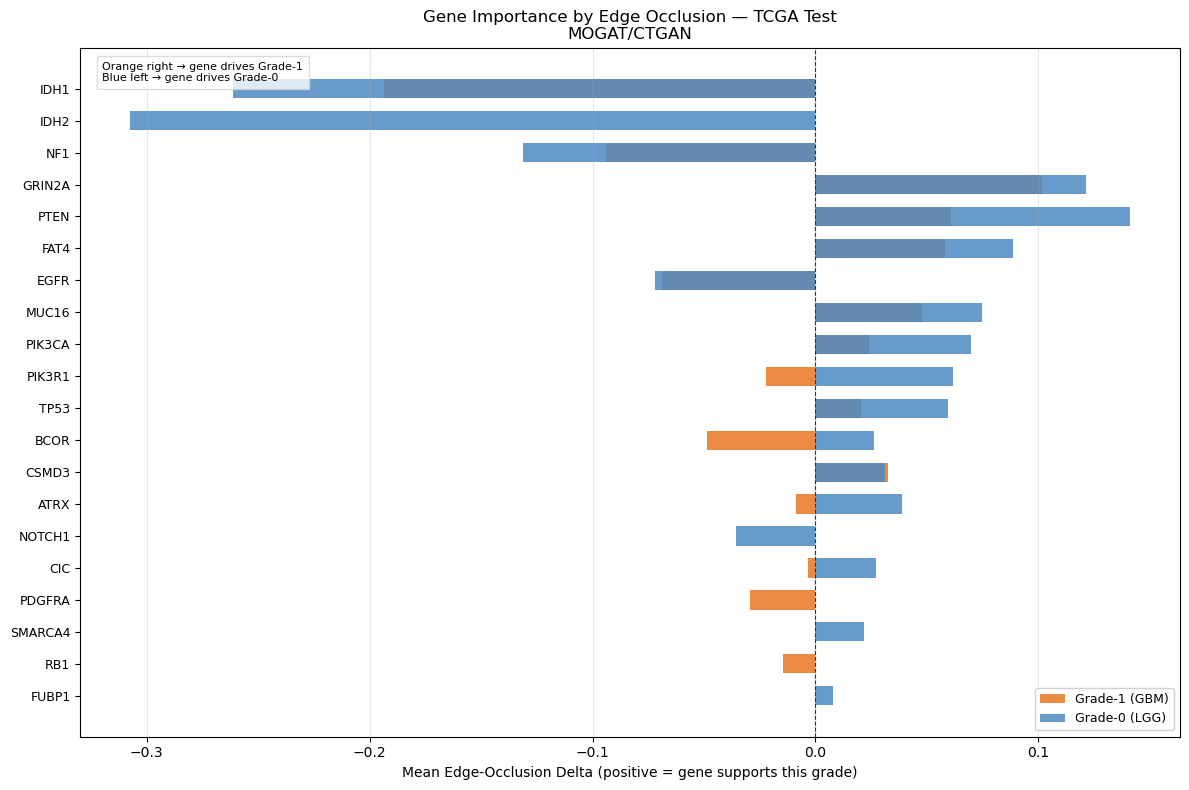


Edge Occlusion — RGCN/CTGAN on CGGA (284 patients)
  Top-5: ['IDH1', 'RB1', 'EGFR', 'GRIN2A', 'MUC16']


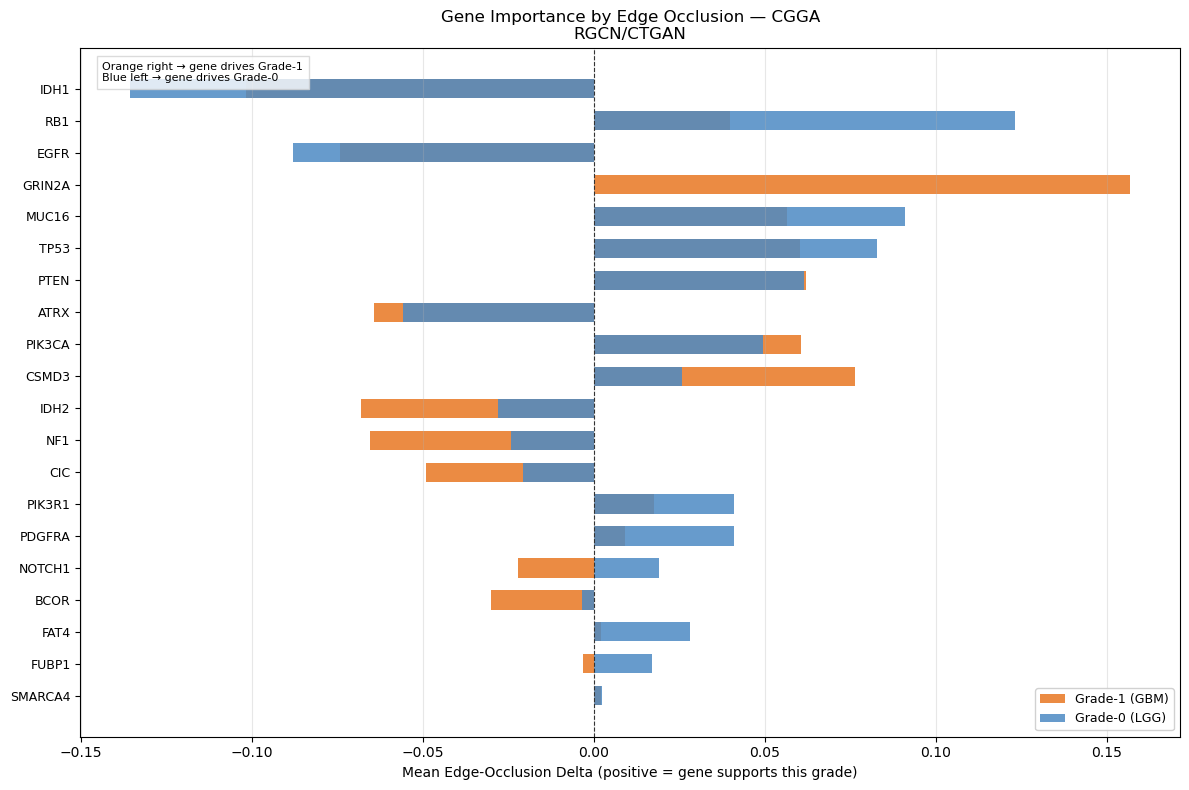


Integrated Gradients — MOGAT/CTGAN on TCGA Test
  Top-5: [{'feature': 'IDH2', 'importance': 0.30740525}, {'feature': 'IDH1', 'importance': 0.2581210493827161}, {'feature': 'NF1', 'importance': 0.11896923076923077}, {'feature': 'GRIN2A', 'importance': 0.10428914285714284}, {'feature': 'PTEN', 'importance': 0.07701182142857144}]


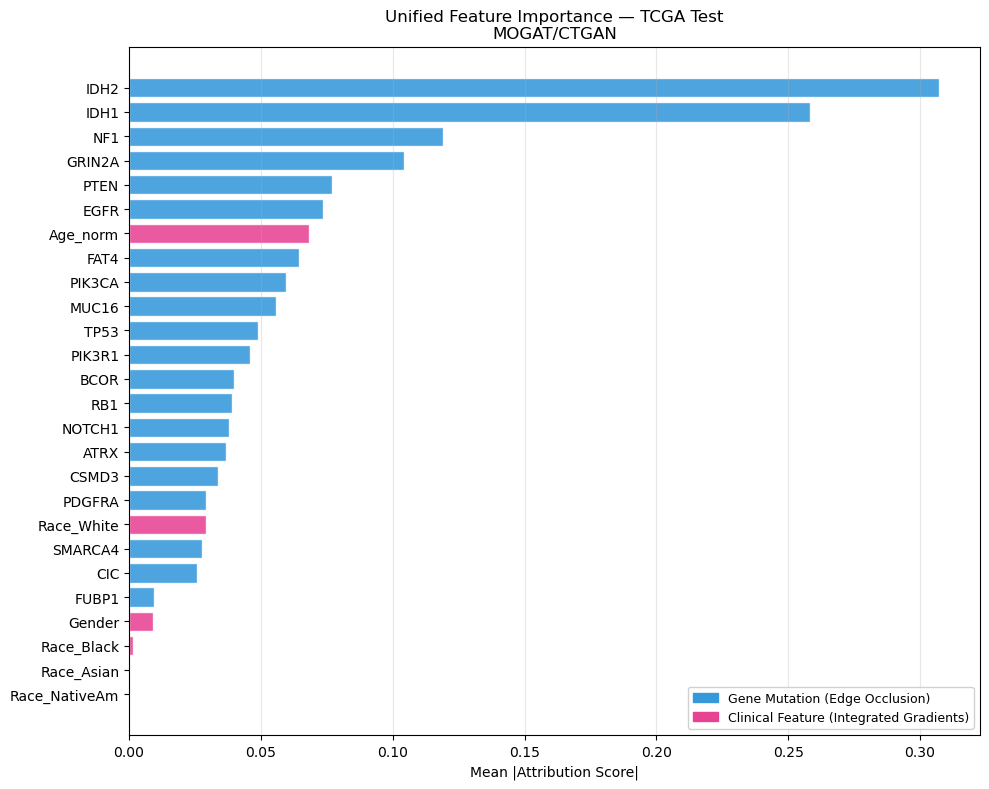


Integrated Gradients — RGCN/CTGAN on CGGA
  Top-5: [{'feature': 'GRIN2A', 'importance': 0.156866}, {'feature': 'IDH1', 'importance': 0.12985745864661655}, {'feature': 'EGFR', 'importance': 0.08319227272727273}, {'feature': 'MUC16', 'importance': 0.07963961904761906}, {'feature': 'TP53', 'importance': 0.07452716279069767}]


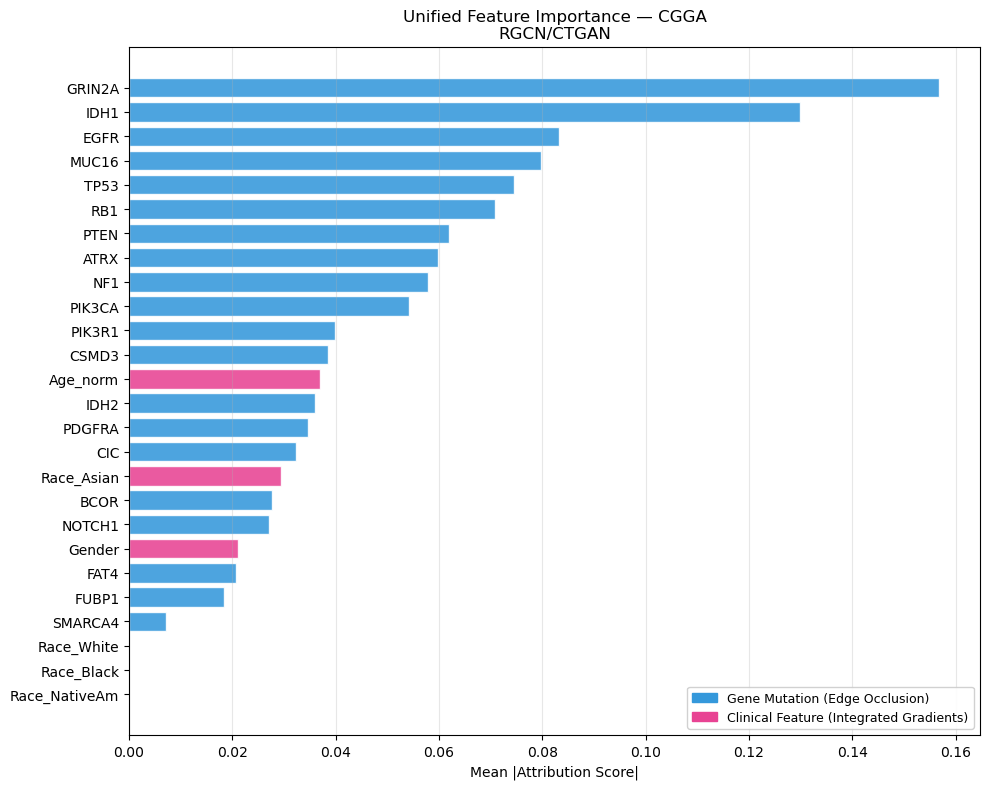


Grade-Stratified Attention — MOGAT/CTGAN/TCGA Test


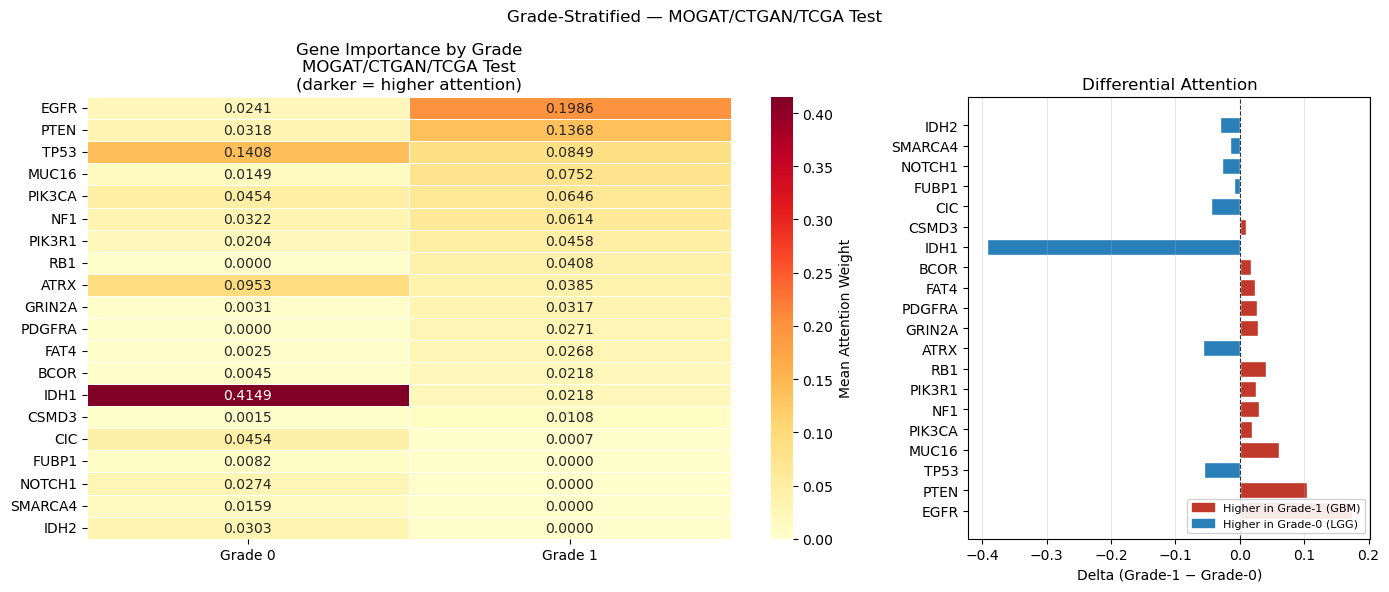


Grade-Stratified Occlusion (fallback) — RGCN/CTGAN/CGGA


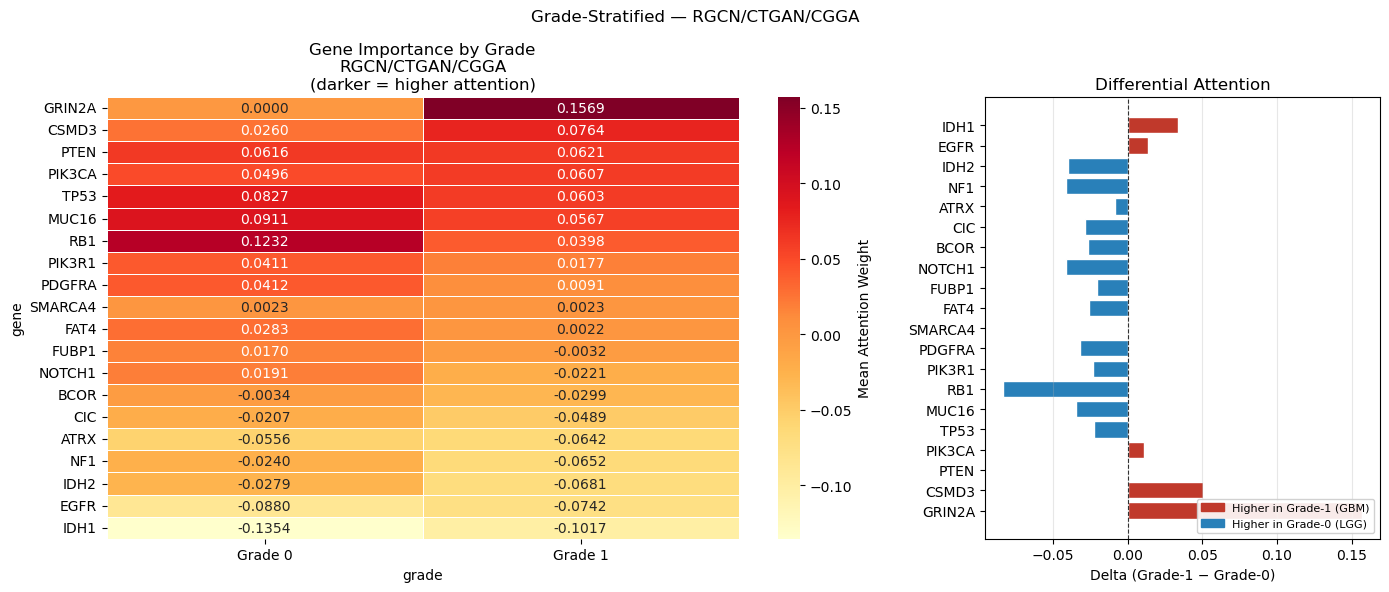


Attention Entropy — MOGAT/CTGAN/TCGA Test


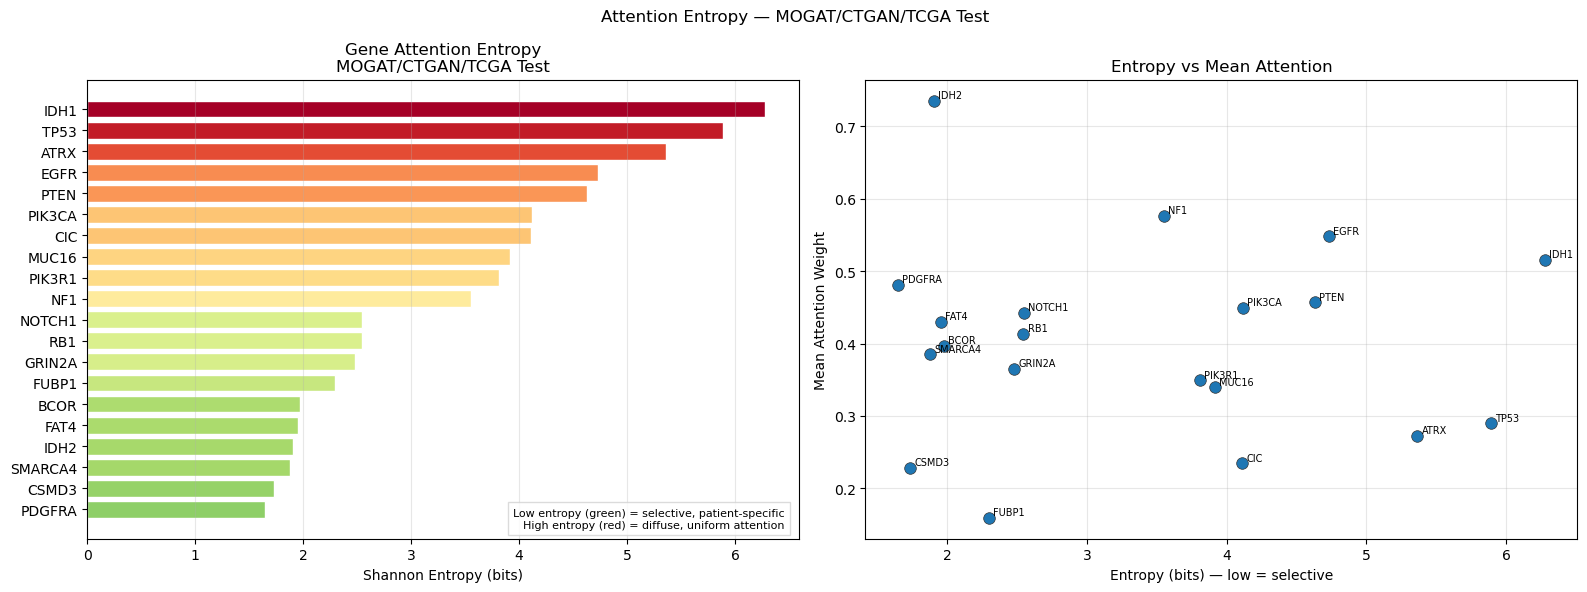


  RGCN/CTGAN/CGGA: no attention — skipping entropy

Consensus — MOGAT on TCGA Test


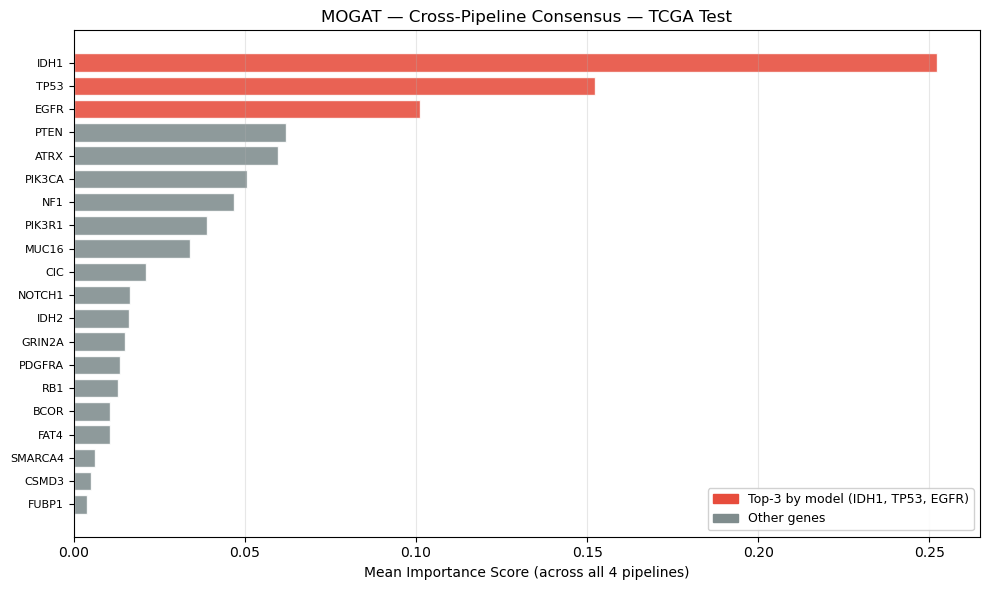


Consensus — MOGAT on CGGA


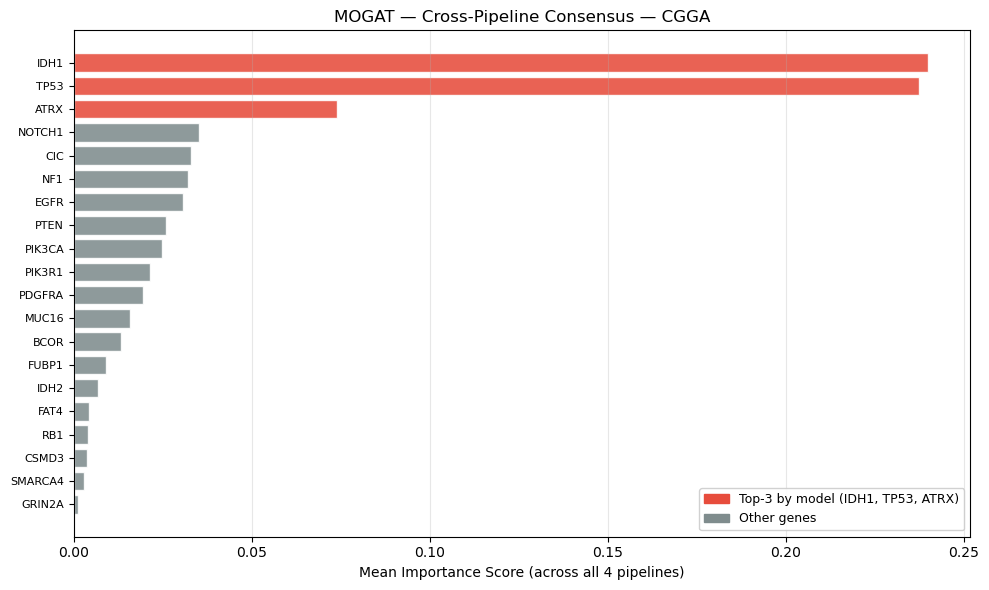


Consensus — RGCN on TCGA Test


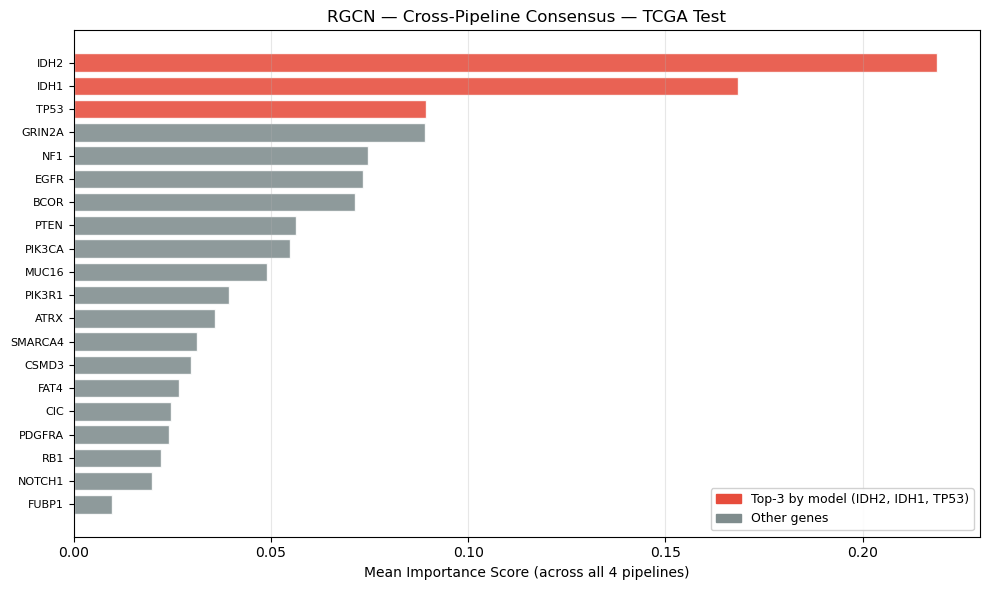


Consensus — RGCN on CGGA


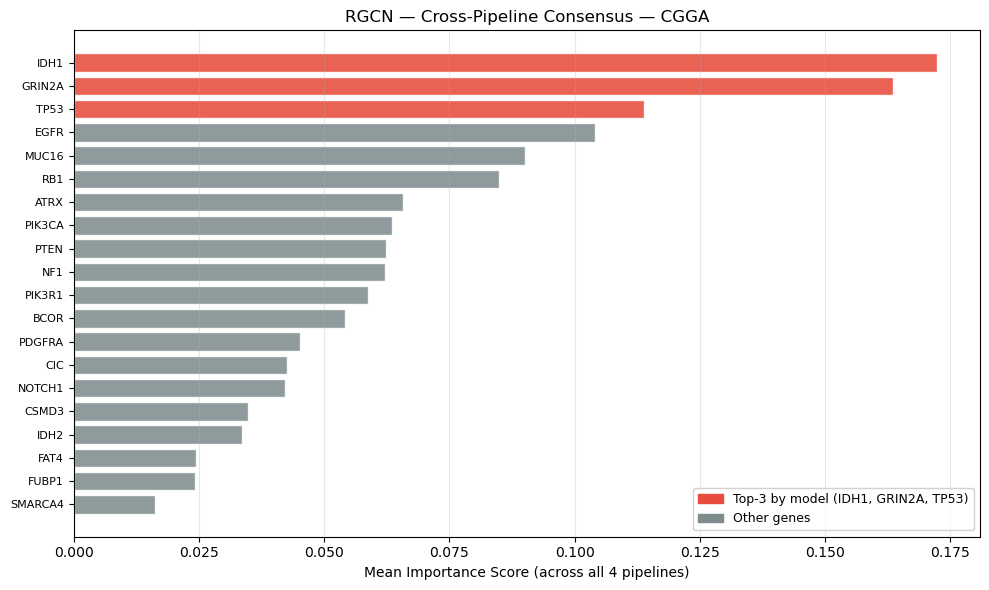

In [29]:
# 20. XAI — Auto Best Model Selection + Run All Methods
# ============================================================================
_rf = pd.DataFrame([
    {'Model': r['Model'], 'Pipeline': r['Pipeline'],
     'auc': r['auc'], 'Dataset': r['Dataset']}
    for r in all_results
])

_best_tcga = _rf[_rf.Dataset == 'TCGA Test'].sort_values('auc', ascending=False).iloc[0]
XAI_MODEL_TCGA    = _best_tcga['Model']
XAI_PIPELINE_TCGA = _best_tcga['Pipeline']
xai_model_tcga    = all_models[(XAI_MODEL_TCGA, XAI_PIPELINE_TCGA)]

_best_cgga = _rf[_rf.Dataset == 'CGGA'].sort_values('auc', ascending=False).iloc[0]
XAI_MODEL_CGGA    = _best_cgga['Model']
XAI_PIPELINE_CGGA = _best_cgga['Pipeline']
xai_model_cgga    = all_models[(XAI_MODEL_CGGA, XAI_PIPELINE_CGGA)]

_same_model = (XAI_MODEL_TCGA == XAI_MODEL_CGGA and XAI_PIPELINE_TCGA == XAI_PIPELINE_CGGA)

XAI_TARGETS = [(XAI_MODEL_TCGA, XAI_PIPELINE_TCGA, xai_model_tcga,
                float(all_thresholds.get((XAI_MODEL_TCGA, XAI_PIPELINE_TCGA), 0.5)),
                test_graph, test_df, 'TCGA Test')]
if not _same_model:
    XAI_TARGETS.append((XAI_MODEL_CGGA, XAI_PIPELINE_CGGA, xai_model_cgga,
                         float(all_thresholds.get((XAI_MODEL_CGGA, XAI_PIPELINE_CGGA), 0.5)),
                         cgga_graph, cgga_df, 'CGGA'))

print("=" * 70)
print(f"  TCGA best: {XAI_MODEL_TCGA}/{XAI_PIPELINE_TCGA}  AUC={_best_tcga['auc']:.4f}")
print(f"  CGGA best: {XAI_MODEL_CGGA}/{XAI_PIPELINE_CGGA}  AUC={_best_cgga['auc']:.4f}")
print("=" * 70)


# ── XAI Method 1: Edge Occlusion ────────────────────────────────────────────
def full_population_attribution(model, graph, df_ref):
    model.eval()
    labels = graph['Patient'].y.cpu().numpy()
    records = []
    for pidx in range(len(labels)):
        imp, base_prob = edge_occlusion_attribution(model, graph, int(pidx))
        mut_genes = [g for g in gene_columns if df_ref.iloc[pidx][g] == 1] if df_ref is not None else []
        for gname, delta in imp.items():
            records.append({'patient_idx': int(pidx), 'gene': gname,
                            'delta_prob': delta, 'grade': int(labels[pidx]),
                            'base_prob': base_prob, 'mutated': gname in mut_genes})
    return pd.DataFrame(records)


xai_occlusion_results = {}
for mname, pipe, model, threshold, primary_graph, primary_df, ds_label in XAI_TARGETS:
    print(f"\nEdge Occlusion — {mname}/{pipe} on {ds_label} ({primary_graph['Patient'].x.shape[0]} patients)")
    full_attr = full_population_attribution(model, primary_graph, primary_df)
    agg = (full_attr.groupby(['gene','grade'])['delta_prob']
           .mean().unstack('grade').fillna(0)
           .rename(columns={0:'Grade0_imp', 1:'Grade1_imp'}))
    agg['overall'] = (agg['Grade0_imp'].abs() + agg['Grade1_imp'].abs()) / 2
    agg['discriminability'] = agg['Grade1_imp'] - agg['Grade0_imp']
    agg = agg.sort_values('overall', ascending=False)
    xai_occlusion_results[ds_label] = (full_attr, agg)
    print(f"  Top-5: {agg['overall'].nlargest(5).index.tolist()}")

    safe = f"{mname}_{pipe}_{ds_label}".replace(' ','_').replace('/','_')
    genes_sorted = agg.sort_values('overall', ascending=True).index.tolist()
    fig, ax = plt.subplots(figsize=(12, 8))
    y = np.arange(len(genes_sorted))
    ax.barh(y, [agg.loc[g,'Grade1_imp'] for g in genes_sorted], color='#E87722', alpha=0.85, label='Grade-1 (GBM)', height=0.6)
    ax.barh(y, [agg.loc[g,'Grade0_imp'] for g in genes_sorted], color='#4C8AC4', alpha=0.85, label='Grade-0 (LGG)', height=0.6)
    ax.set_yticks(y); ax.set_yticklabels(genes_sorted, fontsize=9)
    ax.axvline(0, color='#333', lw=0.8, ls='--')
    ax.set_xlabel('Mean Edge-Occlusion Delta (positive = gene supports this grade)')
    ax.set_title(f'Gene Importance by Edge Occlusion — {ds_label}\n{mname}/{pipe}')
    ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
    ax.grid(axis='x', alpha=0.3)
    ax.text(0.02, 0.98, 'Orange right → gene drives Grade-1\nBlue left → gene drives Grade-0',
            transform=ax.transAxes, fontsize=8, va='top', ha='left',
            bbox=dict(fc='white', alpha=0.8, ec='lightgray'))
    plt.tight_layout(); plt.savefig(f'xai_occlusion_{safe}.png', dpi=300, bbox_inches='tight'); plt.show()


# ── XAI Method 2: Integrated Gradients ──────────────────────────────────────
xai_ig_results = {}
for mname, pipe, model, threshold, primary_graph, primary_df, ds_label in XAI_TARGETS:
    print(f"\nIntegrated Gradients — {mname}/{pipe} on {ds_label}")
    model.eval()
    labels = primary_graph['Patient'].y.cpu().numpy()
    rng = np.random.default_rng(42)
    idx0 = np.where(labels == 0)[0]; idx1 = np.where(labels == 1)[0]
    half = min(30, len(idx0), len(idx1))
    sel  = np.concatenate([rng.choice(idx0, half, replace=False), rng.choice(idx1, half, replace=False)])
    records = []
    for pidx in sel:
        ig  = integrated_gradients_clinical(model, primary_graph, int(pidx), n_steps=30)
        row = {'patient_idx': int(pidx), 'grade': int(labels[pidx])}
        for fname, val in zip(CLINICAL_FEAT_NAMES, ig):
            row[fname] = float(val)
        records.append(row)
    clin_df = pd.DataFrame(records)
    overall_clin = clin_df[CLINICAL_FEAT_NAMES].abs().mean().sort_values(ascending=False)

    if ds_label in xai_occlusion_results:
        gene_imp = (xai_occlusion_results[ds_label][0]
                    .groupby('gene')['delta_prob']
                    .apply(lambda x: x.abs().mean())
                    .sort_values(ascending=False))
    else:
        gene_imp = pd.Series(dtype=float)

    unified = pd.concat([
        gene_imp.rename('importance').reset_index().rename(columns={'gene':'feature'}),
        pd.DataFrame({'feature': overall_clin.index, 'importance': overall_clin.values})
    ]).sort_values('importance', ascending=False).reset_index(drop=True)
    unified['type'] = unified['feature'].apply(
        lambda f: 'Clinical' if f in CLINICAL_FEAT_NAMES else 'Gene Mutation')
    xai_ig_results[ds_label] = (clin_df, unified)
    print(f"  Top-5: {unified.head(5)[['feature','importance']].to_dict('records')}")

    safe = f"{mname}_{pipe}_{ds_label}".replace(' ','_').replace('/','_')
    fig, ax = plt.subplots(figsize=(10, 8))
    colors_u = ['#e84393' if t == 'Clinical' else '#3498db' for t in unified['type']]
    ax.barh(unified['feature'][::-1], unified['importance'][::-1],
            color=colors_u[::-1], edgecolor='white', alpha=0.88)
    ax.set_xlabel('Mean |Attribution Score|')
    ax.set_title(f'Unified Feature Importance — {ds_label}\n{mname}/{pipe}')
    ax.grid(axis='x', alpha=0.3)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='#3498db', label='Gene Mutation (Edge Occlusion)'),
                       Patch(color='#e84393', label='Clinical Feature (Integrated Gradients)')],
              fontsize=9, loc='lower right', framealpha=0.9)
    plt.tight_layout(); plt.savefig(f'xai_ig_{safe}.png', dpi=300, bbox_inches='tight'); plt.show()


# ── XAI Method 3: Grade-Stratified Attention ────────────────────────────────
xai_grade_results = {}
for mname, pipe, model, threshold, primary_graph, primary_df, ds_label in XAI_TARGETS:
    title = f"{mname}/{pipe}/{ds_label}"
    if _has_attn(model):
        print(f"\nGrade-Stratified Attention — {title}")
        gids, pids, ws = _extract_attn(model, primary_graph)
        labels = primary_graph['Patient'].y.cpu().numpy()
        n_p = primary_graph['Patient'].x.shape[0]
        mat = _build_attn_matrix(gids, pids, ws, NUM_GENES, n_p)
        g0_mean = mat[:, labels == 0].mean(axis=1)
        g1_mean = mat[:, labels == 1].mean(axis=1)
        delta   = g1_mean - g0_mean
        df_h = pd.DataFrame({'Grade 0': g0_mean, 'Grade 1': g1_mean, 'Delta': delta},
                             index=gene_columns).sort_values('Grade 1', ascending=False)
    else:
        print(f"\nGrade-Stratified Occlusion (fallback) — {title}")
        if ds_label in xai_occlusion_results:
            df_h = (xai_occlusion_results[ds_label][0].groupby(['gene','grade'])['delta_prob']
                    .mean().unstack('grade').fillna(0)
                    .rename(columns={0:'Grade 0', 1:'Grade 1'}))
            df_h['Delta'] = df_h['Grade 1'] - df_h['Grade 0']
            df_h = df_h.sort_values('Grade 1', ascending=False)
        else:
            continue
    xai_grade_results[ds_label] = df_h

    safe = title.replace('/','_').replace(' ','_')
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [2, 1]})
    sns.heatmap(df_h[['Grade 0','Grade 1']], annot=True, fmt='.4f', cmap='YlOrRd',
                linewidths=0.4, ax=axes[0], cbar_kws={'label': 'Mean Attention Weight'})
    axes[0].set_title(f'Gene Importance by Grade\n{title}\n(darker = higher attention)')
    dcols = ['#c0392b' if v > 0 else '#2980b9' for v in df_h['Delta']]
    axes[1].barh(df_h.index, df_h['Delta'], color=dcols, edgecolor='white')
    axes[1].axvline(0, color='#333', lw=0.8, ls='--')
    axes[1].set_xlabel('Delta (Grade-1 − Grade-0)')
    axes[1].set_title('Differential Attention')
    axes[1].grid(axis='x', alpha=0.3)
    from matplotlib.patches import Patch
    axes[1].legend(handles=[Patch(color='#c0392b', label='Higher in Grade-1 (GBM)'),
                            Patch(color='#2980b9', label='Higher in Grade-0 (LGG)')],
                   fontsize=8, loc='lower right', framealpha=0.9)
    plt.suptitle(f'Grade-Stratified — {title}')
    plt.tight_layout(); plt.savefig(f'xai_grade_attn_{safe}.png', dpi=300, bbox_inches='tight'); plt.show()


# ── XAI Method 4: Attention Entropy ─────────────────────────────────────────
for mname, pipe, model, threshold, primary_graph, primary_df, ds_label in XAI_TARGETS:
    title = f"{mname}/{pipe}/{ds_label}"
    if not _has_attn(model):
        print(f"\n  {title}: no attention — skipping entropy")
        continue
    print(f"\nAttention Entropy — {title}")
    gids, pids, ws = _extract_attn(model, primary_graph)
    n_p = primary_graph['Patient'].x.shape[0]
    mat = _build_attn_matrix(gids, pids, ws, NUM_GENES, n_p)
    entropies = _gene_entropy(mat)
    means = np.array([row[row > 0].mean() if (row > 0).any() else 0.0 for row in mat])

    safe = title.replace('/','_').replace(' ','_')
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    ent_order = np.argsort(entropies)
    axes[0].barh([gene_columns[i] for i in ent_order], entropies[ent_order],
                  color=plt.cm.RdYlGn_r(entropies[ent_order] / (entropies.max() + 1e-9)),
                  edgecolor='white')
    axes[0].set_xlabel('Shannon Entropy (bits)')
    axes[0].set_title(f'Gene Attention Entropy\n{title}'); axes[0].grid(axis='x', alpha=0.3)
    axes[0].text(0.98, 0.02, 'Low entropy (green) = selective, patient-specific\n'
                              'High entropy (red) = diffuse, uniform attention',
                 transform=axes[0].transAxes, fontsize=8, va='bottom', ha='right',
                 bbox=dict(fc='white', alpha=0.8, ec='lightgray'))

    axes[1].scatter(entropies, means, s=70, edgecolors='#333', linewidths=0.5, zorder=3)
    for i, g in enumerate(gene_columns):
        axes[1].annotate(g, (entropies[i], means[i]), textcoords='offset points', xytext=(3,2), fontsize=7)
    axes[1].set_xlabel('Entropy (bits) — low = selective'); axes[1].set_ylabel('Mean Attention Weight')
    axes[1].set_title(f'Entropy vs Mean Attention'); axes[1].grid(alpha=0.3)
    plt.suptitle(f'Attention Entropy — {title}')
    plt.tight_layout(); plt.savefig(f'xai_entropy_{safe}.png', dpi=300, bbox_inches='tight'); plt.show()


# ── XAI Method 5: Cross-Pipeline Consensus ──────────────────────────────────
xai_consensus_results = {}
_arch_seen = set()
for mname, pipe, model, threshold, primary_graph, primary_df, ds_label in XAI_TARGETS:
    if mname in _arch_seen: continue
    _arch_seen.add(mname)

    for graph_label, graph_obj, ref_df in [('TCGA Test', test_graph, test_df), ('CGGA', cgga_graph, cgga_df)]:
        print(f"\nConsensus — {mname} on {graph_label}")
        pipe_scores = {}
        for p in PIPELINES:
            m = all_models.get((mname, p))
            if m is None: continue
            m.eval()
            if _has_attn(m):
                gids, pids, ws = _extract_attn(m, graph_obj)
                n_p = graph_obj['Patient'].x.shape[0]
                mat = _build_attn_matrix(gids, pids, ws, NUM_GENES, n_p)
                gene_scores = pd.Series(mat.mean(axis=1), index=gene_columns)
            else:
                attr_df = full_population_attribution(m, graph_obj, ref_df)
                gene_scores = (attr_df.groupby('gene')['delta_prob']
                               .apply(lambda x: x.abs().mean())
                               .reindex(gene_columns, fill_value=0))
            pipe_scores[p] = gene_scores

        if not pipe_scores: continue
        consensus_df = pd.DataFrame(pipe_scores).fillna(0)
        consensus_df['mean_score'] = consensus_df.mean(axis=1)
        consensus_df['mean_rank']  = consensus_df[PIPELINES].rank(ascending=False).mean(axis=1)
        consensus_df = consensus_df.sort_values('mean_score', ascending=False)
        xai_consensus_results.setdefault(mname, {})[graph_label] = consensus_df

        safe = f"{mname}_{graph_label}".replace(' ','_')
        fig, ax = plt.subplots(figsize=(10, 6))
        score_s = consensus_df['mean_score'].sort_values(ascending=True)
        # Color by data-driven ranking: top-3 genes from the model's own scores
        top3 = score_s.nlargest(3).index.tolist()
        ax.barh(range(len(score_s)), score_s.values,
                color=['#e74c3c' if g in top3 else '#7f8c8d' for g in score_s.index],
                edgecolor='white', alpha=0.88)
        ax.set_yticks(range(len(score_s))); ax.set_yticklabels(score_s.index, fontsize=8)
        ax.set_xlabel('Mean Importance Score (across all 4 pipelines)')
        ax.set_title(f'{mname} — Cross-Pipeline Consensus — {graph_label}')
        ax.grid(axis='x', alpha=0.3)
        from matplotlib.patches import Patch
        ax.legend(handles=[Patch(color='#e74c3c', label=f'Top-3 by model ({", ".join(top3)})'),
                           Patch(color='#7f8c8d', label='Other genes')],
                  fontsize=9, loc='lower right', framealpha=0.9)
        plt.tight_layout(); plt.savefig(f'xai_consensus_{safe}.png', dpi=300, bbox_inches='tight'); plt.show()

In [30]:
# Section A — Statistical Validation
# ============================================================================

def _structural_components(probs, labels):
    pos = probs[labels == 1]
    neg = probs[labels == 0]
    m, n = len(pos), len(neg)
    V10 = np.array([np.mean((p > neg) + 0.5 * (p == neg)) for p in pos])
    V01 = np.array([np.mean((pos > q) + 0.5 * (pos == q)) for q in neg])
    auc = V10.mean()
    var = (np.var(V10, ddof=1) / m + np.var(V01, ddof=1) / n)
    return auc, var, V10, V01


def delong_test(probs_a, probs_b, labels):
    auc_a, var_a, V10_a, V01_a = _structural_components(probs_a, labels)
    auc_b, var_b, V10_b, V01_b = _structural_components(probs_b, labels)
    m = (labels == 1).sum(); n = (labels == 0).sum()
    cov_10 = np.cov(V10_a, V10_b, ddof=1)[0, 1] / m
    cov_01 = np.cov(V01_a, V01_b, ddof=1)[0, 1] / n
    var_diff = var_a + var_b - 2 * (cov_10 + cov_01)
    if var_diff <= 0: return auc_a, auc_b, 0.0, 1.0
    z = (auc_a - auc_b) / np.sqrt(var_diff)
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return auc_a, auc_b, float(z), float(p)


def _get_result(model_name, pipeline, dataset='TCGA Test'):
    for r in all_results:
        if r['Model'] == model_name and r['Pipeline'] == pipeline and r['Dataset'] == dataset:
            return np.array(r['probs']), np.array(r['labels'])
    return None, None

# ── Auto-derive best model variables ─────────────────────────────────────────
_rf_auto = pd.DataFrame([
    {'Model': r['Model'], 'Pipeline': r['Pipeline'], 'auc': r['auc'], 'Dataset': r['Dataset']}
    for r in all_results
])
_best_tcga_s = _rf_auto[_rf_auto.Dataset == 'TCGA Test'].sort_values('auc', ascending=False).iloc[0]
BEST_MODEL_NAME_TCGA = _best_tcga_s['Model']
BEST_PIPELINE_TCGA   = _best_tcga_s['Pipeline']
BEST_BP_TCGA         = all_params[(BEST_MODEL_NAME_TCGA, BEST_PIPELINE_TCGA)]
BEST_MODEL_CLS_TCGA  = next(cls for n, cls, _ in MODEL_REGISTRY if n == BEST_MODEL_NAME_TCGA)
BEST_FKW_TCGA        = next(fkw for n, _, fkw in MODEL_REGISTRY if n == BEST_MODEL_NAME_TCGA)
BEST_THRESHOLD_TCGA  = float(all_thresholds.get((BEST_MODEL_NAME_TCGA, BEST_PIPELINE_TCGA), 0.5))

_best_cgga_s = _rf_auto[_rf_auto.Dataset == 'CGGA'].sort_values('auc', ascending=False).iloc[0]
BEST_MODEL_NAME_CGGA = _best_cgga_s['Model']
BEST_PIPELINE_CGGA   = _best_cgga_s['Pipeline']
BEST_BP_CGGA         = all_params[(BEST_MODEL_NAME_CGGA, BEST_PIPELINE_CGGA)]
BEST_MODEL_CLS_CGGA  = next(cls for n, cls, _ in MODEL_REGISTRY if n == BEST_MODEL_NAME_CGGA)
BEST_FKW_CGGA        = next(fkw for n, _, fkw in MODEL_REGISTRY if n == BEST_MODEL_NAME_CGGA)
BEST_THRESHOLD_CGGA  = float(all_thresholds.get((BEST_MODEL_NAME_CGGA, BEST_PIPELINE_CGGA), 0.5))

print(f"Best TCGA: {BEST_MODEL_NAME_TCGA}/{BEST_PIPELINE_TCGA}")
print(f"Best CGGA: {BEST_MODEL_NAME_CGGA}/{BEST_PIPELINE_CGGA}")

# ── A.1 DeLong: best vs second-best ─────────────────────────────────────────
pb_best, lb_best = _get_result(BEST_MODEL_NAME_TCGA, BEST_PIPELINE_TCGA)
_second = (_rf_auto[(_rf_auto.Dataset == 'TCGA Test') &
                    ~((_rf_auto.Model == BEST_MODEL_NAME_TCGA) & (_rf_auto.Pipeline == BEST_PIPELINE_TCGA))]
           .sort_values('auc', ascending=False).iloc[0])
pb_second, _ = _get_result(_second['Model'], _second['Pipeline'])
if pb_best is not None and pb_second is not None:
    auc_a, auc_b, z, p = delong_test(pb_best, pb_second, lb_best)
    print(f"\nDeLong: {BEST_MODEL_NAME_TCGA} AUC={auc_a:.4f} vs {_second['Model']} AUC={auc_b:.4f}")
    print(f"  Z={z:.3f}, p={p:.4f} {'*significant*' if p < 0.05 else 'ns'}")

# ── A.2 Bootstrap CIs ───────────────────────────────────────────────────────
def bootstrap_ci(probs, labels, preds, n_boot=10_000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    metrics_boot = {m: [] for m in ['auc', 'f1', 'recall_1', 'recall_0']}
    idx0, idx1 = np.where(labels == 0)[0], np.where(labels == 1)[0]
    for _ in range(n_boot):
        b = np.concatenate([rng.choice(idx0, len(idx0), replace=True),
                            rng.choice(idx1, len(idx1), replace=True)])
        lb, pb, pd_b = labels[b], probs[b], preds[b]
        try:    metrics_boot['auc'].append(roc_auc_score(lb, pb))
        except: metrics_boot['auc'].append(np.nan)
        metrics_boot['f1'].append(f1_score(lb, pd_b, zero_division=0))
        metrics_boot['recall_1'].append(recall_score(lb, pd_b, pos_label=1, zero_division=0))
        metrics_boot['recall_0'].append(recall_score(lb, pd_b, pos_label=0, zero_division=0))
    out = {}
    lo, hi = alpha / 2, 1 - alpha / 2
    for m, vals in metrics_boot.items():
        v = np.array(vals); v = v[~np.isnan(v)]
        out[m] = (float(np.percentile(v, lo*100)), float(np.percentile(v, hi*100)))
    return out

print("\nBootstrap 95% CIs (n=10000)...")
ci_records = []
_ci_targets = {(BEST_MODEL_NAME_TCGA, BEST_PIPELINE_TCGA, 'TCGA Test'),
               (BEST_MODEL_NAME_TCGA, BEST_PIPELINE_TCGA, 'CGGA'),
               (BEST_MODEL_NAME_CGGA, BEST_PIPELINE_CGGA, 'TCGA Test'),
               (BEST_MODEL_NAME_CGGA, BEST_PIPELINE_CGGA, 'CGGA')}
for mname, pipe, dataset in sorted(_ci_targets):
    pb, lb = _get_result(mname, pipe, dataset)
    if pb is None: continue
    th  = all_thresholds.get((mname, pipe), 0.5)
    pd_ = (pb >= th).astype(int)
    ci  = bootstrap_ci(pb, lb, pd_, n_boot=10_000)
    for metric, (lo, hi) in ci.items():
        ci_records.append({'Model': mname, 'Pipeline': pipe, 'Dataset': dataset,
                           'Metric': metric, 'Lower': lo, 'Upper': hi})
ci_df = pd.DataFrame(ci_records)
print(ci_df.to_string(index=False))
ci_df.to_csv('bootstrap_ci.csv', index=False)

# ── A.3 McNemar tests ───────────────────────────────────────────────────────
def mcnemar_test(preds_a, preds_b, labels):
    correct_a = (preds_a == labels); correct_b = (preds_b == labels)
    b = ((correct_a) & (~correct_b)).sum()
    c = ((~correct_a) & (correct_b)).sum()
    if b + c == 0: return b, c, 0.0, 1.0, 'degenerate'
    if b + c <= 25:
        p = 2 * stats.binom.sf(max(b, c) - 1, b + c, 0.5)
        return b, c, float(max(b, c)), float(min(p, 1.0)), 'exact_binomial'
    stat = (abs(b - c) - 1) ** 2 / (b + c)
    p = stats.chi2.sf(stat, df=1)
    return b, c, float(stat), float(p), 'chi2_corrected'

print("\nMcNemar pairwise — CTGAN pipeline, TCGA Test")
ctgan_models = []
seen_ = set()
for r in all_results:
    if r['Pipeline'] == 'CTGAN' and r['Dataset'] == 'TCGA Test' and r['Model'] not in seen_:
        seen_.add(r['Model'])
        ctgan_models.append((r['Model'], r['Pipeline'], np.array(r['probs']), np.array(r['labels'])))

mcn_records = []
for i, (mn_a, pp_a, pb_a, lb_a) in enumerate(ctgan_models):
    th_a = all_thresholds.get((mn_a, pp_a), 0.5)
    pd_a = (pb_a >= th_a).astype(int)
    for j, (mn_b, pp_b, pb_b, lb_b) in enumerate(ctgan_models):
        if j <= i: continue
        th_b = all_thresholds.get((mn_b, pp_b), 0.5)
        pd_b = (pb_b >= th_b).astype(int)
        b, c, stat, p, method = mcnemar_test(pd_a, pd_b, lb_a)
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f"  {mn_a:14s} vs {mn_b:14s}: b={b:3d} c={c:3d} p={p:.4f} {sig}")
        mcn_records.append({'ModelA': mn_a, 'ModelB': mn_b, 'b': b, 'c': c,
                             'stat': stat, 'p': p, 'sig': sig})
pd.DataFrame(mcn_records).to_csv('mcnemar.csv', index=False)

Best TCGA: MOGAT/CTGAN
Best CGGA: RGCN/CTGAN

DeLong: MOGAT AUC=0.9203 vs RGCN AUC=0.9191
  Z=0.122, p=0.9033 ns

Bootstrap 95% CIs (n=10000)...
Model Pipeline   Dataset   Metric    Lower    Upper
MOGAT    CTGAN      CGGA      auc 0.670868 0.788839
MOGAT    CTGAN      CGGA       f1 0.570281 0.685484
MOGAT    CTGAN      CGGA recall_1 0.666667 0.833333
MOGAT    CTGAN      CGGA recall_0 0.565934 0.708791
MOGAT    CTGAN TCGA Test      auc 0.876869 0.956875
MOGAT    CTGAN TCGA Test       f1 0.753841 0.881119
MOGAT    CTGAN TCGA Test recall_1 0.746479 0.915493
MOGAT    CTGAN TCGA Test recall_0 0.783505 0.917526
 RGCN    CTGAN      CGGA      auc 0.727697 0.837158
 RGCN    CTGAN      CGGA       f1 0.550459 0.685714
 RGCN    CTGAN      CGGA recall_1 0.558824 0.745098
 RGCN    CTGAN      CGGA recall_0 0.675824 0.802198
 RGCN    CTGAN TCGA Test      auc 0.871497 0.953826
 RGCN    CTGAN TCGA Test       f1 0.724638 0.865248
 RGCN    CTGAN TCGA Test recall_1 0.676056 0.873239
 RGCN    CTGAN TCGA Tes


Section B — CTGAN Quality Assessment
Generating 85 synthetic minority patients...


Sampling conditions: 100%|██████████| 85/85 [00:00<00:00, 404.72it/s]


Real minority: 225 | Synthetic: 85
Feature tests: 16/23 pass
         Feature Test     stat      p  pass
Age_at_diagnosis   KS   0.4086 0.0000 False
            IDH1 chi2 217.6267 0.0000 False
            TP53 chi2   0.5903 0.4423  True
            ATRX chi2   0.5053 0.4772  True
            PTEN chi2   0.0874 0.7675  True
            EGFR chi2   3.6029 0.0577  True
             CIC chi2  36.7291 0.0000 False
           MUC16 chi2   0.4208 0.5165  True
          PIK3CA chi2   0.2204 0.6388  True
             NF1 chi2   0.3657 0.5454  True
          PIK3R1 chi2   1.2532 0.2629  True
           FUBP1 chi2  24.0576 0.0000 False
             RB1 chi2   0.0368 0.8479  True
          NOTCH1 chi2      NaN 1.0000  True
            BCOR chi2   0.0490 0.8248  True
           CSMD3 chi2   4.6489 0.0311 False
         SMARCA4 chi2   4.1735 0.0411 False
          GRIN2A chi2   0.1020 0.7495  True
            IDH2 chi2  52.0714 0.0000 False
            FAT4 chi2   1.3420 0.2467  True
          PDGFR

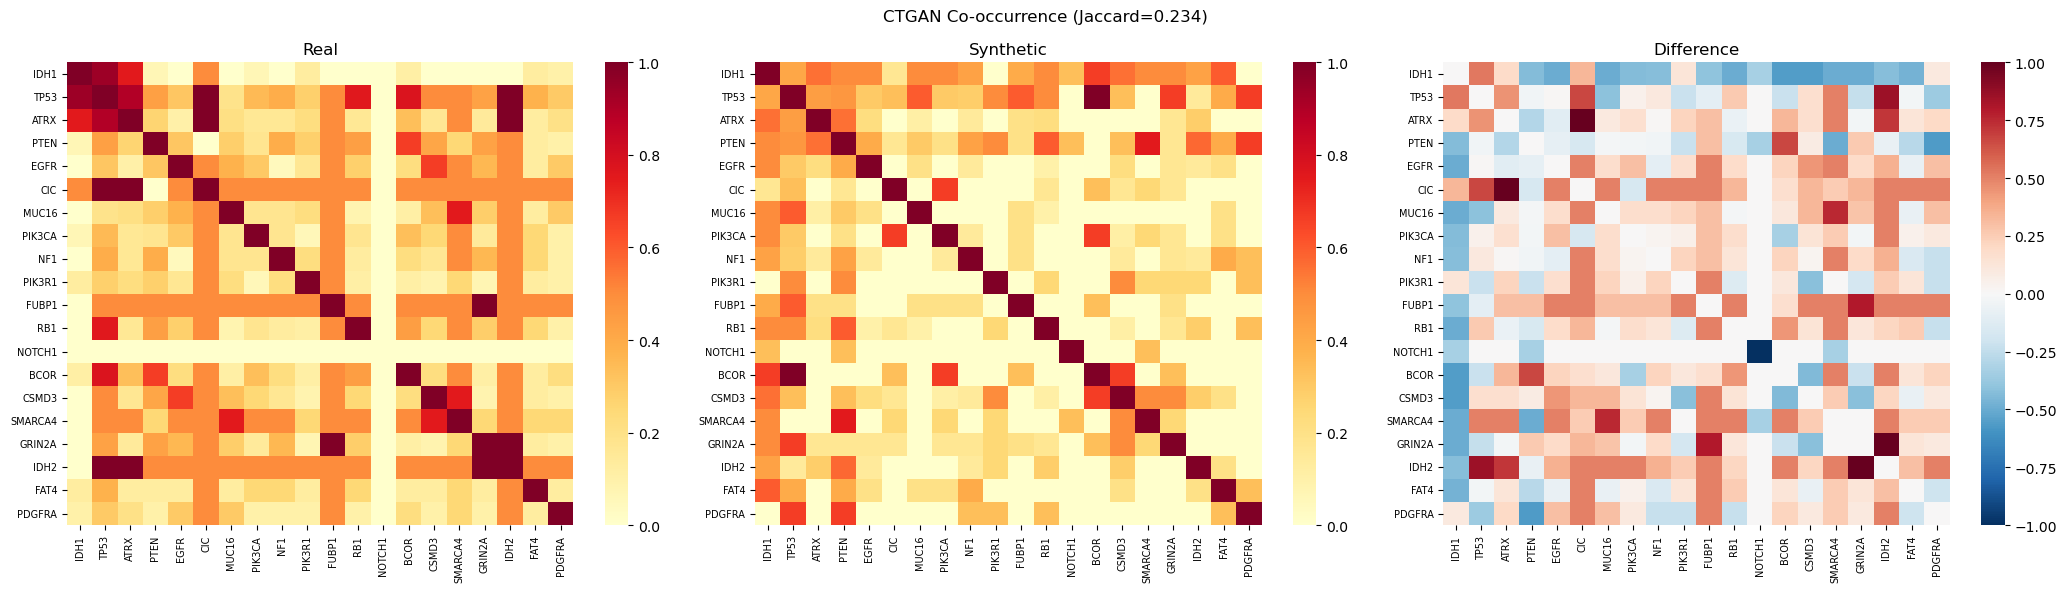

Correlation: Cosine=0.7169 RMSE=0.1832


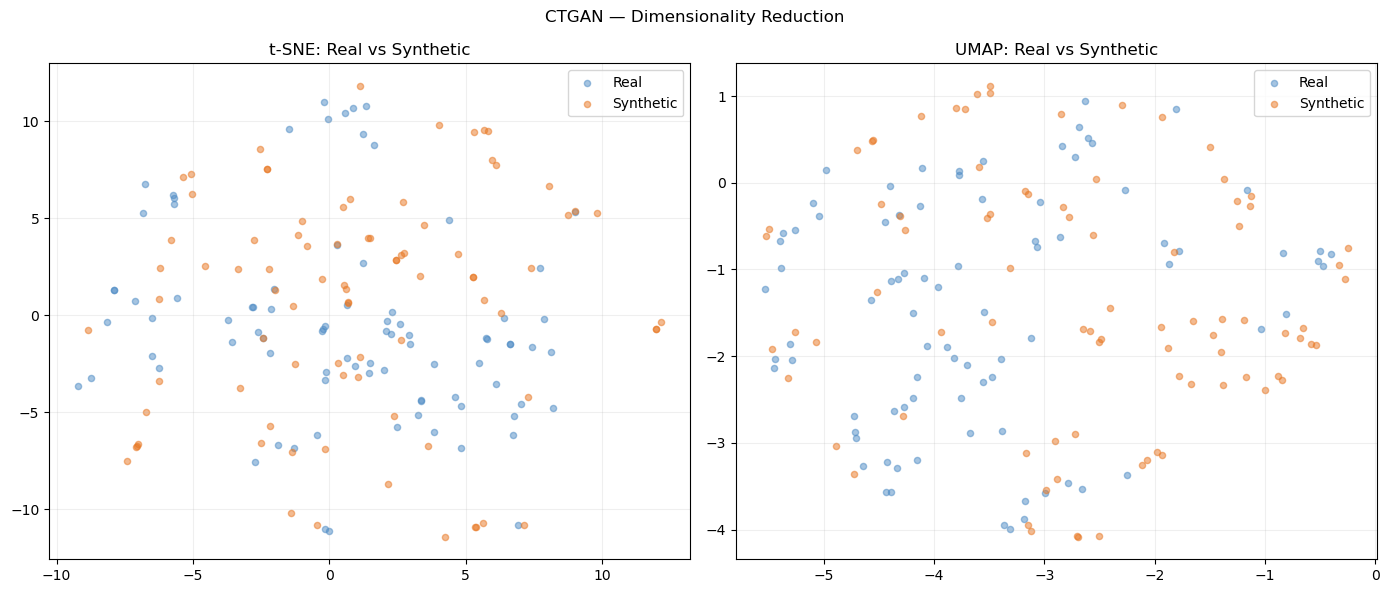


Privacy: distance ratio=2158017846.8746 (SAFE)
Class-conditional quality...


Sampling conditions: 100%|██████████| 200/200 [00:00<00:00, 1363.07it/s]

  Grade 0: 8/21 pass
  Grade 1: 12/21 pass


In [31]:
# Section B — CTGAN Synthetic Data Quality
# ============================================================================
print("\n" + "="*65 + "\nSection B — CTGAN Quality Assessment\n" + "="*65)

_meta_b = SingleTableMetadata()
_meta_b.detect_from_dataframe(train_df)
for col in categorical_columns + gene_columns:
    _meta_b.update_column(column_name=col, sdtype='categorical')
_vc_b  = train_df['Grade'].value_counts()
_n_gen = int(_vc_b.max() - _vc_b.min())
print(f"Generating {_n_gen} synthetic minority patients...")
set_seed(42)
try: torch.use_deterministic_algorithms(False)
except AttributeError: pass
_syn_b = CTGANSynthesizer(_meta_b, epochs=150, batch_size=50, verbose=False, cuda=True, pac=10)
_syn_b.fit(train_df)
_cond_b = Condition(num_rows=_n_gen, column_values={'Grade': int(_vc_b.idxmin())})
syn_df = _syn_b.sample_from_conditions(conditions=[_cond_b])
try: torch.use_deterministic_algorithms(True)
except AttributeError: pass
real_minority_df = train_df[train_df['Grade'] == _vc_b.idxmin()].reset_index(drop=True)
print(f"Real minority: {len(real_minority_df)} | Synthetic: {len(syn_df)}")

# B.1 Feature distribution tests
def compare_feature_distributions(real_df, syn_df, gene_cols, alpha=0.05):
    records = []
    stat_ks, p_ks = stats.ks_2samp(real_df['Age_at_diagnosis'].dropna(), syn_df['Age_at_diagnosis'].dropna())
    records.append({'Feature': 'Age_at_diagnosis', 'Test': 'KS', 'stat': round(stat_ks, 4),
                    'p': round(p_ks, 4), 'pass': p_ks > alpha})
    for col in gene_cols + ['Gender', 'Race']:
        r_counts = real_df[col].value_counts().sort_index()
        s_counts = syn_df[col].value_counts().reindex(r_counts.index, fill_value=0)
        if r_counts.sum() == 0 or s_counts.sum() == 0: continue
        expected = r_counts / r_counts.sum() * s_counts.sum()
        valid = expected > 0
        if valid.sum() < 2:
            records.append({'Feature': col, 'Test': 'chi2', 'stat': np.nan, 'p': 1.0, 'pass': True})
            continue
        stat_c, p_c = stats.chisquare(s_counts[valid], f_exp=expected[valid])
        records.append({'Feature': col, 'Test': 'chi2', 'stat': round(stat_c, 4),
                        'p': round(p_c, 4), 'pass': p_c > alpha})
    return pd.DataFrame(records)

dist_df = compare_feature_distributions(real_minority_df, syn_df, gene_columns)
print(f"Feature tests: {dist_df['pass'].sum()}/{len(dist_df)} pass")
print(dist_df.to_string(index=False))
dist_df.to_csv('ctgan_feat_dist.csv', index=False)

# B.2 Co-occurrence
def mutation_cooccurrence_matrix(df, gene_cols):
    M  = df[gene_cols].values.astype(float)
    co = M.T @ M
    freq = M.sum(axis=0)
    denom = np.minimum.outer(freq, freq); denom[denom == 0] = 1
    return co / denom

cooc_real = mutation_cooccurrence_matrix(real_minority_df, gene_columns)
cooc_syn  = mutation_cooccurrence_matrix(syn_df, gene_columns)
threshold_r = np.percentile(cooc_real[cooc_real > 0], 50) if (cooc_real > 0).any() else 0
threshold_s = np.percentile(cooc_syn[cooc_syn > 0], 50) if (cooc_syn > 0).any() else 0
bin_r = (cooc_real >= threshold_r).astype(int); bin_s = (cooc_syn >= threshold_s).astype(int)
intersection = (bin_r & bin_s).sum(); union = (bin_r | bin_s).sum()
jaccard = intersection / union if union > 0 else 0.0
frobenius = np.linalg.norm(cooc_real - cooc_syn, 'fro')
cosine_sim = (np.dot(cooc_real.flatten(), cooc_syn.flatten()) /
              (np.linalg.norm(cooc_real) * np.linalg.norm(cooc_syn) + 1e-9))
print(f"\nCo-occurrence: Jaccard={jaccard:.4f} Frobenius={frobenius:.4f} Cosine={cosine_sim:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, mat, title in [(axes[0], cooc_real, 'Real'), (axes[1], cooc_syn, 'Synthetic'),
                        (axes[2], cooc_real - cooc_syn, 'Difference')]:
    cmap = 'YlOrRd' if 'Diff' not in title else 'RdBu_r'
    center = 0 if 'Diff' in title else None
    sns.heatmap(pd.DataFrame(mat, index=gene_columns, columns=gene_columns),
                ax=ax, cmap=cmap, center=center, annot=False, xticklabels=True, yticklabels=True)
    ax.set_title(title); ax.tick_params(labelsize=7)
plt.suptitle(f'CTGAN Co-occurrence (Jaccard={jaccard:.3f})')
plt.tight_layout(); plt.savefig('ctgan_cooccurrence.png', dpi=300, bbox_inches='tight'); plt.show()

# B.3 Correlation similarity
num_feats = gene_columns + ['Age_at_diagnosis', 'Gender', 'Race']
corr_real = np.nan_to_num(real_minority_df[num_feats].astype(float).corr().values)
corr_syn  = np.nan_to_num(syn_df[num_feats].astype(float).corr().values)
cos_corr  = (np.dot(corr_real.flatten(), corr_syn.flatten()) /
             (np.linalg.norm(corr_real) * np.linalg.norm(corr_syn) + 1e-9))
rmse_corr = np.sqrt(np.mean((corr_real - corr_syn)**2))
print(f"Correlation: Cosine={cos_corr:.4f} RMSE={rmse_corr:.4f}")

# B.4 t-SNE / UMAP
from sklearn.manifold import TSNE
import umap

feats_all = gene_columns + ['Age_at_diagnosis', 'Gender', 'Race']
N_VIZ = min(300, len(real_minority_df), len(syn_df))
rng_v = np.random.default_rng(42)
X_real = real_minority_df.iloc[rng_v.choice(len(real_minority_df), N_VIZ, replace=False)][feats_all].astype(float).values
X_syn  = syn_df.iloc[rng_v.choice(len(syn_df), N_VIZ, replace=False)][feats_all].astype(float).values
X_comb = np.vstack([X_real, X_syn])
y_comb = np.array([0]*N_VIZ + [1]*N_VIZ)
X_scaled = StandardScaler().fit_transform(X_comb)

X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_scaled)
X_umap = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, emb, title in [(axes[0], X_tsne, 't-SNE'), (axes[1], X_umap, 'UMAP')]:
    for cls, col, lbl in [(0, '#4C8AC4', 'Real'), (1, '#E87722', 'Synthetic')]:
        m = y_comb == cls
        ax.scatter(emb[m, 0], emb[m, 1], c=col, label=lbl, alpha=0.5, s=20)
    ax.set_title(f'{title}: Real vs Synthetic'); ax.legend(); ax.grid(alpha=0.2)
plt.suptitle('CTGAN — Dimensionality Reduction')
plt.tight_layout(); plt.savefig('ctgan_tsne_umap.png', dpi=300, bbox_inches='tight'); plt.show()

# B.5 NN Privacy
from sklearn.neighbors import KDTree
scaler_nn = StandardScaler()
X_train_nn = scaler_nn.fit_transform(train_df[feats_all].astype(float).values)
X_syn_nn   = scaler_nn.transform(syn_df[feats_all].astype(float).values)
X_heldout  = scaler_nn.transform(real_minority_df[feats_all].astype(float).values)
tree = KDTree(X_train_nn, leaf_size=30)
dists_syn, _    = tree.query(X_syn_nn,  k=5)
dists_heldout,_ = tree.query(X_heldout, k=1)
med_syn  = np.median(dists_syn[:, 0])
med_real = np.median(dists_heldout[:, 0])
ratio    = med_syn / (med_real + 1e-9)
print(f"\nPrivacy: distance ratio={ratio:.4f} ({'SAFE' if ratio >= 1.0 else 'WARNING'})")

# B.6 Class-conditional
print("Class-conditional quality...")
cc_records = []
for grade in [0, 1]:
    real_cls = train_df[train_df['Grade'] == grade]
    n_syn_cls = min(len(real_cls), 200)
    cond_cls = Condition(num_rows=n_syn_cls, column_values={'Grade': grade})
    syn_cls = _syn_b.sample_from_conditions(conditions=[cond_cls])
    stat_a, p_a = stats.ks_2samp(real_cls['Age_at_diagnosis'], syn_cls['Age_at_diagnosis'])
    cc_records.append({'Grade': grade, 'Feature': 'Age_at_diagnosis', 'Test': 'KS',
                        'stat': round(stat_a, 4), 'p': round(p_a, 4), 'pass': p_a > 0.05})
    for gene in gene_columns:
        r_c = real_cls[gene].value_counts().reindex([0,1], fill_value=0)
        s_c = syn_cls[gene].value_counts().reindex([0,1], fill_value=0)
        expected = r_c / r_c.sum() * s_c.sum()
        if (expected > 0).all():
            chi2, p_chi = stats.chisquare(s_c, f_exp=expected)
        else:
            chi2, p_chi = np.nan, 1.0
        cc_records.append({'Grade': grade, 'Feature': gene, 'Test': 'chi2',
                            'stat': round(chi2, 4) if not np.isnan(chi2) else np.nan,
                            'p': round(p_chi, 4), 'pass': p_chi > 0.05})
cc_df = pd.DataFrame(cc_records)
for grade in [0, 1]:
    sub = cc_df[cc_df.Grade == grade]
    print(f"  Grade {grade}: {sub['pass'].sum()}/{len(sub)} pass")
cc_df.to_csv('ctgan_class_conditional.csv', index=False)


Section C — Graph Strategy Comparison


Sampling conditions: 100%|██████████| 107/107 [00:00<00:00, 794.78it/s]



  Strategy: BA (proposed)
    TCGA Test: AUC=0.9203
    CGGA: AUC=0.7306

  Strategy: KNN (k=5)
    TCGA Test: AUC=0.9181
    CGGA: AUC=0.7328

  Strategy: Co-occurrence
    TCGA Test: AUC=0.9225
    CGGA: AUC=0.7543

  Strategy: Correlation
    TCGA Test: AUC=0.9264
    CGGA: AUC=0.7522

  Strategy: Fully Connected
    TCGA Test: AUC=0.9225
    CGGA: AUC=0.7446

  Strategy: Learned (NRI)
    TCGA Test: AUC=0.9251
    CGGA: AUC=0.7543

Graph Strategy Comparison:
       Strategy   Dataset    AUC     F1  Recall_1  Recall_0
  BA (proposed) TCGA Test 0.9203 0.8194    0.8310    0.8557
  BA (proposed)      CGGA 0.7306 0.6286    0.7549    0.6374
      KNN (k=5) TCGA Test 0.9181 0.8028    0.8028    0.8557
      KNN (k=5)      CGGA 0.7328 0.5778    0.6373    0.6813
  Co-occurrence TCGA Test 0.9225 0.8169    0.8169    0.8660
  Co-occurrence      CGGA 0.7543 0.6180    0.7059    0.6758
    Correlation TCGA Test 0.9264 0.8138    0.8310    0.8454
    Correlation      CGGA 0.7522 0.6360    0.7451   

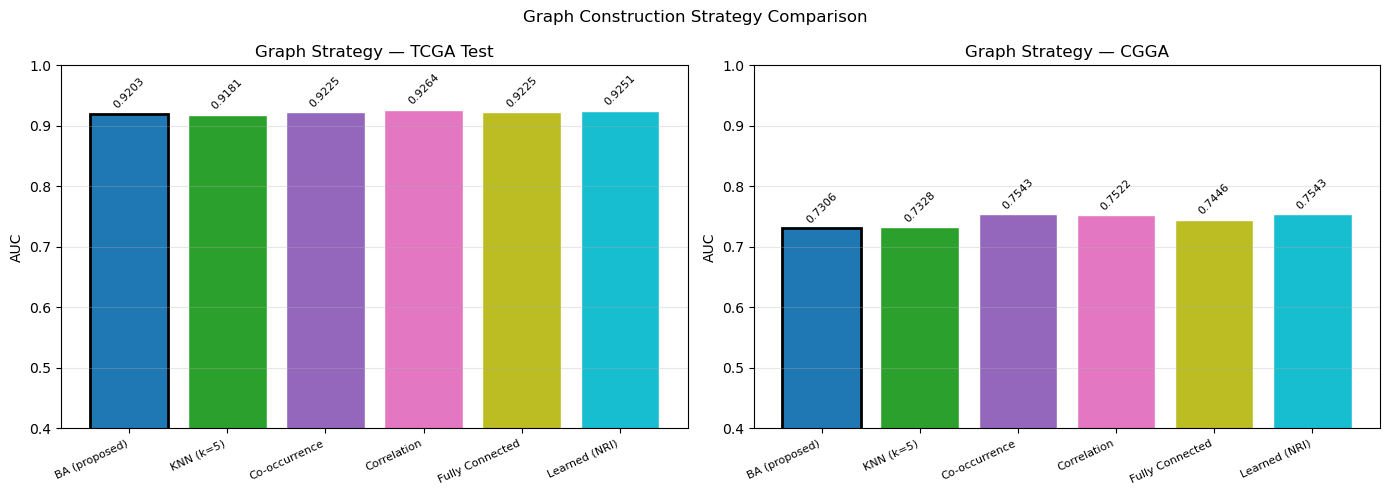

In [32]:
# Section C — Graph Construction Strategy Comparison
# ============================================================================
print("\n" + "="*65 + "\nSection C — Graph Strategy Comparison\n" + "="*65)

from sklearn.neighbors import NearestNeighbors

def _make_base_heterodata(df, scaler=None):
    if scaler is None:
        scaler = StandardScaler()
        scaler.fit(df[['Age_at_diagnosis']].values.astype(float))
    age_n   = scaler.transform(df[['Age_at_diagnosis']].values.astype(float))
    gender  = df[['Gender']].values.astype(float)
    race_oh = np.zeros((len(df), 4), dtype=float)
    for i, rv in enumerate(df['Race'].values.astype(int)):
        if 0 <= rv < 4: race_oh[i, rv] = 1.0
    pat_feat = np.hstack([gender, race_oh, age_n])
    g = HeteroData()
    g['Patient'].x = torch.tensor(pat_feat, dtype=torch.float)
    g['Patient'].y = torch.tensor(df['Grade'].values, dtype=torch.long)
    g['Gene'].x    = torch.eye(NUM_GENES, dtype=torch.float)
    src_g, dst_p = [], []
    for pi, (_, row) in enumerate(df.iterrows()):
        for gi, gene in enumerate(gene_columns):
            if int(row[gene]) == 1: src_g.append(gi); dst_p.append(pi)
    g[('Gene','mutates','Patient')].edge_index    = torch.tensor([src_g, dst_p], dtype=torch.long)
    g[('Patient','mutated_by','Gene')].edge_index = torch.tensor([dst_p, src_g], dtype=torch.long)
    g[('Gene','coexists','Gene')].edge_index = torch.zeros(2, 0, dtype=torch.long)
    return g


def build_knn_graph(df, k=5, scaler=None):
    g = _make_base_heterodata(df, scaler=scaler)
    X = StandardScaler().fit_transform(
        df[gene_columns + ['Age_at_diagnosis','Gender','Race']].astype(float).values)
    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='ball_tree').fit(X)
    _, inds = nbrs.kneighbors(X)
    src, dst = [], []
    for i, neighbours in enumerate(inds):
        for j in neighbours[1:]: src += [i, j]; dst += [j, i]
    g[('Patient','cooccurs','Patient')].edge_index = torch.tensor([src, dst], dtype=torch.long)
    return g


def build_cooccurrence_graph(df, min_jaccard=0.3, scaler=None):
    g = _make_base_heterodata(df, scaler=scaler)
    M = df[gene_columns].values.astype(float); n = len(df)
    src, dst = [], []
    for i in range(n):
        for j in range(i+1, n):
            inter = np.minimum(M[i], M[j]).sum()
            union = np.maximum(M[i], M[j]).sum()
            if union > 0 and inter / union >= min_jaccard:
                src += [i, j]; dst += [j, i]
    if src:
        g[('Patient','cooccurs','Patient')].edge_index = torch.tensor([src, dst], dtype=torch.long)
    else:
        g[('Patient','cooccurs','Patient')].edge_index = torch.zeros(2, 0, dtype=torch.long)
    return g


def build_correlation_graph(df, min_pearson=0.3, scaler=None):
    g = _make_base_heterodata(df, scaler=scaler)
    M = df[gene_columns].values.astype(float)
    M_norm = M - M.mean(axis=1, keepdims=True)
    norms  = np.linalg.norm(M_norm, axis=1, keepdims=True) + 1e-9
    M_norm = M_norm / norms
    corr   = M_norm @ M_norm.T
    rows, cols = np.where((corr >= min_pearson) & ~np.eye(len(df), dtype=bool))
    src = list(rows) + list(cols); dst = list(cols) + list(rows)
    if src:
        g[('Patient','cooccurs','Patient')].edge_index = torch.tensor([src, dst], dtype=torch.long)
    else:
        g[('Patient','cooccurs','Patient')].edge_index = torch.zeros(2, 0, dtype=torch.long)
    return g


def build_fully_connected_graph(df, scaler=None):
    g = _make_base_heterodata(df, scaler=scaler)
    n = len(df)
    rows, cols = np.meshgrid(np.arange(n), np.arange(n)); mask = rows != cols
    g[('Patient','cooccurs','Patient')].edge_index = torch.tensor([rows[mask], cols[mask]], dtype=torch.long)
    return g


def build_learned_graph(df, n_epochs=30, lr=1e-3, scaler=None):
    g = _make_base_heterodata(df, scaler=scaler)
    X = torch.tensor(StandardScaler().fit_transform(
            df[gene_columns + ['Age_at_diagnosis','Gender','Race']].astype(float).values
        ), dtype=torch.float)
    y = torch.tensor(df['Grade'].values, dtype=torch.long)
    n = X.shape[0]; d = X.shape[1]
    enc = torch.nn.Sequential(torch.nn.Linear(d*2, 32), torch.nn.ReLU(),
                               torch.nn.Linear(32, 1), torch.nn.Sigmoid())
    opt = torch.optim.Adam(enc.parameters(), lr=lr)
    enc.train()
    for _ in range(n_epochs):
        idx = torch.randperm(n)[:32]
        pi = idx.repeat_interleave(32); pj = idx.repeat(32)
        mask = pi != pj; pi, pj = pi[mask], pj[mask]
        scores = enc(torch.cat([X[pi], X[pj]], dim=-1)).squeeze(-1)
        same   = (y[pi] == y[pj]).float()
        loss   = torch.nn.functional.binary_cross_entropy(scores, same)
        opt.zero_grad(); loss.backward(); opt.step()
    enc.eval()
    src_l, dst_l = [], []
    with torch.no_grad():
        for i in range(n):
            j_all = torch.arange(n); j_all = j_all[j_all != i]
            xi = X[i].unsqueeze(0).expand(len(j_all), -1)
            scores_i = enc(torch.cat([xi, X[j_all]], dim=-1)).squeeze(-1)
            keep = j_all[scores_i >= 0.5].tolist()
            src_l += [i]*len(keep); dst_l += keep
    if src_l:
        g[('Patient','cooccurs','Patient')].edge_index = torch.tensor([src_l, dst_l], dtype=torch.long)
    else:
        g[('Patient','cooccurs','Patient')].edge_index = torch.zeros(2, 0, dtype=torch.long)
    return g


GRAPH_STRATEGIES = {
    'BA (proposed)':     lambda df, scaler=None: construct_scalefree_bipartite_heterograph(df, scaler=scaler),
    'KNN (k=5)':         lambda df, scaler=None: build_knn_graph(df, scaler=scaler),
    'Co-occurrence':     lambda df, scaler=None: build_cooccurrence_graph(df, min_jaccard=0.3, scaler=scaler),
    'Correlation':       lambda df, scaler=None: build_correlation_graph(df, min_pearson=0.3, scaler=scaler),
    'Fully Connected':   lambda df, scaler=None: build_fully_connected_graph(df, scaler=scaler),
    'Learned (NRI)':     lambda df, scaler=None: build_learned_graph(df, scaler=scaler),
}

# Generate augmented training data for graph strategy comparison
aug_df_strat = apply_ctgan(train_val_df.copy())
strat_scaler = StandardScaler()
strat_scaler.fit(train_val_df[['Age_at_diagnosis']].values.astype(float))

graph_results = []
for strat_name, graph_fn in GRAPH_STRATEGIES.items():
    print(f"\n  Strategy: {strat_name}")
    set_seed(42)
    try:
        tr_g = to_dev(graph_fn(aug_df_strat, scaler=strat_scaler))
        te_g = to_dev(graph_fn(test_df, scaler=strat_scaler))
        cg_g = to_dev(graph_fn(cgga_df, scaler=strat_scaler))
        vg_  = to_dev(graph_fn(val_df, scaler=strat_scaler))
    except Exception as e:
        print(f"    ERROR: {e}"); continue

    _, state, _ = train_and_evaluate(tr_g, vg_, BEST_BP_TCGA, BEST_MODEL_CLS_TCGA, BEST_FKW_TCGA,
                                      seed=42, loss_fn=make_criterion(tr_g))
    kw_g = {'hidden_dim': BEST_BP_TCGA['hidden_dim'], 'out_dim': 2,
             'num_heads': BEST_BP_TCGA['num_heads'], 'dropout': BEST_BP_TCGA['dropout']}
    kw_g.update(BEST_FKW_TCGA)
    m_g = BEST_MODEL_CLS_TCGA(**kw_g).to(device)
    try:
        with torch.no_grad(): _ = m_g(tr_g)
    except: pass
    m_g.load_state_dict(state)

    for ds_name, ds_g in [('TCGA Test', te_g), ('CGGA', cg_g)]:
        pd_, pb_, lb_ = evaluate_model(m_g, ds_g, threshold=BEST_THRESHOLD_TCGA)
        try:    auc = roc_auc_score(lb_, pb_)
        except: auc = np.nan
        graph_results.append({
            'Strategy': strat_name, 'Dataset': ds_name,
            'AUC': round(auc, 4),
            'F1': round(f1_score(lb_, pd_, zero_division=0), 4),
            'Recall_1': round(recall_score(lb_, pd_, pos_label=1, zero_division=0), 4),
            'Recall_0': round(recall_score(lb_, pd_, pos_label=0, zero_division=0), 4),
        })
        print(f"    {ds_name}: AUC={auc:.4f}")

graph_df = pd.DataFrame(graph_results)
print("\nGraph Strategy Comparison:")
print(graph_df.to_string(index=False))
graph_df.to_csv('graph_strategy_comparison.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
strategy_order = list(GRAPH_STRATEGIES.keys())
colors_gs = plt.cm.tab10(np.linspace(0, 1, len(strategy_order)))
for ax, ds in zip(axes, ['TCGA Test', 'CGGA']):
    sub = graph_df[graph_df.Dataset == ds].set_index('Strategy').reindex(strategy_order)
    bars = ax.bar(range(len(strategy_order)), sub['AUC'].fillna(0), color=colors_gs, edgecolor='white')
    bars[0].set_edgecolor('black'); bars[0].set_linewidth(2)
    for xi, v in enumerate(sub['AUC'].fillna(0)):
        ax.text(xi, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=8, rotation=45)
    ax.set_xticks(range(len(strategy_order)))
    ax.set_xticklabels(strategy_order, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('AUC'); ax.set_ylim(0.4, 1.0); ax.set_title(f'Graph Strategy — {ds}')
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Graph Construction Strategy Comparison')
plt.tight_layout(); plt.savefig('graph_strategy_comparison.png', dpi=300, bbox_inches='tight'); plt.show()


Section D — Tabular Baselines + SHAP
Feature matrix: train_val=(669, 26), test=(168, 26), cgga=(284, 26)
  Tuning XGBoost... 

/home/nafim/anaconda3/envs/glioma/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/nafim/anaconda3/envs/glioma/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/nafim/anaconda3/envs/glioma/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using 

best_AUC_CV=nan
  Tuning RandomForest... best_AUC_CV=0.9176
  Tuning SVM... best_AUC_CV=0.9123
  Tuning MLP... best_AUC_CV=0.9077
  XGBoost         TCGA Test : AUC=0.9286 F1=0.8684
  XGBoost         CGGA      : AUC=0.7800 F1=0.6250
  RandomForest    TCGA Test : AUC=0.9291 F1=0.8725
  RandomForest    CGGA      : AUC=0.7960 F1=0.6696
  SVM             TCGA Test : AUC=0.9162 F1=0.8684
  SVM             CGGA      : AUC=0.7360 F1=0.6393
  MLP             TCGA Test : AUC=0.9307 F1=0.8591
  MLP             CGGA      : AUC=0.7887 F1=0.6570

5-Fold CV (Baselines):
                 auc              f1        
                mean     std    mean     std
Model                                       
MLP           0.9077  0.0288  0.8490  0.0369
RandomForest  0.9176  0.0157  0.8603  0.0273
SVM           0.9117  0.0190  0.8606  0.0217
XGBoost       0.9175  0.0234  0.8591  0.0322

DeLong: MOGAT AUC=0.8994 vs MLP AUC=0.9307 Z=-2.063 p=0.0391

SHAP Analysis

XGBoost — Top-10 SHAP features:
   1. IDH1   

  0%|          | 0/100 [00:00<?, ?it/s]


SVM — Top-10 SHAP features (n=100):
   1. IDH1              : 0.2823
   2. Age_norm          : 0.0345
   3. ATRX              : 0.0184
   4. PTEN              : 0.0149
   5. CIC               : 0.0132
   6. IDH2              : 0.0123
   7. NF1               : 0.0071
   8. Race_White        : 0.0043
   9. TP53              : 0.0038
  10. Gender            : 0.0035


  0%|          | 0/100 [00:00<?, ?it/s]


MLP — Top-10 SHAP features (n=100):
   1. IDH1              : 0.1726
   2. Age_norm          : 0.1455
   3. PTEN              : 0.0402
   4. CIC               : 0.0201
   5. ATRX              : 0.0140
   6. Gender            : 0.0101
   7. Race_Black        : 0.0095
   8. GRIN2A            : 0.0065
   9. TP53              : 0.0047
  10. EGFR              : 0.0047


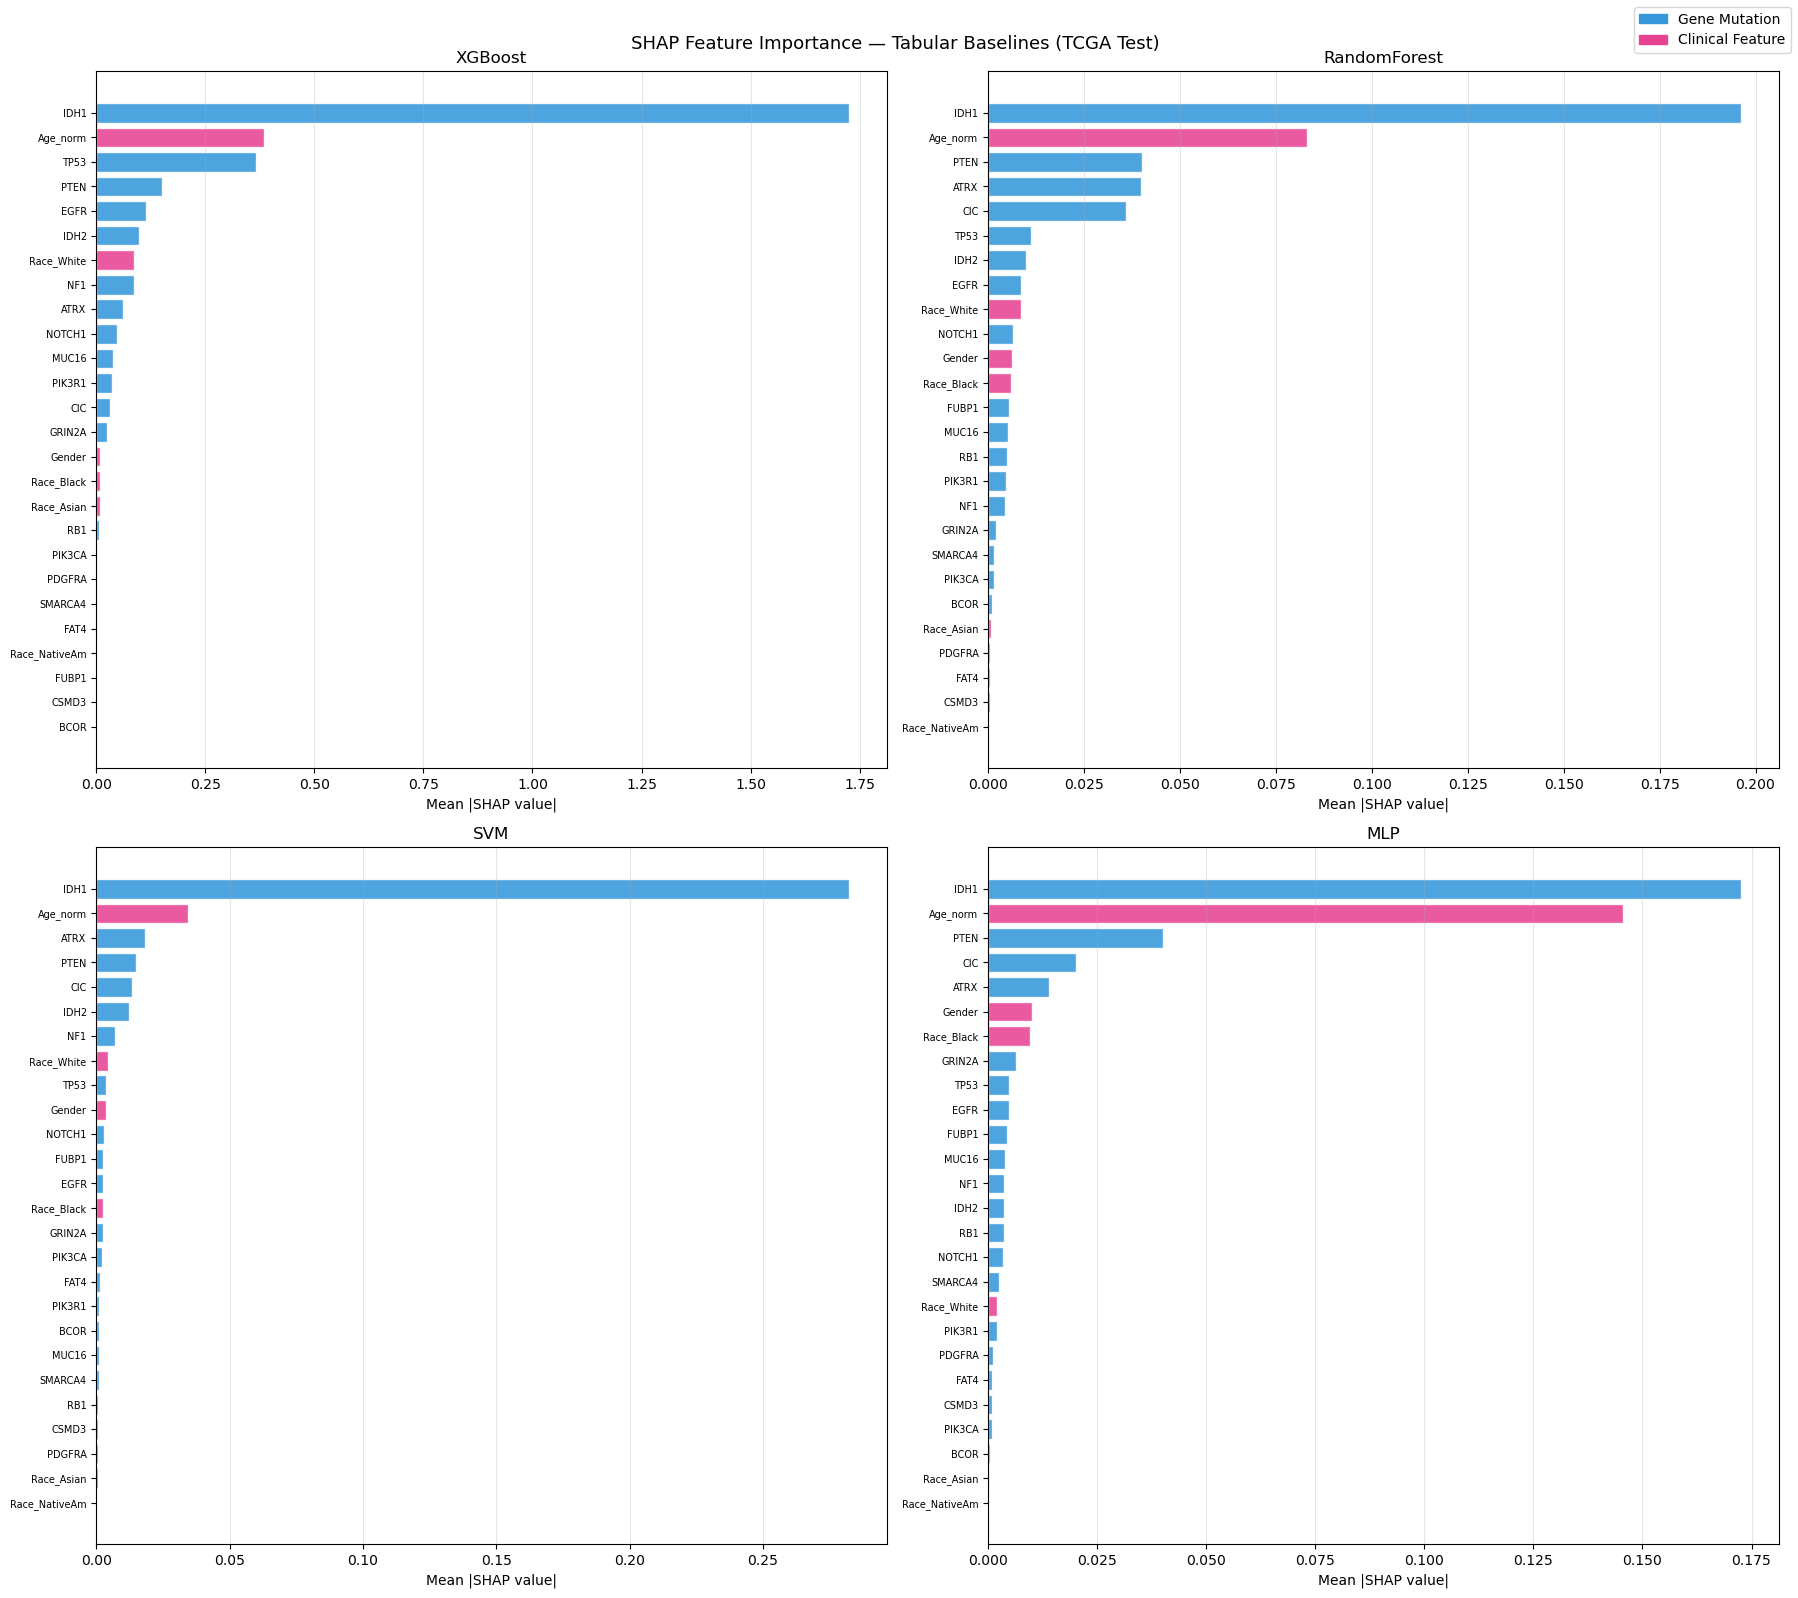

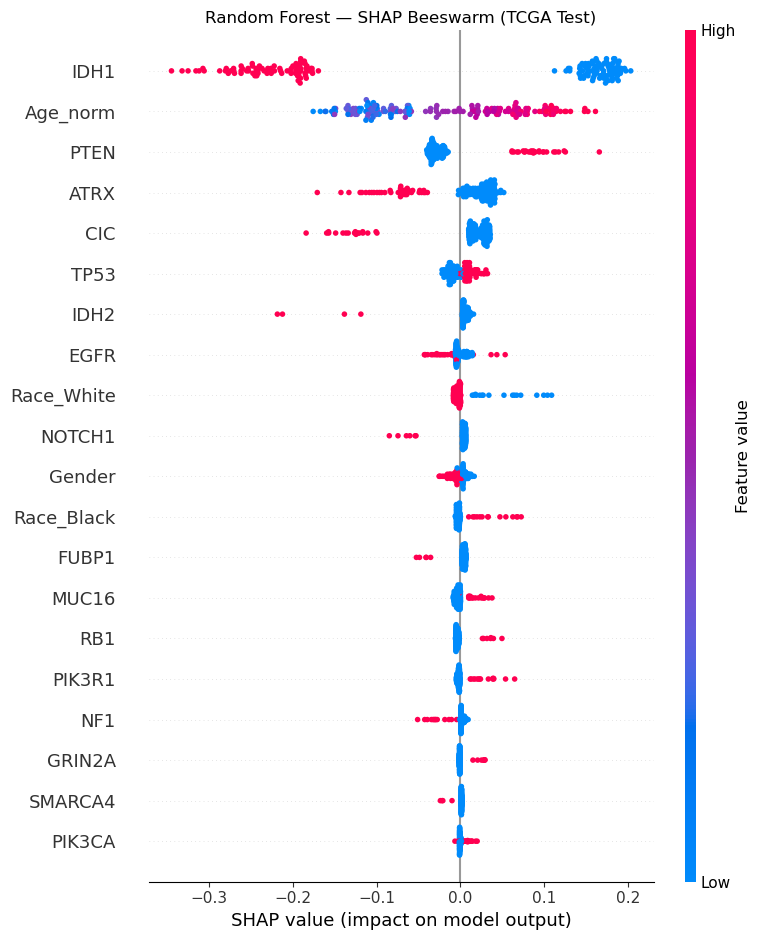

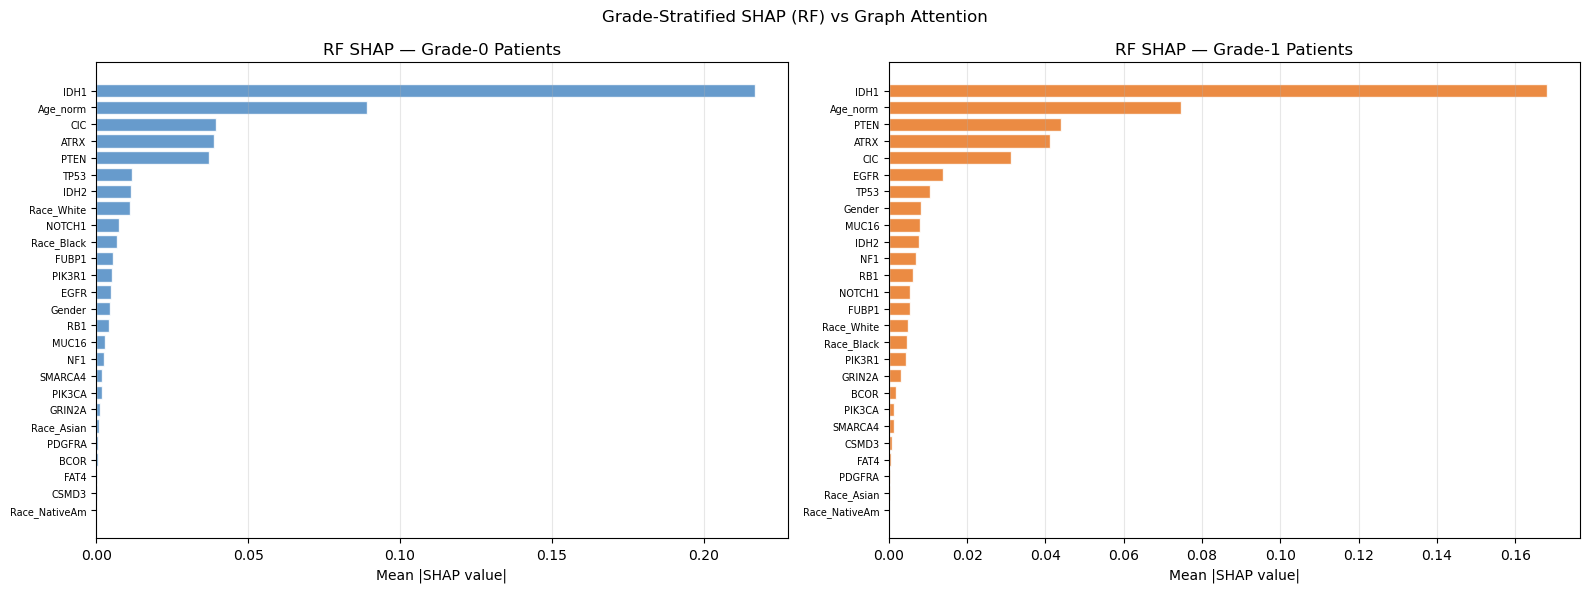


SHAP (RandomForest) vs Edge Occlusion (Best GNN) — Gene Ranking

  Rank               SHAP (RF)    Edge Occlusion (GNN)
     1                    IDH1                    IDH1  Y
     2                    PTEN                    IDH2  
     3                    ATRX                     NF1  
     4                     CIC                  GRIN2A  
     5                    TP53                    PTEN  
     6                    IDH2                    FAT4  
     7                    EGFR                    EGFR  Y
     8                  NOTCH1                   MUC16  
     9                   FUBP1                  PIK3CA  
    10                   MUC16                  PIK3R1  

  Spearman rho=0.195, p=0.4088

SHAP analysis complete.


In [33]:
# Section D — Non-GNN Tabular Baselines + SHAP
# ============================================================================
print("\n" + "="*65 + "\nSection D — Tabular Baselines + SHAP\n" + "="*65)

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

def build_tabular_features(df, scaler=None):
    if scaler is None:
        scaler = StandardScaler()
        scaler.fit(df[['Age_at_diagnosis']].values.astype(float))
    age_n   = scaler.transform(df[['Age_at_diagnosis']].values.astype(float))
    gender  = df[['Gender']].values.astype(float)
    race_oh = np.zeros((len(df), 4), dtype=float)
    for i, rv in enumerate(df['Race'].values.astype(int)):
        if 0 <= rv < 4: race_oh[i, rv] = 1.0
    genes = df[gene_columns].values.astype(float)
    X = np.hstack([genes, gender, race_oh, age_n])
    y = df['Grade'].values
    return X, y

tab_scaler = StandardScaler()
tab_scaler.fit(train_val_df[['Age_at_diagnosis']].values.astype(float))
X_trainval, y_trainval = build_tabular_features(train_val_df, scaler=tab_scaler)
X_test,     y_test     = build_tabular_features(test_df,      scaler=tab_scaler)
X_cgga,     y_cgga     = build_tabular_features(cgga_df,      scaler=tab_scaler)
print(f"Feature matrix: train_val={X_trainval.shape}, test={X_test.shape}, cgga={X_cgga.shape}")

FEATURE_NAMES = (gene_columns +
                 ['Gender', 'Race_White', 'Race_Black', 'Race_Asian',
                  'Race_NativeAm', 'Age_norm'])

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n0_t, n1_t = (y_trainval == 0).sum(), (y_trainval == 1).sum()

BASELINES = {
    'XGBoost': (
        XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                      random_state=42, scale_pos_weight=n0_t/n1_t),
        {'n_estimators': [100, 300], 'max_depth': [3, 5],
         'learning_rate': [0.05, 0.1], 'subsample': [0.8, 1.0]}
    ),
    'RandomForest': (
        RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        {'n_estimators': [100, 300], 'max_depth': [None, 10], 'min_samples_leaf': [1, 3]}
    ),
    'SVM': (
        SVC(class_weight='balanced', random_state=42, probability=True),
        {'C': [0.1, 1, 10], 'gamma': ['scale', 0.01, 0.001]}
    ),
    'MLP': (
        MLPClassifier(random_state=42, max_iter=500, early_stopping=True),
        {'hidden_layer_sizes': [(64, 32), (128, 64), (256, 128)],
         'alpha': [1e-4, 1e-3], 'learning_rate_init': [1e-3, 5e-4]}
    ),
}

baseline_best = {}
for name, (est, param_grid) in BASELINES.items():
    print(f"  Tuning {name}...", end=' ')
    gs = GridSearchCV(est, param_grid, cv=cv5, scoring='roc_auc', n_jobs=-1, refit=True)
    gs.fit(X_trainval, y_trainval)
    baseline_best[name] = gs.best_estimator_
    print(f"best_AUC_CV={gs.best_score_:.4f}")

def eval_baseline(model, X, y):
    pb = model.predict_proba(X)[:, 1]
    th = find_optimal_threshold(pb, y)
    pd_ = (pb >= th).astype(int)
    try:    auc = roc_auc_score(y, pb)
    except: auc = np.nan
    return {'AUC': round(auc, 4), 'F1': round(f1_score(y, pd_, zero_division=0), 4),
            'Recall_1': round(recall_score(y, pd_, pos_label=1, zero_division=0), 4),
            'Recall_0': round(recall_score(y, pd_, pos_label=0, zero_division=0), 4),
            'Threshold': round(th, 3), 'probs': pb, 'labels': y, 'preds': pd_}

baseline_results = []
for name, model in baseline_best.items():
    for ds_name, X_, y_ in [('TCGA Test', X_test, y_test), ('CGGA', X_cgga, y_cgga)]:
        r = eval_baseline(model, X_, y_)
        baseline_results.append({'Model': f'Baseline/{name}', 'Dataset': ds_name,
                                  **{k: v for k, v in r.items() if k not in ('probs','labels','preds')}})
        print(f"  {name:15s} {ds_name:10s}: AUC={r['AUC']:.4f} F1={r['F1']:.4f}")

# 5-Fold CV for baselines
cv_bl_records = []
for name, model in baseline_best.items():
    for fold, (tr_i, vl_i) in enumerate(cv5.split(X_trainval, y_trainval), 1):
        m_cv = copy.deepcopy(model); m_cv.fit(X_trainval[tr_i], y_trainval[tr_i])
        pb_cv = m_cv.predict_proba(X_trainval[vl_i])[:, 1]
        lb_cv = y_trainval[vl_i]
        th_cv = find_optimal_threshold(pb_cv, lb_cv)
        pd_cv = (pb_cv >= th_cv).astype(int)
        try:    auc_cv = roc_auc_score(lb_cv, pb_cv)
        except: auc_cv = np.nan
        cv_bl_records.append({'Model': name, 'fold': fold, 'auc': auc_cv,
                               'f1': f1_score(lb_cv, pd_cv, zero_division=0)})
cv_bl_df = pd.DataFrame(cv_bl_records)
print("\n5-Fold CV (Baselines):")
print(cv_bl_df.groupby('Model')[['auc','f1']].agg(['mean','std']).round(4).to_string())

baseline_df = pd.DataFrame(baseline_results)
baseline_df.to_csv('tabular_baselines.csv', index=False)

# DeLong: best GNN vs best baseline
best_bl_name = baseline_df[baseline_df.Dataset=='TCGA Test'].sort_values('AUC', ascending=False).iloc[0]['Model'].replace('Baseline/', '')
pb_gnn, lb_gnn = None, None
for pipe in PIPELINES:
    pb_gnn, lb_gnn = _get_result(BEST_MODEL_NAME_TCGA, pipe)
    if pb_gnn is not None: break
pb_bl = baseline_best[best_bl_name].predict_proba(X_test)[:, 1]
if pb_gnn is not None:
    auc_gnn, auc_bl, z_dl, p_dl = delong_test(pb_gnn, pb_bl, lb_gnn)
    print(f"\nDeLong: {BEST_MODEL_NAME_TCGA} AUC={auc_gnn:.4f} vs {best_bl_name} AUC={auc_bl:.4f} Z={z_dl:.3f} p={p_dl:.4f}")


# ── D.4 SHAP Feature Attribution ────────────────────────────────────────────
print("\n" + "="*65 + "\nSHAP Analysis\n" + "="*65)
import shap

shap_results = {}

def _extract_shap_values(shap_out):
    if hasattr(shap_out, 'values'):
        sv = shap_out.values
    elif isinstance(shap_out, list):
        sv = shap_out[1]
    else:
        sv = shap_out
    sv = np.array(sv)
    if sv.ndim == 3:
        sv = sv[:, :, 1]
    return sv

for name in ['XGBoost', 'RandomForest']:
    model_bl = baseline_best[name]
    explainer = shap.TreeExplainer(model_bl)
    sv = _extract_shap_values(explainer.shap_values(X_test))
    shap_results[name] = sv
    mean_abs = np.abs(sv).mean(axis=0)
    rank = list(np.argsort(-mean_abs))
    print(f"\n{name} — Top-10 SHAP features:")
    for i in range(min(10, len(rank))):
        idx = int(rank[i])
        print(f"  {i+1:2d}. {FEATURE_NAMES[idx]:18s}: {mean_abs[idx]:.4f}")

background = shap.kmeans(X_trainval, 50)
for name in ['SVM', 'MLP']:
    model_bl = baseline_best[name]
    explainer = shap.KernelExplainer(model_bl.predict_proba, background)
    sv = _extract_shap_values(explainer.shap_values(X_test[:100], nsamples=200))
    shap_results[name] = sv
    mean_abs = np.abs(sv).mean(axis=0)
    rank = list(np.argsort(-mean_abs))
    print(f"\n{name} — Top-10 SHAP features (n=100):")
    for i in range(min(10, len(rank))):
        idx = int(rank[i])
        print(f"  {i+1:2d}. {FEATURE_NAMES[idx]:18s}: {mean_abs[idx]:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(18, 16))
for ax, name in zip(axes.flatten(), ['XGBoost', 'RandomForest', 'SVM', 'MLP']):
    sv = shap_results[name]
    mean_abs = np.abs(sv).mean(axis=0)
    order = list(np.argsort(mean_abs))
    ax.barh([FEATURE_NAMES[int(i)] for i in order],
            [float(mean_abs[int(i)]) for i in order],
            color=['#e84393' if FEATURE_NAMES[int(i)] in CLINICAL_FEAT_NAMES else '#3498db'
                   for i in order],
            edgecolor='white', alpha=0.88)
    ax.set_xlabel('Mean |SHAP value|'); ax.set_title(f'{name}')
    ax.grid(axis='x', alpha=0.3); ax.tick_params(axis='y', labelsize=7)
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color='#3498db', label='Gene Mutation'),
                    Patch(color='#e84393', label='Clinical Feature')],
           loc='upper right', fontsize=10)
plt.suptitle('SHAP Feature Importance — Tabular Baselines (TCGA Test)', fontsize=13)
plt.tight_layout(); plt.savefig('shap_baselines.png', dpi=300, bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_results['RandomForest'], X_test,
                  feature_names=FEATURE_NAMES, show=False, max_display=20)
plt.title('Random Forest — SHAP Beeswarm (TCGA Test)')
plt.tight_layout(); plt.savefig('shap_beeswarm_rf.png', dpi=300, bbox_inches='tight'); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sv_rf = shap_results['RandomForest']
for ax, grade, color, title in [(axes[0], 0, '#4C8AC4', 'Grade-0'), (axes[1], 1, '#E87722', 'Grade-1')]:
    mask = y_test == grade
    mean_abs = np.abs(sv_rf[mask]).mean(axis=0)
    order = list(np.argsort(mean_abs))
    ax.barh([FEATURE_NAMES[int(i)] for i in order],
            [float(mean_abs[int(i)]) for i in order],
            color=color, edgecolor='white', alpha=0.85)
    ax.set_xlabel('Mean |SHAP value|'); ax.set_title(f'RF SHAP — {title} Patients')
    ax.grid(axis='x', alpha=0.3); ax.tick_params(axis='y', labelsize=7)
plt.suptitle('Grade-Stratified SHAP (RF) vs Graph Attention')
plt.tight_layout(); plt.savefig('shap_grade_stratified.png', dpi=300, bbox_inches='tight'); plt.show()

print("\n" + "="*75)
print("SHAP (RandomForest) vs Edge Occlusion (Best GNN) — Gene Ranking")
print("="*75)
rf_mean_abs = np.abs(shap_results['RandomForest']).mean(axis=0)
rf_gene_imp = {FEATURE_NAMES[i]: float(rf_mean_abs[i]) for i in range(len(gene_columns))}
rf_ranking  = sorted(rf_gene_imp, key=rf_gene_imp.get, reverse=True)

if 'TCGA Test' in xai_occlusion_results:
    _, agg_occ = xai_occlusion_results['TCGA Test']
    gnn_ranking = agg_occ['overall'].sort_values(ascending=False).index.tolist()
else:
    gnn_ranking = gene_columns

print(f"\n  {'Rank':>4}  {'SHAP (RF)':>22}  {'Edge Occlusion (GNN)':>22}")
for i in range(min(10, len(gene_columns))):
    shap_g = rf_ranking[i] if i < len(rf_ranking) else '-'
    gnn_g  = gnn_ranking[i] if i < len(gnn_ranking) else '-'
    match  = 'Y' if shap_g == gnn_g else ''
    print(f"  {i+1:>4}  {shap_g:>22}  {gnn_g:>22}  {match}")

from scipy.stats import spearmanr
shared_genes = [g for g in gene_columns if g in rf_gene_imp]
if 'TCGA Test' in xai_occlusion_results:
    shap_ranks = [rf_ranking.index(g) + 1 for g in shared_genes]
    gnn_ranks  = [gnn_ranking.index(g) + 1 if g in gnn_ranking else len(gene_columns)
                  for g in shared_genes]
    rho, p_rho = spearmanr(shap_ranks, gnn_ranks)
    print(f"\n  Spearman rho={rho:.3f}, p={p_rho:.4f}")

print("\nSHAP analysis complete.")


Section E — Edge-Type Ablation


Sampling conditions: 100%|██████████| 107/107 [00:00<00:00, 714.80it/s]



  Ablation: Full (baseline)
    TCGA Test: AUC=0.9203
    CGGA: AUC=0.7306

  Ablation: No PP
    TCGA Test: AUC=0.9133
    CGGA: AUC=0.7606

  Ablation: No GG
    TCGA Test: AUC=0.9196
    CGGA: AUC=0.7421

  Ablation: No GP
    TCGA Test: AUC=0.8249
    CGGA: AUC=0.5188

  Ablation: PP only
    TCGA Test: AUC=0.8249
    CGGA: AUC=0.5188

  Ablation: GG only
    TCGA Test: AUC=0.8149
    CGGA: AUC=0.4964

Ablation Results:
       Ablation   Dataset    AUC     F1  Recall_1  Recall_0
Full (baseline) TCGA Test 0.9203 0.8194    0.8310    0.8557
Full (baseline)      CGGA 0.7306 0.6286    0.7549    0.6374
          No PP TCGA Test 0.9133 0.8082    0.8310    0.8351
          No PP      CGGA 0.7606 0.6329    0.7353    0.6703
          No GG TCGA Test 0.9196 0.8194    0.8310    0.8557
          No GG      CGGA 0.7421 0.6454    0.7941    0.6264
          No GP TCGA Test 0.8249 0.7042    0.7042    0.7835
          No GP      CGGA 0.5188 0.5285    1.0000    0.0000
        PP only TCGA Test 0.824

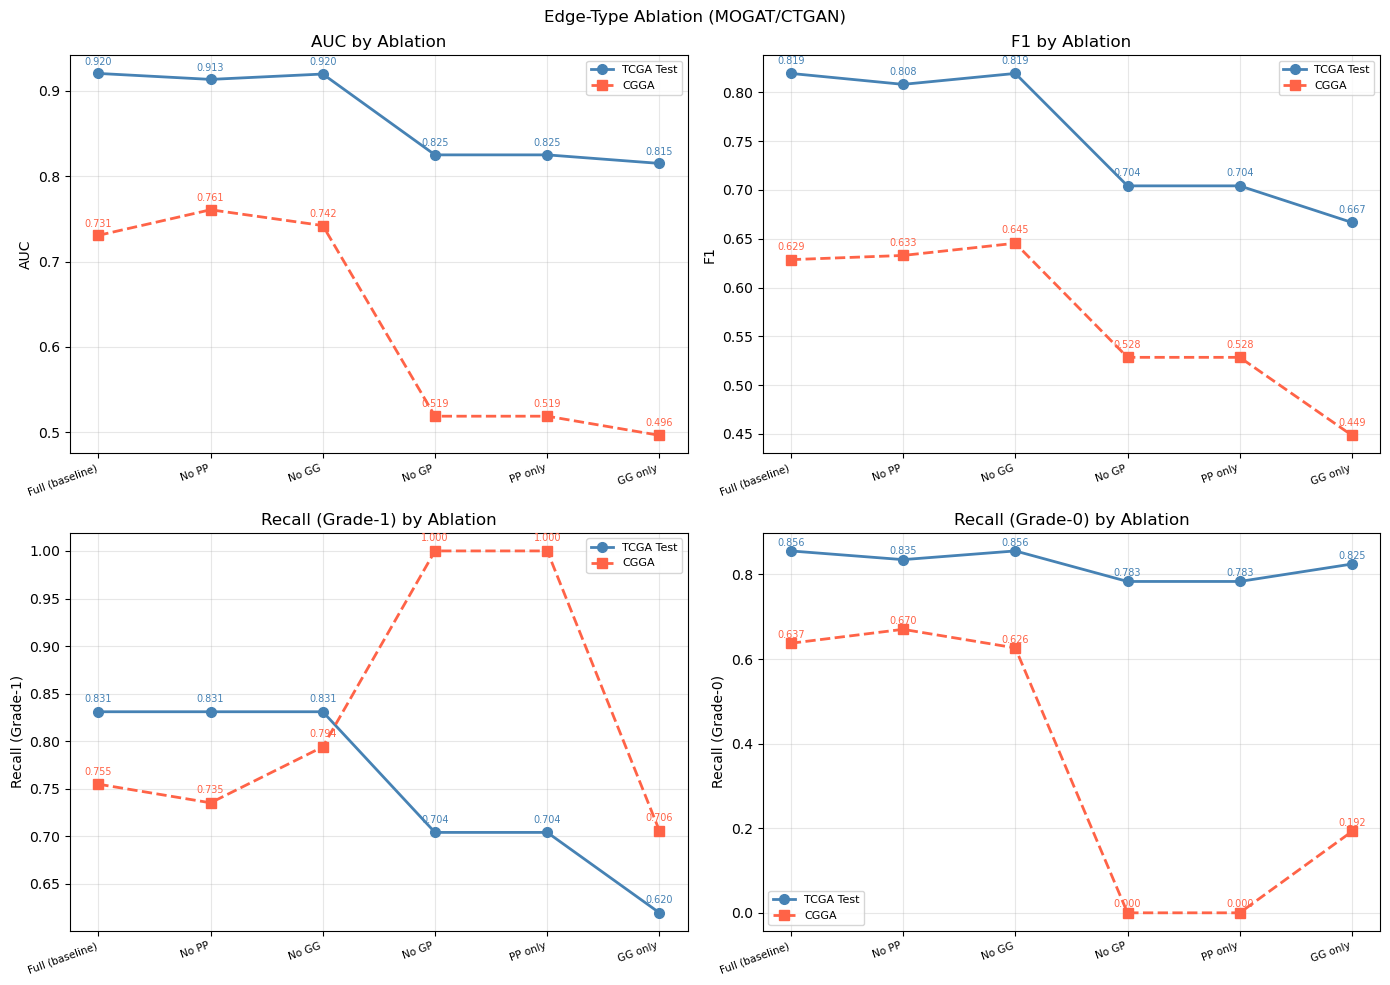

In [34]:
# Section E — Edge-Type Ablation Study
# ============================================================================
print("\n" + "="*65 + "\nSection E — Edge-Type Ablation\n" + "="*65)


def ablate_graph(df, remove_pp=False, remove_gg=False, remove_gp=False, scaler=None):
    g = construct_scalefree_bipartite_heterograph(df, scaler=scaler)
    if remove_pp:
        g[('Patient','cooccurs','Patient')].edge_index = torch.zeros(2, 0, dtype=torch.long)
    if remove_gg:
        g[('Gene','coexists','Gene')].edge_index = torch.zeros(2, 0, dtype=torch.long)
    if remove_gp:
        g[('Gene','mutates','Patient')].edge_index    = torch.zeros(2, 0, dtype=torch.long)
        g[('Patient','mutated_by','Gene')].edge_index = torch.zeros(2, 0, dtype=torch.long)
    return g


ABLATIONS = {
    'Full (baseline)':    dict(remove_pp=False, remove_gg=False, remove_gp=False),
    'No PP':              dict(remove_pp=True,  remove_gg=False, remove_gp=False),
    'No GG':              dict(remove_pp=False, remove_gg=True,  remove_gp=False),
    'No GP':              dict(remove_pp=False, remove_gg=False, remove_gp=True),
    'PP only':            dict(remove_pp=False, remove_gg=True,  remove_gp=True),
    'GG only':            dict(remove_pp=True,  remove_gg=False, remove_gp=True),
}

aug_df_ablation = apply_ctgan(train_val_df.copy())
ablation_results = []

for abl_name, abl_cfg in ABLATIONS.items():
    print(f"\n  Ablation: {abl_name}")
    set_seed(42)
    try:
        tr_abl = to_dev(ablate_graph(aug_df_ablation, **abl_cfg, scaler=GLOBAL_SCALER))
        vl_abl = to_dev(ablate_graph(val_df,          **abl_cfg, scaler=GLOBAL_SCALER))
        te_abl = to_dev(ablate_graph(test_df,          **abl_cfg, scaler=GLOBAL_SCALER))
        cg_abl = to_dev(ablate_graph(cgga_df,          **abl_cfg, scaler=GLOBAL_SCALER))
    except Exception as e:
        print(f"    Graph build error: {e}"); continue

    _, state_abl, _ = train_and_evaluate(
        tr_abl, vl_abl, BEST_BP_TCGA, BEST_MODEL_CLS_TCGA, BEST_FKW_TCGA,
        seed=42, loss_fn=make_criterion(tr_abl))
    kw_abl = {'hidden_dim': BEST_BP_TCGA['hidden_dim'], 'out_dim': 2,
               'num_heads': BEST_BP_TCGA['num_heads'], 'dropout': BEST_BP_TCGA['dropout']}
    kw_abl.update(BEST_FKW_TCGA)
    m_abl = BEST_MODEL_CLS_TCGA(**kw_abl).to(device)
    try:
        with torch.no_grad(): _ = m_abl(tr_abl)
    except: pass
    m_abl.load_state_dict(state_abl)

    for ds_name, ds_g in [('TCGA Test', te_abl), ('CGGA', cg_abl)]:
        pd_, pb_, lb_ = evaluate_model(m_abl, ds_g, threshold=BEST_THRESHOLD_TCGA)
        try:    auc = roc_auc_score(lb_, pb_)
        except: auc = np.nan
        ablation_results.append({
            'Ablation': abl_name, 'Dataset': ds_name,
            'AUC': round(auc, 4),
            'F1': round(f1_score(lb_, pd_, zero_division=0), 4),
            'Recall_1': round(recall_score(lb_, pd_, pos_label=1, zero_division=0), 4),
            'Recall_0': round(recall_score(lb_, pd_, pos_label=0, zero_division=0), 4),
        })
        print(f"    {ds_name}: AUC={auc:.4f}")

ablation_df = pd.DataFrame(ablation_results)
print("\nAblation Results:")
print(ablation_df.to_string(index=False))
ablation_df.to_csv('ablation_study.csv', index=False)

# Delta from baseline
full_auc = {ds: ablation_df[(ablation_df.Ablation=='Full (baseline)') &
                             (ablation_df.Dataset==ds)]['AUC'].values[0]
            for ds in ['TCGA Test','CGGA']}
print("\nAUC delta from Full baseline:")
for _, row in ablation_df.iterrows():
    if row['Ablation'] == 'Full (baseline)': continue
    delta = row['AUC'] - full_auc.get(row['Dataset'], 0)
    print(f"  {row['Ablation']:20s} {row['Dataset']:10s}: Δ={delta:+.4f}")

# Ablation figure
abl_order = list(ABLATIONS.keys())
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics_abl = ['AUC', 'F1', 'Recall_1', 'Recall_0']
metric_labels = ['AUC', 'F1', 'Recall (Grade-1)', 'Recall (Grade-0)']
for ax, metric, mlbl in zip(axes.flatten(), metrics_abl, metric_labels):
    for ds, ls in [('TCGA Test', '-o'), ('CGGA', '--s')]:
        sub = ablation_df[ablation_df.Dataset == ds].set_index('Ablation').reindex(abl_order)
        ax.plot(range(len(abl_order)), sub[metric].fillna(0),
                ls, color='steelblue' if ds == 'TCGA Test' else 'tomato', lw=2, ms=7, label=ds)
        for xi, val in enumerate(sub[metric].fillna(0)):
            ax.text(xi, val + 0.008, f'{val:.3f}', ha='center', va='bottom', fontsize=7,
                    color='steelblue' if ds == 'TCGA Test' else 'tomato')
    ax.set_xticks(range(len(abl_order)))
    ax.set_xticklabels(abl_order, rotation=20, ha='right', fontsize=7.5)
    ax.set_ylabel(mlbl); ax.set_title(f'{mlbl} by Ablation'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle(f'Edge-Type Ablation ({BEST_MODEL_NAME_TCGA}/{BEST_PIPELINE_TCGA})')
plt.tight_layout(); plt.savefig('ablation_study.png', dpi=300, bbox_inches='tight'); plt.show()

In [35]:
# Section F — Reproducibility Manifest
# ============================================================================
import platform
import torch as _torch, numpy as _np, pandas as _pd
import sklearn as _sk, scipy as _sp, matplotlib as _mpl, seaborn as _sns
import xgboost as _xgb, umap as _umap, sdv as _sdv

packages = {
    'python':     platform.python_version(),
    'torch':      _torch.__version__,
    'numpy':      _np.__version__,
    'pandas':     _pd.__version__,
    'sklearn':    _sk.__version__,
    'scipy':      _sp.__version__,
    'matplotlib': _mpl.__version__,
    'seaborn':    _sns.__version__,
    'xgboost':    _xgb.__version__,
    'umap-learn': _umap.__version__,
    'sdv':        _sdv.__version__,
    'cuda':       _torch.version.cuda if _torch.cuda.is_available() else 'N/A',
    'device':     str(device),
    'gpu':        _torch.cuda.get_device_name(0) if _torch.cuda.is_available() else 'N/A',
}

experiment_config = {
    'RANDOM_SEED': 42, 'N_FOLDS': 5, 'N_TRIALS_OPTUNA': 30,
    'MAX_EPOCHS': 200, 'PATIENCE': 20,
    'TEST_SIZE': 0.2, 'VAL_SIZE': 0.2,
    'MIN_AGE': 18, 'N_GENES': 20, 'BA_M_PATIENT': 2, 'BA_M_GENE': 2,
    'CTGAN_EPOCHS': 150, 'CTGAN_BATCH_SIZE': 50, 'CTGAN_PAC': 10,
    'FOCAL_GAMMA': 2, 'CLASS_WEIGHT': 'inverse_frequency',
    'THRESHOLD': 'G-mean [0.20, 0.80] step 0.005',
    'SMOTE_K': 3, 'BOOTSTRAP_N': 10_000,
}

manifest = {
    'packages':          packages,
    'experiment_config': experiment_config,
    'best_model_tcga':   {'name': BEST_MODEL_NAME_TCGA, 'pipeline': BEST_PIPELINE_TCGA, 'params': BEST_BP_TCGA},
    'best_model_cgga':   {'name': BEST_MODEL_NAME_CGGA, 'pipeline': BEST_PIPELINE_CGGA, 'params': BEST_BP_CGGA},
    'data_splits':       {'train': len(train_df), 'val': len(val_df),
                          'test': len(test_df), 'cgga': len(cgga_df)},
}

with open('reproducibility_manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2, default=str)
print("✓ Saved: reproducibility_manifest.json")

print("\n=== PACKAGE VERSIONS ===")
for k, v in packages.items(): print(f"  {k:20s}: {v}")
print("\n=== EXPERIMENT CONFIG ===")
for k, v in experiment_config.items(): print(f"  {k:30s}: {v}")
print(f"\n=== BEST TCGA: {BEST_MODEL_NAME_TCGA}/{BEST_PIPELINE_TCGA} ===")
for k, v in BEST_BP_TCGA.items(): print(f"  {k:20s}: {v}")
print(f"\n=== BEST CGGA: {BEST_MODEL_NAME_CGGA}/{BEST_PIPELINE_CGGA} ===")
for k, v in BEST_BP_CGGA.items(): print(f"  {k:20s}: {v}")

✓ Saved: reproducibility_manifest.json

=== PACKAGE VERSIONS ===
  python              : 3.11.15
  torch               : 2.12.0+cu130
  numpy               : 2.4.6
  pandas              : 2.3.3
  sklearn             : 1.9.0
  scipy               : 1.17.1
  matplotlib          : 3.10.9
  seaborn             : 0.13.2
  xgboost             : 2.0.3
  umap-learn          : 0.5.12
  sdv                 : 1.9.0
  cuda                : 13.0
  device              : cuda
  gpu                 : NVIDIA GeForce RTX 3050

=== EXPERIMENT CONFIG ===
  RANDOM_SEED                   : 42
  N_FOLDS                       : 5
  N_TRIALS_OPTUNA               : 30
  MAX_EPOCHS                    : 200
  PATIENCE                      : 20
  TEST_SIZE                     : 0.2
  VAL_SIZE                      : 0.2
  MIN_AGE                       : 18
  N_GENES                       : 20
  BA_M_PATIENT                  : 2
  BA_M_GENE                     : 2
  CTGAN_EPOCHS                  : 150
  CTGAN_BATCH_

In [36]:
# Save all model weights and thresholds
# ============================================================================
pd.DataFrame([{'Model': mn, 'Pipeline': pp, 'Threshold': th}
               for (mn, pp), th in all_thresholds.items()]).to_csv('thresholds.csv', index=False)

print("\n=== ALL SECTIONS COMPLETE ===")
print("Output files:")
for f in ['results_final.csv', 'cv_folds.csv', 'bootstrap_ci.csv',
          'mcnemar.csv', 'ctgan_feat_dist.csv', 'ctgan_class_conditional.csv',
          'graph_strategy_comparison.csv', 'tabular_baselines.csv',
          'ablation_study.csv', 'thresholds.csv', 'reproducibility_manifest.json']:
    exists = '✓' if os.path.exists(f) else '○'
    print(f"  {exists} {f}")


=== ALL SECTIONS COMPLETE ===
Output files:
  ✓ results_final.csv
  ✓ cv_folds.csv
  ✓ bootstrap_ci.csv
  ✓ mcnemar.csv
  ✓ ctgan_feat_dist.csv
  ✓ ctgan_class_conditional.csv
  ✓ graph_strategy_comparison.csv
  ✓ tabular_baselines.csv
  ✓ ablation_study.csv
  ✓ thresholds.csv
  ✓ reproducibility_manifest.json
